# Pairs trading on minute bars — IV. The desk at intraday frequency

## `pairs_trading_21_intraday_desk_alphas.ipynb`

Notebook 17 combined eleven daily alphas into one neutralized book and found that a fitted blend did
not clear the equal-weight one. Notebooks 18 to 20 measured what an intraday round trip costs. This
notebook puts the two together: **up to 500 names a month (425 on average once the exclusions apply),
thirty-minute bars, horizons from one bar to a day, and eight pre-registered alphas**, six built from
intraday price and volume — the overnight gap, the opening
move, the last half hour, abnormal volume and range, and the time-of-day seasonality of Heston,
Korajczyk and Sadka — and notebook 17's two daily alphas as controls. The question is whether any
of it clears the measured half-spread, how much holding overnight and damping turnover buy, and whether
the intraday alphas add anything once both sets are judged on the same book.

Everything below was fixed before any cell in this notebook ran, in
`notebooks/build/nb21_intraday_desk_preregistration.md`, reproduced verbatim in §0.1, which ends with Amendment 1.
No alpha, sign, book, formation time, window, period, cost rule, blend or decision rule was changed after the first
development-period run. The universe rule was: a fifth exclusion, for corrupted day-lake series, was added after the
first full run (Deviation 2), and Amendment 1 (Deviation 1) added a sixth, by instrument type, after the results of the
run of commit `e012840` had been seen and before this run. Every place this build could not do something exactly as
written, and every implementation choice the pre-registration left open, is logged in §10, Deviations.

**What it found.** Both pre-registered rules were applied as written, in §9. The hold-out was **not** looked at once: it was
displayed in the two earlier runs (the first full run, and the rebuild after Deviation 14, which is the run of commit
`e012840`) and this is its third display. Amendment 1, the fifth exclusion and the data-sanity rules (the ±100% rule and
the dividend drop) were all written after a hold-out had been displayed, so §9 is a confirmatory read of an amended
universe, not an untouched one (Deviation 17). This is the run under Amendment 1. The figures of the run before it (commit `e012840`, called the pre-amendment run below)
appear in code spans, and no verdict changed direction.

* **Amendment 1 removed about 22 names a month that the behavioral rules had kept.** Rule (vi) keeps only common stock
  and ADR common stock, by the security master's type for each (ticker, id) pair. It flagged 71.65 names a month (201
  distinct tickers) and removed 21.89 a month that none of rules (i) to (v) had caught, where each of rules (ii) to (v)
  alone removed between 0.35 and 0.66. With it, any rule flags 73.99 names a month (235 distinct tickers, against
  `52.10` and `174` before), and the final monthly universe fell from a mean of `447` names (`424` to `473`) to 425
  (391 to 457). A mean of 21.8 kept names a month (at most 55) have no type in the master and rest on the behavioral
  rules alone.
* **Rule one: the intraday desk does not work.** Book B, equal-weight, phi = 0.25, net of the primary (Roll-spread)
  costs, had a test-period Sharpe of 0.176 (t = 0.35 on 1008 sessions, against the threshold of 2) and a hold-out
  Sharpe of 0.809 on 655 sessions, the same sign as the test period. It failed on the t-statistic. The sign condition
  was met, but the sign does not credit the intraday alphas: the eight-alpha blend's hold-out IC was 0.0033 (s.e.
  0.0088), while `mom12_1` alone had 0.0160 (t = 2.3273), and the book of the two daily controls alone earned a
  hold-out net Sharpe of 0.879 against the eight-alpha book's 0.809. "Failed on the t-statistic, not on the sign"
  would overstate what the sign shows.
* **Rule two: intraday alphas add to the daily ones, in the two periods the rule reads, and the addition did not
  persist.** The eight-alpha equal-weight blend's IC exceeded that of the two daily controls alone by +0.0167 in
  development (s.e. 0.0046; twice that is 0.0092) and by +0.0127 in the test period (s.e. 0.0072), the same sign but a
  ratio of only +1.77. In the hold-out the difference was −0.0151 (s.e. 0.0082, ratio −1.83): the intraday alphas
  subtracted from the daily controls there, by a little under two standard errors. A leave-one-out shows a different
  alpha carrying the addition each period: `irev30` in development (+0.0087, t = 3.5880, and +0.0001 in the test
  period), with `irange` behind it (+0.0032, t = 3.1765), and `iopen` in the test period (+0.0094, t = 2.1364, against
  +0.0035 in development); in the hold-out `irev30` was the only intraday alpha with a positive gain (+0.0027,
  t = 0.5689) and `perio` subtracted (−0.0063, t = −2.0379). Read by year, the development addition is a result of 2010 and 2011
  (ratios 2.73 and 2.77, where no later development year is above 1.55): without those two years the difference is
  +0.0110 at a ratio of 2.10, which just passes the rule, and without the first four it is +0.0104 at 1.71, which does
  not. The controls' own blend had an IC of 0.0015 in development and 0.0005 in the test period, so "adds to the daily
  ones" means "has an IC where the daily ones have none on this window" (§9.3).
* **Book B is above the cost cliff on the primary basis, by a margin that is not established.** Its gross Sharpe was
  1.162 over the full span (s.e. 0.253) with 0.263 of the gross traded each session, about a quarter of the book. Net of
  the primary costs (one basis point of commission plus half the Roll spread) it was 0.516; net of the secondary costs
  (notebook 14's day-lake measured costs) it was 0.586, and the two differ by less than a third of a standard error. The
  medians of the two bases are close as well (2.64 and 2.08 bps per name per side in 2018). The profit per bet was 5.74
  bps gross against 3.23 bps of cost on the primary basis (1.78x, hold-out included), and clause (a) of the scorecard
  came out at t = 1.87 on 786 non-overlapping blocks, positive and just short of two. **That margin exists only if the
  desk trades at the signal's own print.** Book B earns 0.685 of its gross overnight, 0.210 in the half hour after the
  signal and 0.122 from the next open to 15:30; entered half an hour later, at the 16:00 close, the same weights earn a
  full-span net Sharpe of 0.276 instead of 0.516 (about one standard error) and a test-period net Sharpe of −0.020
  instead of 0.176 (§9.4).
* **Indistinguishable from notebooks 17 and 11.** On the secondary basis Book B's 0.586 compares with 0.596 for notebook
  17's equal-weight book (difference −0.010, 0.03 combined standard errors) and with 0.490 for notebook 11 (+0.096, 0.26
  combined standard errors).
* **Books A and C show the cliff at the desk's own frequency.** Their gross Sharpe ratios over the full span were 3.376
  and 8.594, their net Sharpe ratios on the primary basis −4.775 and −24.952, and their break-even costs 1.186 and 0.749
  bps per side, the second below the one basis point of commission alone.
* **Turnover control was the lever that moved the net Sharpe.** Through the test period Book B's net Sharpe rose from
  −0.276 at phi = 1.00 to 0.453 at 0.25 and 0.508 at 0.10 while its gross Sharpe fell from 2.498 to 1.105 and 0.797.
* **What the amendment moved, and what it did not.** Both verdicts, the two Benjamini–Hochberg survivors (`irev30` and
  `irange`), their fade in the test period, the reversal of rule two in the hold-out, the placebo and the cost cliff all
  kept their direction. The headline figures moved a little the same way: Book B's full-span net Sharpe on the primary
  basis went from `0.476` to 0.516, its test-period Sharpe from `0.144` to 0.176 (t from `0.29` to 0.35), and the
  hold-out paired IC difference from `−0.0124` (ratio `−1.42`) to −0.0151 (ratio −1.83), nearer to two standard errors
  and still short of them. Quantities that were close to zero changed sign: the test-period IC of `ovn` (now +0.0002, so
  six of the eight test ICs were positive, not `five`), the net Sharpe of the two daily controls' book through the test
  period (now −0.009, from `0.018`) and the equal-weight book's 2018 net Sharpe (now 0.157, from `−0.193`), none of them
  distinguishable from zero. One sentence of the pre-amendment prose did lose its footing: the net Sharpe through the
  test period no longer rose at every step as phi fell (0.455 at 0.50, 0.453 at 0.25).
* **Unadjusted splits and one corrupt price level reach Book B's target, and bias the result against the book.** Splits
  and class-share distributions enter a 24-hour window return as −50% or −67%, and PARA's price level (near 5,295 dollars
  one session, 105 the next) is corrupt inside the ±100% rule. Removing the 18 cells the flags in §9.5 find raises the
  full-span net Sharpe from 0.516 to 0.569 and the test-period t from 0.352 to 0.371, and removing every cell below −40%
  (69 cells, genuine collapses included) to 0.595 and 0.407. Neither verdict moves. The check is a sensitivity on the P&L
  side, not a change to the pipeline (Deviation 18).
* **A grouping defect changed the primary-basis numbers.** The first full run grouped the minute rows by `id` after
  filtering them by ticker-and-id pair, which interleaved the minutes of two names that share an id (JCI and TYC, ACE
  and CB, LBTYA and LBTYK) and put thousands of basis points of Roll spread on those six names, where the largest
  correct cell is 30.2 bps. Every primary-basis figure above and below is from the rebuilt caches (§1.3, Deviation 14).
  The test-period and hold-out verdicts were unchanged by the rebuild, but the development, full-span, scorecard and
  cost-basis conclusions of the first full run were not, and the conclusions above replace them.

**Data findings that changed the run.** The minute lake's `id` is not unique to a ticker inside a session file (191 of
6,988 ids in the first file read labeled more than one ticker), and an id filter spliced two price series into one and
manufactured a spurious next-day reversal; rows are kept by the ticker-and-id pair instead (§1.3). The first full run
also had BGZ, a triple-inverse fund whose day-lake closes sit near `1e13`, in the universe, where its junk dividend
applied to a real minute-lake price produced window returns of the order of `1e9` and a fictitious equal-weight P&L.
That added a fifth universe exclusion for corrupted day-lake series (1.73 names flagged per month, 16 distinct
tickers, 0.66 per month removed by that rule alone now that rule (vi) also applies, `0.81` before it), a rule that
treats window returns beyond ±100% as missing, and a rule that drops day-lake dividends above half the prior close (340
cells). None of them changed an alpha, a sign, a book or a decision rule; all are logged in §10, Deviations 2, 5 and 14.

**How the periods are used.** Every fit, selection and look happens in the development period. The test
period is shown alongside it from §4 on, because it is walk-forward output that no choice depends on.
The hold-out is computed with everything else but is **displayed only in §9**, at the end of this run: the
tables in §4 to §8 stop at the end of the test period. It is not a first look; the count of its earlier displays is in
§0 above and in Deviation 17.

**Caching.** Everything this notebook writes goes under `notebooks/cache/` (gitignored) with the prefix
`intra_` (`intra_smoke_` in the reduced smoke mode the build uses to debug): the 30-minute panel of the
market layout (`intra_bars30_<year>.parquet` chunks, resumable, and the per-name Roll statistics
`intra_rollstats_<year>.parquet`), the assembled Roll table (`intra_roll.parquet`), the point-in-time
universe (`intra_universe.pkl`), the daily risk-model loop (`intra_loadings.pkl`) and the alpha and
target panels of the three books (`intra_panels.pkl`). Every other cache in this repository, and both
parquet lakes, are read-only from here.

### 0.1 The pre-registration, verbatim

# Pre-registration: notebook 21, the desk at intraday frequency

Written 2026-09-29, before any of the code exists or any number has been seen. Everything here is
fixed. Anything the notebook does differently must be listed in a "Deviations" section at its end,
with the reason. It follows notebook 17's pre-registration and carries every lesson from its review.

## Question

At a breadth of 500 names and horizons from thirty minutes to a day, does any cross-sectional signal
formed from intraday price and volume data clear the measured half-spread, and how much do holding
overnight and turnover control buy? Secondary: do intraday-formed alphas add anything to the two
daily alphas that carried notebook 17, once both are judged on the same book?

## Data and universe

- Minute lake, **market layout** (`all_adjusted`, every ticker), aggregated to **30-minute bars** on
  the regular-session grid with `pairs.load_minute_bars` rules: 09:30–16:00 Eastern, 13:00 on NYSE
  early-close days, bars labeled by their start minute, forward-fill within a session only. Prices
  are split-adjusted; dividends are accrued from the day lake's factor steps for the overnight leg.
- Point-in-time universe: notebook 09's liquidity rules on the day lake, capped at the 500 most
  traded eligible names, rebuilt monthly, exactly notebook 12's `universe_at`, **minus** four
  exclusions, all operational: (i) SPY and the nine sector SPDRs used as factors; (ii) names flagged
  by `pairs.market_data.instruments.detect_scaled_instruments` in the formation window (leveraged
  and inverse funds); (iii) names whose formation-window daily-return R² against SPY or any sector
  SPDR is at least 0.90 (index trackers); (iv) the 79 tickers in `nb21_etf_exclusions.txt`, frozen
  today from notebook 17 §7.4. The count excluded under each rule is printed.
- Sessions 2010-01-04 to 2025-08-13. The lakes are read-only; the notebook writes only caches
  prefixed `intra_` under `notebooks/cache/`.

## Periods

| Period | Span | Use |
|---|---|---|
| Development | 2010-01-04 to 2018-12-31 | every fit, every selection, every look |
| Test | 2019-01-02 to 2022-12-30 | reported after development is frozen |
| Hold-out | 2023-01-03 to 2025-08-13 | notebooks 11 and 17's window; computed once, at the end |

## Books and horizons (fixed)

| Book | Formation | Target window | Position rule |
|---|---|---|---|
| **B, primary** | 15:30 close of the bar | 15:30 to the next session's 15:30 | partial adjustment toward the target once per session, φ = 0.25 primary, {1, 0.5, 0.1} reported; held overnight; 50 bp/yr borrow on shorts |
| A, intraday | 10:30 | 10:30 to the 16:00 close | full trade to target at 10:30, flat at the close, every session |
| C, thirty-minute | every bar close | the next 30-minute bar | full trade to target every bar, flat at the close |

Book B is the decision instrument. Books A and C are reported in full and never selected on; C
exists to put the fundamental-law arithmetic and the cost cliff on the page at the desk's own
frequency. Timing is strict: a signal at bar close t uses data through t; the target starts at t.

## Target

The hedged return over the book's window, with **no in-sample intercept**: the name's return minus
its factor betas times the factor returns over the same window, where the factor returns are the
ETFs' own bar returns and the PCA factors' portfolio returns over that window. Betas come from the
risk model below.

## The alpha list (fixed)

Standardized cross-sectionally at every formation (median and MAD, winsorized at ±3), then
multiplied by the pre-registered sign. The univariate IC test uses that sign; the blend is free to
disagree, and where the median ridge coefficient does, the notebook says so.

| # | Name | Definition, data through the formation bar | Sign | Source |
|---|---|---|---|---|
| 1 | `perio` | mean return over the same clock window as the target on the prior 20 sessions | + | Heston, Korajczyk & Sadka 2010 |
| 2 | `irev30` | residual return over the formation bar (the last 30 minutes) | − | Heston, Korajczyk & Sadka 2010; Lehmann 1990 |
| 3 | `ovn` | overnight return, prior close to today's 09:30 open | − | Lou, Polk & Skouras 2019 |
| 4 | `iopen` | intraday return from the 09:30 open to the formation bar, residual | − | Lou, Polk & Skouras 2019; Bogousslavsky 2021 |
| 5 | `ivol_abn` | log of the formation bar's volume over the mean volume of the same clock bar on the prior 20 sessions | + | Gervais, Kaniel & Mingelgrin 2001 |
| 6 | `irange` | log of today's high-low range so far over its mean at the same clock time on the prior 20 sessions | − | Ang, Hodrick, Xing & Zhang 2006 |
| 7 | `rev5` | residual return over the five sessions ending at the prior close (notebook 17's) | − | notebook 17 |
| 8 | `mom12_1` | return over sessions t−251..t−21 at the prior close (notebook 17's) | + | notebook 17 |

Alphas 7 and 8 are the daily controls: they carried notebook 17's equal-weight book, and the
secondary question is whether 1–6 add to them. Nothing is added after the first run; an alpha that
cannot be computed as written is dropped and the drop is logged.

## Risk model and neutralization

Notebook 12's monthly PCA loadings from daily returns (k = 15), plus the nine sector SPDRs, plus
size (log dollar volume). Target weights are projected orthogonal to the loadings **and a constant
column jointly** (notebook 17's corrected `neutralize`), then scaled to notebook 12's gross. The
book's realized exposures to SPY, the SPDRs, size and momentum are reported from returns aligned to
the realization window. Momentum is not neutralized; it is an alpha under test.

## Blends (both fixed)

1. **Equal-weight**: the mean of the eight signed z-scores. **The decision blend.**
2. **Ridge**: walk-forward, trailing 36 months, refit monthly, penalty from {0.1, 1, 10, 100} times
   the mean diagonal by leave-one-year-out cross-validation inside the training window, history
   admitted only once its target has realized. Reported with the share of refits per alpha whose
   coefficient is negative and the sign of the median coefficient.

## Costs and metrics

- **Primary cost basis** (notebook 18's): one basis point commission plus half the Roll spread per
  name per side, the Roll spread estimated per name and calendar year from that year's one-minute
  closes with `pairs.stats.microstructure.roll_spread`; borrow 50 bp/yr on overnight shorts.
  Unmeasured (name, year) cells take that year's median.
- **Secondary cost basis**: notebook 14's day-lake measured costs, so Book B can be set beside
  notebook 17's equal-weight book on the same footing.
- Per alpha, per horizon, per period: Pearson IC on the hedged target with the standard error from
  non-overlapping probe sessions (every fifth session; for Book C, every bar of every fifth
  session), the pairwise-complete count, and Benjamini–Hochberg at q = 0.10 across the eight alphas
  in development on Book B's window.
- Per book: gross and net Sharpe with s.e. √(252 / sessions) on all sessions and on sessions with
  a position, turnover per session, break-even cost in bps, P&L by year and by period, five-year
  blocks, exposures, and the five tradeable-edge clauses of notebook 14 §9 for Book B.
- Fundamental law for every book: realized blend IC, bets per year from breadth and turnover, IC ×
  √bets against the realized gross Sharpe, with the IC's standard error.
- Placebo, turnover-matched: each alpha's name-to-signal map is permuted **once per calendar
  month** and held fixed within it, so a placebo book turns over like the real one; 40 draws for the
  equal-weight Book B; the ridge placebo runs under a 30-minute budget and logs its draw count.
  Gross and net percentiles are both reported; the gross one is the comparison the null supports.

## Decision rules, fixed now

- The intraday desk **works** if Book B's equal-weight, φ = 0.25, net-of-primary-cost Sharpe on the
  test period is positive with t > 2 and the hold-out has the same sign. Otherwise it **does not**.
- Intraday alphas **add to the daily ones** if the Book B equal-weight blend of all eight has a
  higher development-period IC than the blend of alphas 7 and 8 alone by more than twice the
  difference's standard error, and the same sign of difference in the test period. Reported, not
  decided, if only one holds.
- Like-for-like against notebook 17's equal-weight book (0.596 net of day-lake measured costs, s.e.
  0.23) is reported on the secondary cost basis only, with the difference in combined standard
  errors; against notebook 11's 0.49 likewise.
- No formation time, window, threshold, universe rule, cost rule or alpha definition changes after
  the first development-period run. Sensitivities listed above are reported in full, never chosen
  from.

## Compute plan (informational, not a rule)

The 30-minute panel for the union of universe names is built once from the market layout by reading
each day file whole and filtering, and cached as `intra_bars30.parquet`; the per-name-year Roll
spreads are computed in the same pass and cached as `intra_roll.parquet`. The cold run may take up
to two hours; a warm run should be under ten minutes. If the ridge placebo does not finish 40 draws
in its budget, the shortfall is a logged deviation, never a change to anything else.

## Numbering

The notebook is a minute-lake study and follows 18–20, so it is notebook 21:
`pairs_trading_21_intraday_desk_alphas.ipynb`, built by `build_intraday_desk_notebook.py`.

## Amendment 1 (2026-09-29, written before the amended run)

The first full run (commit `e012840`) left about seventeen ETF-like names a month in the universe
because rules (ii)–(v) judge instruments by behavior. This amendment adds a sixth exclusion, by
**instrument type**, and changes nothing else:

- (vi) The Polygon security master (`~/local/parquet_lake/refdata/all/security_master.parquet`,
  read-only) gives each (ticker, holder id) a `type`. A name is kept only if its type is `CS`
  (common stock) or `ADRC` (ADR common); every other known type (`ETF`, `ETN`, `ETV`, `ETS`,
  `FUND`, `INDEX`, `PFD`, `WARRANT`, `UNIT`, `SP`, `RIGHT`, `ADRP`) is excluded. The lookup is by
  the (ticker, id) pair the day lake resolved, never by ticker alone, because reused tickers carry a
  different type in a different era (`FB`, `CA`, `EMC`, `GENZ`). A name whose pair has no type in
  the master keeps only the behavioral rules (ii)–(v); the count of such names is printed.
- Rules (i)–(v) remain in force. The exclusion table prints rule (vi) beside them.
- The alphas, books, periods, target, risk model, blends, costs, placebo and both decision rules are
  unchanged. Both rules are re-evaluated on the amended universe and printed; the first run's
  headline figures are quoted in code spans for comparison and remain in the repository's history.

## 1. Setup, data and universe

The day-lake constants are notebook 12's and 17's (`ANN`, `BORROW_BPS`, the liquidity rules, the 252-session
formation window, the 60-session regression window, k = 15 PCA factors), plus this notebook's own
period boundaries and its intraday constants: a 30-minute bar grid anchored at 09:30 Eastern (thirteen
bars on a regular session, seven on a 13:00 early-close session), and a one-basis-point commission.

In [1]:
from pathlib import Path
import os, re, sys, time, pickle, warnings

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.parquet as pq
from joblib import Parallel, delayed

import pairs
from pairs import load_daily_bars, liquidity_screen, benjamini_hochberg_fdr
from pairs.market_data.minute_bars import nyse_early_closes
from pairs.market_data.instruments import detect_scaled_instruments
from pairs.stats.microstructure import roll_spread

SMOKE = os.environ.get("INTRA_SMOKE", "") == "1"
PFX = "intra_smoke_" if SMOKE else "intra_"
DAY_LAKE    = Path(os.environ.get("DAY_LAKE", Path.home() / "local/parquet_lake/day_adj"))
MINUTE_LAKE = Path(os.environ.get("MINUTE_LAKE", Path.home() / "local/parquet_lake/minute_adj"))
DAY_MARKET, MIN_MARKET = DAY_LAKE / "all_adjusted", MINUTE_LAKE / "all_adjusted"
CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)
BUILD_DIR = repo_root / "notebooks" / "build"

START, END = "2004-01-01", "2025-08-13"
if SMOKE:
    FIRST_SESSION, LAST_SESSION = pd.Timestamp("2015-01-02"), pd.Timestamp("2016-12-30")
    DEV_END, TEST_START, TEST_END, HOLD_START = (pd.Timestamp(x) for x in
        ("2015-12-31", "2016-01-04", "2016-06-30", "2016-07-01"))
else:
    FIRST_SESSION, LAST_SESSION = pd.Timestamp("2010-01-04"), pd.Timestamp(END)
    DEV_END, TEST_START, TEST_END, HOLD_START = (pd.Timestamp(x) for x in
        ("2018-12-31", "2019-01-02", "2022-12-30", "2023-01-03"))

MIN_PRICE, MIN_DV, MIN_VOL, MAX_ABS_RET = 5.0, 20e6, 0.15, 1.0
UNIV_N, FORM_DAYS, N_FACTORS, REG_DAYS = 500, 252, 15, 60
CAP, ANN, BORROW_BPS, COMMISSION_BPS = 1_000_000.0, 252, 50.0, 1.0
R2_TRACKER = 0.90
PHI_PRIMARY = 0.25
PHIS = [0.25, 1.0, 0.5, 0.1]                # primary first, then the sensitivity grid
RIDGE_TRAIL_MONTHS = 36
RIDGE_GRID = [0.1, 1.0, 10.0, 100.0]
BAR_MIN, N_SLOT, OPEN_MIN, EARLY_SLOTS = 30, 13, 570, 7
LOOKBACK, MIN_PRIOR = 20, 10                # prior sessions for the same-clock alphas; fewest valid ones accepted
WARM = 25                                   # warm-up sessions before the first formation, history only
N_JOBS = min(16, os.cpu_count() or 4)
N_EW_DRAWS = 5 if SMOKE else 40
N_RIDGE_DRAWS = 3 if SMOKE else 40
RIDGE_PLACEBO_BUDGET_S = 300 if SMOKE else 1800

ALPHAS = ["perio", "irev30", "ovn", "iopen", "ivol_abn", "irange", "rev5", "mom12_1"]
SIGN = {"perio": 1, "irev30": -1, "ovn": -1, "iopen": -1, "ivol_abn": 1, "irange": -1,
        "rev5": -1, "mom12_1": 1}
NA = len(ALPHAS)
DAILY_CONTROLS = ["rev5", "mom12_1"]
NB17_SHARPE, NB17_SE = 0.596, 0.23         # notebook 17's equal-weight book, day-lake measured costs
NB11_SHARPE, NB11_SE = 0.49, 0.26          # notebook 11, as re-evaluated in notebook 14

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})
rng = np.random.default_rng(0)
sharpe = lambda x: x.mean() / x.std(ddof=0) * np.sqrt(ANN) if len(x) > 1 and x.std(ddof=0) > 0 else np.nan
DEVIATIONS = []
print("pairs", pairs.__version__)
print(f"mode: {'SMOKE (reduced span, caches prefixed ' + PFX + ')' if SMOKE else 'FULL (caches prefixed ' + PFX + ')'}")
print(f"formation sessions {FIRST_SESSION.date()} -> {LAST_SESSION.date()}; development to {DEV_END.date()}, "
      f"test {TEST_START.date()} -> {TEST_END.date()}, hold-out from {HOLD_START.date()}")
print(f"{N_JOBS} worker processes; placebo draws: {N_EW_DRAWS} equal-weight, up to {N_RIDGE_DRAWS} ridge "
      f"within {RIDGE_PLACEBO_BUDGET_S} s")

pairs 0.1.0
mode: FULL (caches prefixed intra_)
formation sessions 2010-01-04 -> 2025-08-13; development to 2018-12-31, test 2019-01-02 -> 2022-12-30, hold-out from 2023-01-03
16 worker processes; placebo draws: 40 equal-weight, up to 40 ridge within 1800 s


### 1.1 Daily bars, dividends, sessions

Notebook 12's cached total-return day-lake frame (read-only from here): split-adjusted closes, the dividend
recovered from the adjustment factors and credited on the ex-date, winsorized at ±100% a day, exchange test
symbols dropped. The frame is re-sorted date-major once so that every point-in-time window below is a
contiguous slice. The day lake's ticker-to-instrument map is single-valued over the whole span (printed: no
ticker carries more than one `id`), but it is not one-to-one: 14 ids carry two union tickers (printed in §1.3),
eleven of them renames that never trade in the same session and three of them (JCI and TYC, ACE and CB, LBTYA and
LBTYK) pairs of names that trade at the same time under one id. The minute lake is therefore read by the
ticker-and-id pair, not by `id`.

In [2]:
f_bars = CACHE / "day_market_bars.parquet"
if f_bars.exists():
    bars = pd.read_parquet(f_bars)
else:
    bars = load_daily_bars(None, START, END, DAY_MARKET, with_dividends=True)
    bars.to_parquet(CACHE / f"{PFX}day_bars.parquet")
bars_dt = bars.swaplevel("ticker", "datetime").sort_index()
del bars

px  = bars_dt["close"].unstack("ticker")
div = bars_dt["dividend"].unstack("ticker").reindex_like(px).fillna(0.0)
_big_div = div > 0.5 * px.shift(1)                 # a "dividend" above half the prior close is a factor glitch, not a payout
N_DIV_DROPPED = int(_big_div.to_numpy().sum())
div = div.mask(_big_div, 0.0)
dv  = bars_dt["dollar_volume"].unstack("ticker").reindex_like(px)
ret = ((px + div) / px.shift(1) - 1.0).clip(-1.0, 1.0)
TESTS = sorted(t for t in px.columns if re.fullmatch(r"Z[A-Z]ZZT", str(t)))
ret = ret.drop(columns=TESTS, errors="ignore")
sessions = ret.index
id_by_ticker = bars_dt.reset_index().groupby("ticker")["id"].agg(["last", "nunique"])
ID_OF = id_by_ticker["last"].to_dict()
print(f"{ret.shape[1]:,} tickers x {ret.shape[0]:,} sessions, {sessions[0].date()} -> {sessions[-1].date()}")
print(f"exchange test symbols dropped: {len(TESTS)}; tickers mapped to more than one id: "
      f"{int((id_by_ticker['nunique'] > 1).sum())}")

# the nine classic Select Sector SPDRs (notebook 17's reading of 'the nine sector ETFs'), plus SPY as the market
ETF9 = ["XLB", "XLE", "XLF", "XLI", "XLK", "XLP", "XLU", "XLV", "XLY"]
rows = []
for t in ETF9:
    s = ret[t].dropna()
    pos = sessions.get_indexer(s.index)
    gaps = np.diff(pos) if len(pos) > 1 else np.array([0])
    rows.append({"etf": t, "first": s.index.min().date(), "last": s.index.max().date(),
                 "max_gap_sessions": int(gaps.max()), "n_obs": len(s)})
etf_coverage = pd.DataFrame(rows).set_index("etf")
display(etf_coverage)
BAD9 = etf_coverage.index[(etf_coverage["max_gap_sessions"] > 5)
                          | (pd.to_datetime(etf_coverage["last"]) < pd.Timestamp("2025-01-01"))].tolist()
print(f"dropped from the nine for discontinuity: {BAD9}")
ETF9 = [t for t in ETF9 if t not in BAD9]
ETF10 = ["SPY"] + ETF9
assert "SPY" in ret.columns
etf_ret = ret[ETF9]
print(f"risk-model sector ETFs ({len(ETF9)}): {ETF9}; market factor for exposures and exclusions: SPY")

33,303 tickers x 5,438 sessions, 2004-01-02 -> 2025-08-13
exchange test symbols dropped: 13; tickers mapped to more than one id: 0


,first,last,max_gap_sessions,n_obs
etf,,,,
XLB,2004-01-05,2025-08-13,1,5437
XLE,2004-01-05,2025-08-13,1,5437
XLF,2004-01-05,2025-08-13,1,5437
XLI,2004-01-05,2025-08-13,1,5437
XLK,2004-01-05,2025-08-13,1,5437
XLP,2004-01-05,2025-08-13,1,5437
XLU,2004-01-05,2025-08-13,1,5437
XLV,2004-01-05,2025-08-13,1,5437
XLY,2004-01-05,2025-08-13,1,5437


dropped from the nine for discontinuity: []
risk-model sector ETFs (9): ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']; market factor for exposures and exclusions: SPY


### 1.2 Universe, exclusions and the monthly PCA loadings

Notebook 09's liquidity rules capped at the 500 most traded eligible names — exactly notebook 12's
`universe_at` — rebuilt **monthly**: the list for a calendar month is the screen on the 400 or so calendar
days ending at the last session of the month before, so nothing in it uses the month's own data. The four
pre-registered exclusions, a fifth for corrupted day-lake series (added after the first full run, Deviation 2) and the
sixth of Amendment 1, by instrument type (Deviation 1), are then applied to that list, in this order, each with its
count:

1. the ten factor ETFs (SPY and the nine SPDRs), which serve as factors and are never selected;
2. names `detect_scaled_instruments` flags in the 252-session formation window (leveraged and inverse funds),
   judged against every other candidate and the factor ETFs;
3. names whose formation-window daily-return R² against SPY or any one sector SPDR is at least 0.90 (index
   trackers);
4. the 79 tickers frozen in `nb21_etf_exclusions.txt`;
5. names whose day-lake series is corrupted in the formation window (a close above `1e5` or a recovered dividend above
   half the prior close);
6. names whose instrument type is not common stock or ADR common stock: the Polygon security master (read-only) types
   each (ticker, id) pair, a name is kept only as `CS` or `ADRC`, and a pair with no type in the master keeps only
   rules (ii) to (v). The lookup is by the pair the day lake resolved and never by ticker, because a reused ticker
   carries a different type in a different era.

The survivors with a complete formation-window return history feed notebook 12's `eigenportfolios` (15
factors). A name dropped only for lacking a complete window is counted separately. The cap is applied
first and the exclusions second, as pre-registered, so the survivors number fewer than 500. Each rule is judged on
the full capped list, so the flag counts overlap, and the table prints for each rule both the names it flags and the
names that only it removes. Rule (vi) is the large one: it flags 71.65 names a month and removes 21.89 that no other
rule catches, and the final monthly universe averages 425 names. The kept names that have no type in the master (21.8
a month on average, at most 55) are counted under the table.

In [3]:
def universe_raw_at(end, n=UNIV_N):
    # notebook 12's universe_at, verbatim rules; the factor ETFs are removed later, as counted exclusion 1
    start = end - pd.DateOffset(days=int(FORM_DAYS * 1.6))
    w = bars_dt.loc[start + pd.Timedelta(days=1):end]
    st = liquidity_screen(w, min_price=MIN_PRICE, min_dollar_volume=MIN_DV, min_ann_vol=MIN_VOL,
                          max_abs_return=MAX_ABS_RET, exclude=TESTS, top_n=n)
    return list(st[st["eligible"]].index)

def eigenportfolios(R, k=N_FACTORS):
    # verbatim from notebook 12
    sd = R.std(axis=0); ok = sd > 1e-12
    R, sd = R.loc[:, ok], sd[ok]
    C = np.nan_to_num(np.corrcoef(R.to_numpy(), rowvar=False), nan=0.0)
    vals, vecs = np.linalg.eigh(C)
    idx = np.argsort(vals)[::-1][:k]
    Q = vecs[:, idx] / sd.to_numpy()[:, None]
    Q = Q / np.abs(Q).sum(axis=0, keepdims=True)
    return pd.DataFrame(Q, index=R.columns, columns=[f"f{i}" for i in range(len(idx))]), vals[idx] / vals.sum()

def neutralize(w, B):
    # notebook 17's corrected form: project orthogonal to [loadings, 1] JOINTLY, then scale to unit gross
    B1 = np.column_stack([B, np.ones(B.shape[0])])
    BtB = B1.T @ B1 + 1e-8 * np.eye(B1.shape[1])
    w = w - B1 @ np.linalg.solve(BtB, B1.T @ w)
    g = np.abs(w).sum()
    return w / g if g > 1e-12 else w

def robust_z(x):
    # median/MAD z-score winsorized at +/-3; non-finite input stays NaN
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, np.nan)
    if np.isfinite(x).sum() < 3:
        return np.full_like(x, np.nan)
    med = np.nanmedian(x)
    scale = 1.4826 * np.nanmedian(np.abs(x - med))
    if not np.isfinite(scale) or scale < 1e-12:
        return np.full_like(x, np.nan)
    return np.clip((x - med) / scale, -3.0, 3.0)

FROZEN_ETFS = [ln.strip() for ln in (BUILD_DIR / "nb21_etf_exclusions.txt").read_text().splitlines()
               if ln.strip() and not ln.startswith("#")]
print(f"{len(FROZEN_ETFS)} frozen ETF-like tickers read from nb21_etf_exclusions.txt")
# Amendment 1 (2026-09-29): instrument type from the Polygon security master, keyed by the (ticker, id) pair
# the day lake resolved -- never by ticker alone, because a reused ticker carries another type in another era
SM_PATH = Path(os.environ.get("DAY_LAKE", Path.home() / "local/parquet_lake/day_adj")).parent / "refdata" / "all" / "security_master.parquet"
_sm = pd.read_parquet(SM_PATH, columns=["ticker", "holder_id", "type"]).dropna(subset=["type"])
TYPE_OF = {(str(t), str(h)): str(ty) for t, h, ty in zip(_sm["ticker"], _sm["holder_id"], _sm["type"])}
EQUITY_TYPES = {"CS", "ADRC"}
print(f"security master: {len(_sm):,} typed (ticker, id) rows; equity types kept: {sorted(EQUITY_TYPES)}")
del _sm

79 frozen ETF-like tickers read from nb21_etf_exclusions.txt
security master: 24,524 typed (ticker, id) rows; equity types kept: ['ADRC', 'CS']


In [4]:
# the monthly schedule: one rebuild per calendar month, on the last session before the month starts
all_days = sessions[(sessions >= sessions[sessions.get_loc(sessions[sessions >= FIRST_SESSION][0]) - WARM])
                    & (sessions <= LAST_SESSION)]
MONTHS = pd.period_range(all_days[0].to_period("M"), all_days[-1].to_period("M"), freq="M")
f_univ = CACHE / f"{PFX}universe.pkl"

def build_universe():
    flags, QM, RB = [], {}, {}
    t0 = time.time()
    for m in MONTHS:
        first = sessions[sessions >= m.to_timestamp()][0]
        i_first = sessions.get_loc(first)
        r = sessions[i_first - 1]                                   # last session before the month
        RB[m] = r
        raw = universe_raw_at(r)
        hist_all = ret.iloc[i_first - FORM_DAYS:i_first]            # the 252 sessions ending at r
        px_w = px.iloc[i_first - FORM_DAYS:i_first]
        cands = [t for t in raw if t not in ETF10]
        is_factor = pd.Series([t in ETF10 for t in raw], index=raw)
        is_frozen = pd.Series([t in set(FROZEN_ETFS) for t in raw], index=raw)
        judged = px_w[[t for t in raw if t in px_w.columns] + [t for t in ETF10 if t not in raw]]
        scaled = detect_scaled_instruments(judged)
        is_scaled = pd.Series([t in scaled for t in raw], index=raw)
        H = hist_all[[t for t in raw if t not in ETF10]]
        r2 = pd.DataFrame({e: H.corrwith(hist_all[e]) ** 2 for e in ETF10})
        cnt = pd.DataFrame({e: H.notna().mul(hist_all[e].notna(), axis=0).sum() for e in ETF10})
        r2max = r2.where(cnt >= 120).max(axis=1)                 # best single-ETF R-squared, 120 paired days at least
        is_tracker = (r2max >= R2_TRACKER).fillna(False)
        # (v) data quality, added after the first full run and logged as a deviation: a name whose day-lake
        # series is corrupted in the window (a close above $100,000, or a recovered "dividend" above half the
        # prior close) cannot be judged by rules (ii) and (iii) and its dividends cannot be trusted -- BGZ, a
        # triple-inverse fund with day-lake closes near 1e13, passed every other rule this way
        bd_w = _big_div.iloc[i_first - FORM_DAYS:i_first]
        is_corrupt = pd.Series([(t in px_w.columns) and (float(px_w[t].max()) > 1e5 or bool(bd_w[t].any()))
                                for t in raw], index=raw)
        # (vi) Amendment 1: instrument type by the (ticker, id) pair; a pair with no type keeps only rules (ii)-(v)
        _ty = [TYPE_OF.get((t, str(ID_OF.get(t)))) for t in raw]
        is_nonequity = pd.Series([ty is not None and ty not in EQUITY_TYPES for ty in _ty], index=raw)
        type_unknown = pd.Series([ty is None for ty in _ty], index=raw)
        f = pd.DataFrame({"month": str(m), "ticker": raw, "factor_etf": is_factor.to_numpy(),
                          "frozen_etf": is_frozen.to_numpy(), "scaled": is_scaled.to_numpy(),
                          "tracker": is_tracker.reindex(raw).fillna(False).astype(bool).to_numpy(), "r2_max": r2max.reindex(raw).to_numpy(),
                          "corrupt": is_corrupt.to_numpy(), "nonequity": is_nonequity.to_numpy(), "type_unknown": type_unknown.to_numpy()})
        f["excluded"] = f[["factor_etf", "frozen_etf", "scaled", "tracker", "corrupt", "nonequity"]].any(axis=1)
        keep = f.loc[~f["excluded"], "ticker"].tolist()
        hist = hist_all.reindex(columns=keep).dropna(axis=1)
        f["no_window"] = (~f["excluded"]) & (~f["ticker"].isin(hist.columns))
        Q, _ = eigenportfolios(hist)
        QM[m] = Q
        flags.append(f)
    flags = pd.concat(flags, ignore_index=True)
    print(f"universe schedule built for {len(MONTHS)} months in {time.time() - t0:.0f}s")
    return flags, QM, RB

if f_univ.exists():
    with open(f_univ, "rb") as fh:
        UNIV_FLAGS, QM, REBUILD = pickle.load(fh)
    print("loaded the cached universe schedule")
else:
    UNIV_FLAGS, QM, REBUILD = build_universe()
    with open(f_univ, "wb") as fh:
        pickle.dump((UNIV_FLAGS, QM, REBUILD), fh, protocol=5)
UNIV = {m: list(QM[m].index) for m in MONTHS}
UNION_TICKERS = sorted(set().union(*[set(v) for v in UNIV.values()]) | set(ETF10))
print(f"{len(MONTHS)} monthly universes {MONTHS[0]} -> {MONTHS[-1]}; {len(UNION_TICKERS):,} distinct tickers "
      f"including the ten factor ETFs")

loaded the cached universe schedule
190 monthly universes 2009-11 -> 2025-08; 1,117 distinct tickers including the ten factor ETFs


In [5]:
# the count excluded under each rule, printed
fl = UNIV_FLAGS
n_m = fl["month"].nunique()
rules = [("(i) factor ETFs (SPY and the nine SPDRs)", "factor_etf"),
         ("(ii) leveraged and inverse funds (detect_scaled_instruments)", "scaled"),
         ("(iii) index trackers (R-squared >= 0.90 against SPY or a SPDR)", "tracker"),
         ("(iv) frozen ETF list (79 tickers)", "frozen_etf"),
         ("(v) corrupted day-lake series (data quality; added after the first full run, logged)", "corrupt"),
         ("(vi) instrument type (Amendment 1: security master, keep CS and ADRC; unknown types fall back to ii-v)", "nonequity")]
rows = []
alone = fl[["factor_etf", "frozen_etf", "scaled", "tracker", "corrupt", "nonequity"]]
for label, c in rules:
    others = [o for _, o in rules if o != c]
    rows.append({"rule": label, "flagged, mean per month": fl.groupby("month")[c].sum().mean(),
                 "removed by this rule alone, mean per month": (alone[c] & ~alone[others].any(axis=1)).sum() / n_m,
                 "distinct tickers ever flagged": fl.loc[fl[c], "ticker"].nunique()})
rows.append({"rule": "any rule", "flagged, mean per month": fl.groupby("month")["excluded"].sum().mean(),
             "removed by this rule alone, mean per month": np.nan,
             "distinct tickers ever flagged": fl.loc[fl["excluded"], "ticker"].nunique()})
excl_table = pd.DataFrame(rows).set_index("rule")
display(excl_table.round(2))
_kept = fl[~fl["excluded"]]
print(f"kept names per month whose (ticker, id) pair has no type in the security master (behavioral rules only): "
      f"mean {_kept.groupby('month')['type_unknown'].sum().mean():.1f}, max {int(_kept.groupby('month')['type_unknown'].sum().max())}")
DEVIATIONS.append(f"Amendment 1 (2026-09-29, pre-registration file, written before this run): exclusion (vi) by instrument type "
                  f"from the Polygon security master, keyed by the (ticker, id) pair; it flags "
                  f"{fl.groupby('month')['nonequity'].sum().mean():.1f} names a month and removes "
                  f"{(alone['nonequity'] & ~alone[[c for c in alone.columns if c != 'nonequity']].any(axis=1)).sum() / n_m:.1f} that no other rule "
                  f"caught. The first run's figures (commit e012840) were: Book B equal-weight phi=0.25 net Sharpe 0.634 / 0.144 / 0.675 "
                  f"(development / test / hold-out, primary basis), full span gross 1.130 and net 0.476 (0.548 day-lake); rule two "
                  f"+0.0156 / +0.0113 / -0.0124.")
sizes = pd.Series({str(m): len(UNIV[m]) for m in MONTHS})
print(f"raw top-500 lists: {fl.groupby('month').size().mean():.0f} names per month before exclusions; "
      f"dropped only for lacking a complete formation window: {fl.groupby('month')['no_window'].sum().mean():.1f} per month")
print(f"final monthly universe: mean {sizes.mean():.0f} names, min {sizes.min()}, max {sizes.max()}")

,"flagged, mean per month","removed by this rule alone, mean per month",distinct tickers ever flagged
rule,,,
(i) factor ETFs (SPY and the nine SPDRs),6.35,0.00,10
(ii) leveraged and inverse funds (detect_scaled_instruments),11.83,0.35,87
(iii) index trackers (R-squared >= 0.90 against SPY or a SPDR),19.57,0.56,93
(iv) frozen ETF list (79 tickers),34.51,0.55,62
"(v) corrupted day-lake series (data quality; added after the first full run, logged)",1.73,0.66,16
"(vi) instrument type (Amendment 1: security master, keep CS and ADRC; unknown types fall back to ii-v)",71.65,21.89,201
any rule,73.99,NaN,235


kept names per month whose (ticker, id) pair has no type in the security master (behavioral rules only): mean 21.8, max 55
raw top-500 lists: 500 names per month before exclusions; dropped only for lacking a complete formation window: 0.9 per month
final monthly universe: mean 425 names, min 391, max 457


### 1.3 Reading the minute lake

The market layout holds one file per session with every ticker (about 1.5 million minute rows). Reading it
name by name through the sidecar index costs seconds per session for 500 names, so each session file is
instead read **whole** (eight columns), filtered with Arrow to the session's ticker-and-id pairs, moved from UTC
to Eastern, cut to the regular session (09:30 to 16:00, or to 13:00 on the NYSE early closes that
`nyse_early_closes` lists) and aggregated to 30-minute bars labeled by their start minute: open is the first
traded minute's open, high and low the extremes, close the last traded minute's close, volume the sum. A bar
with no trade repeats the previous close with zero volume, forward-filled **within the session only**;
minutes before a name's first trade of the session stay missing. Prices are the lake's split-adjusted
columns. **The lake's `id` cannot be trusted on its own:** inside a session file a few percent of ids label two tickers (the cell below counts them in the first session file read; in the 2015-01-02 file the id of `BBT` also labels `BHLB`, that of `BBBY` also labels `OSTK`), so an id filter silently splices two price series into one and manufactures a spurious next-day reversal (an information coefficient of the order of a fifth on a first trial, gone once fixed). Rows are therefore kept only where the ticker and the id are the pair the day lake resolved, **and every grouping of those rows (the 30-minute bars, the Roll statistics) is by the same pair**: the filter alone is not enough, because two kept tickers can share one id inside a session (JCI and TYC, ACE and CB, LBTYA and LBTYK), and grouping the filtered rows by `id` would interleave their minutes into one series. The first full run of this notebook did exactly that, and the six names' Roll spreads came out at thousands of basis points; the results below are from the rebuilt caches (Deviation 14). The pairs kept for a session are those of the point-in-time universes of its month and of the two
following months (so a name's history is on hand the month it enters) plus the ten factor ETFs. The same
pass records, per name and session, the sufficient statistics of the Roll estimator from the traded
one-minute closes (the sums of the lagged and lead price changes and of their product, within the session
only), so that the per-name, per-calendar-year Roll spread of the cost basis comes out of the same read.

**A note on clock times.** An instant is named by its clock time, and the price *at* an instant is the close of
the 30-minute bar that ends there, that is, the bar labeled thirty minutes earlier. Book B forms at 15:30, the
close of the bar labeled 15:00; Book A forms at 10:30, the close of the bar labeled 10:00; Book C forms at the
close of every bar from 10:00 to 15:30. On a 13:00 early-close session the same relative instant, thirty
minutes before the close (12:30), plays the role of 15:30.

In [6]:
early_days = nyse_early_closes(all_days[0], all_days[-1])
EARLY_SET = set(early_days)
def month_keys(m):
    # the minute lake's `id` is NOT unique to a ticker inside a session file (215 of 7,295 ids in one 2015 file
    # carry two tickers: BBT's id also labels BHLB, BBBY's labels OSTK), so rows are kept by the ticker|id pair
    # the day lake resolved, never by id alone
    tk = set(ETF10)
    for k in range(3):
        if m + k in UNIV:
            tk |= set(UNIV[m + k])
    return sorted(f"{t}|{ID_OF[t]}" for t in tk if t in ID_OF)
MKEYS = {m: month_keys(m) for m in MONTHS}
# the dense axis is the (ticker, id) PAIR, not the id: the first full run showed two names whose id is
# shared with junk-priced ETN rows in the day lake (window returns of 2e8 and 2e9 once their prices and
# dividends were merged onto one code); keying by the pair keeps every instrument's own series
ALL_IDS = sorted({k for v in MKEYS.values() for k in v})            # "ticker|id" keys
CODE = {i: j for j, i in enumerate(ALL_IDS)}
N_ID = len(ALL_IDS)
code_of_ticker = {t: CODE[f"{t}|{ID_OF[t]}"] for t in UNION_TICKERS if f"{t}|{ID_OF.get(t)}" in CODE}
print(f"{len(all_days):,} sessions read from the minute lake ({all_days[0].date()} -> {all_days[-1].date()}, the first "
      f"{WARM} are warm-up history), {N_ID:,} distinct (ticker, id) instruments, {len(early_days)} early-close sessions")

def session_bars(path, date, ids, early):
    # one session file -> (30-minute bars on the full session grid, Roll sufficient statistics)
    import numpy as np, pandas as pd, pyarrow as pa, pyarrow.compute as pc, pyarrow.parquet as pq
    cols = ["datetime", "id", "ticker", "open_split", "high_split", "low_split", "close_split", "volume_split"]
    tb = pq.read_table(path, columns=cols)
    key = pc.binary_join_element_wise(pc.cast(tb["ticker"], pa.string()), pc.cast(tb["id"], pa.string()), "|")
    tb = tb.filter(pc.is_in(key, value_set=pa.array(list(ids))))
    if tb.num_rows == 0:
        return None, None
    df = tb.to_pandas()
    ts = pd.Timestamp(date)
    off = int(-pd.Timestamp(ts.year, ts.month, ts.day, 12).tz_localize("US/Eastern").utcoffset().total_seconds() // 60)
    et = (df["datetime"].dt.hour * 60 + df["datetime"].dt.minute).to_numpy() - off
    close_min = 13 * 60 if early else 16 * 60
    keep = ((et >= 570) & (et < close_min) & np.isfinite(df["close_split"].to_numpy())
            & (df["datetime"].dt.normalize() == ts).to_numpy())
    df, et = df[keep], et[keep]
    if len(df) == 0:
        return None, None
    # the group is the ticker|id PAIR: two kept tickers can share one id inside a session (JCI and TYC, ACE and CB,
    # LBTYA and LBTYK), and grouping by id alone would interleave their minutes into one series
    pair = df["ticker"].astype(str).to_numpy() + "|" + df["id"].astype(str).to_numpy()
    g, uniq_pair = pd.factorize(pair, sort=False)
    uniq = np.array([p_.split("|")[-1] for p_ in uniq_pair], dtype=object)
    utick = np.array([p_.rsplit("|", 1)[0] for p_ in uniq_pair], dtype=object)
    order = np.lexsort((et, g))
    g, et = g[order], et[order]
    c = df["close_split"].to_numpy(float)[order]
    o = df["open_split"].to_numpy(float)[order]; h = df["high_split"].to_numpy(float)[order]
    l = df["low_split"].to_numpy(float)[order]; v = df["volume_split"].to_numpy(float)[order]
    o = np.where(np.isfinite(o), o, c); h = np.where(np.isfinite(h), h, c); l = np.where(np.isfinite(l), l, c)
    v = np.where(np.isfinite(v), v, 0.0)
    G, nb = len(uniq), (close_min - 570) // 30
    k = (et - 570) // 30
    key = g * 32 + k
    start = np.flatnonzero(np.r_[True, key[1:] != key[:-1]])
    end = np.r_[start[1:], len(key)] - 1
    gg, kk = key[start] // 32, key[start] % 32
    Om, Hm, Lm, Cm = (np.full((G, nb), np.nan) for _ in range(4))
    Vm = np.zeros((G, nb))
    Om[gg, kk], Cm[gg, kk] = o[start], c[end]
    Hm[gg, kk], Lm[gg, kk] = np.maximum.reduceat(h, start), np.minimum.reduceat(l, start)
    Vm[gg, kk] = np.add.reduceat(v, start)
    valid = np.isfinite(Cm)
    fill = np.maximum.accumulate(np.where(valid, np.arange(nb)[None, :], 0), axis=1)
    Cf = np.take_along_axis(Cm, fill, axis=1)                 # forward fill inside the session only
    empty = ~valid & np.isfinite(Cf)
    Om, Hm, Lm = np.where(empty, Cf, Om), np.where(empty, Cf, Hm), np.where(empty, Cf, Lm)
    bars = pd.DataFrame({
        "session": ts,
        "bar_start": ts + pd.to_timedelta(570 + 30 * np.tile(np.arange(nb), G), unit="m"),
        "id": np.repeat(uniq, nb), "ticker": np.repeat(utick, nb),
        "open": Om.ravel().astype(np.float32), "high": Hm.ravel().astype(np.float32),
        "low": Lm.ravel().astype(np.float32), "close": Cf.ravel().astype(np.float32),
        "volume": Vm.ravel().astype(np.float32)})
    # Roll sufficient statistics: consecutive traded-minute price changes, pairs kept inside the name-session
    d = np.r_[np.nan, np.diff(c)]
    first = np.r_[True, g[1:] != g[:-1]]
    d[first] = np.nan
    lag = np.r_[np.nan, d[:-1]]
    pm = np.isfinite(d) & np.isfinite(lag)
    gp = g[pm]
    roll = pd.DataFrame({
        "session": ts, "id": uniq, "ticker": utick,
        "n_pairs": np.bincount(gp, minlength=G).astype(np.int64),
        "s_ab": np.bincount(gp, weights=(d * lag)[pm], minlength=G),
        "s_a": np.bincount(gp, weights=d[pm], minlength=G),
        "s_b": np.bincount(gp, weights=lag[pm], minlength=G),
        "s_p": np.bincount(g, weights=c, minlength=G), "n_p": np.bincount(g, minlength=G).astype(np.int64)})
    return bars, roll

def session_task(d):
    m = d.to_period("M")
    return (MIN_MARKET / f"{d.year:04d}" / f"{d.month:02d}" / f"{d.day:02d}.parquet", d, MKEYS[m], d in EARLY_SET)

tasks = [session_task(d) for d in all_days]
n_full = int(((sessions >= sessions[sessions.get_loc(sessions[sessions >= pd.Timestamp("2010-01-04")][0]) - WARM])
              & (sessions <= pd.Timestamp(END))).sum())
_ids = pq.read_table(tasks[0][0], columns=["id", "ticker"]).to_pandas()
_multi = int((_ids.groupby("id")["ticker"].nunique() > 1).sum())
print(f"id uniqueness check on the {tasks[0][1].date()} file: {_multi:,} of {_ids['id'].nunique():,} ids label more than one ticker; "
      f"{int((_ids.groupby('ticker')['id'].nunique() > 1).sum())} tickers carry more than one id")
t0 = time.time()
for tk in tasks[:10]:
    b_, r_ = session_bars(*tk)
per_session = (time.time() - t0) / 10
print(f"timing: first ten sessions read one after another in {per_session * 10:.1f}s ({per_session:.2f}s per session)")
print(f"projected minute-lake build for the full span ({n_full:,} sessions) on {N_JOBS} workers: "
      f"{per_session * n_full / N_JOBS / 60:.1f} minutes; sequentially {per_session * n_full / 60:.0f} minutes")
_pair_tab = pd.Series({t: ID_OF[t] for t in UNION_TICKERS if t in ID_OF}).rename("id").reset_index().rename(columns={"index": "ticker"})
_shared = _pair_tab.groupby("id")["ticker"].agg(list)
_shared = _shared[_shared.map(len) > 1]
print(f"day-lake ids that carry more than one union ticker: {len(_shared)} ({'; '.join('/'.join(v) for v in _shared)})")
print(f"this run builds {len(tasks):,} sessions, projected {per_session * len(tasks) / N_JOBS / 60:.1f} minutes on {N_JOBS} workers")

3,952 sessions read from the minute lake (2009-11-25 -> 2025-08-13, the first 25 are warm-up history), 1,117 distinct (ticker, id) instruments, 34 early-close sessions


id uniqueness check on the 2009-11-25 file: 191 of 6,988 ids label more than one ticker; 0 tickers carry more than one id


timing: first ten sessions read one after another in 1.4s (0.14s per session)
projected minute-lake build for the full span (3,952 sessions) on 16 workers: 0.6 minutes; sequentially 9 minutes
day-lake ids that carry more than one union ticker: 14 (BBBY/OSTK; FI/FISV; ABC/COR; P/PSTG; VIA.B/VIAB; ANDV/TSO; MHFI/MHP; AOC/AON; DNDN/PCYC; JOY/JOYG; JCI/TYC; WFM/WFMI; ACE/CB; LBTYA/LBTYK)
this run builds 3,952 sessions, projected 0.6 minutes on 16 workers


In [7]:
def chunk_files(y):
    return CACHE / f"{PFX}bars30_{y}.parquet", CACHE / f"{PFX}rollstats_{y}.parquet"

years = sorted({d.year for d in all_days})
t_build = time.time()
built, reused = [], []
for y in years:
    fb, fr = chunk_files(y)
    if fb.exists() and fr.exists():
        reused.append(y); continue
    ty = time.time()
    todo = [tk for tk in tasks if tk[1].year == y]
    res = Parallel(n_jobs=N_JOBS, backend="loky")(delayed(session_bars)(*tk) for tk in todo)
    bars_y = pd.concat([r[0] for r in res if r[0] is not None], ignore_index=True)
    roll_y = pd.concat([r[1] for r in res if r[1] is not None], ignore_index=True)
    bars_y.to_parquet(fb); roll_y.to_parquet(fr)
    built.append(y)
    print(f"  {y}: {len(todo)} sessions, {len(bars_y):,} bar rows, {time.time() - ty:.0f}s")
print(f"minute-lake pass: built {built if built else 'nothing'}, reused cached chunks for {reused if reused else 'none'}; "
      f"{time.time() - t_build:.0f}s this run")

minute-lake pass: built nothing, reused cached chunks for [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]; 0s this run


#### The per-name, per-year Roll spread

`pairs.stats.microstructure.roll_spread` pools the within-session pairs of consecutive price changes over a
window into one covariance and reports twice the square root of its negative, in basis points of the mean
price; it is NaN when the pooled covariance is not negative or there are fewer than 30 pairs. Because the
estimator pools, its sufficient statistics add across sessions, so the calendar-year spread of a name can be
assembled from the per-session statistics recorded above without holding a year of minute closes for every
name at once. The cell below assembles the table and **checks it against `roll_spread` itself** on a handful
of names over a few weeks of raw minute closes read by an independent route.

In [8]:
f_roll = CACHE / f"{PFX}roll.parquet"
rs = pd.concat([pd.read_parquet(chunk_files(y)[1]) for y in years], ignore_index=True)
rs["year"] = rs["session"].dt.year

def roll_from_stats(g):
    n = g["n_pairs"].sum()
    with np.errstate(invalid="ignore", divide="ignore"):
        cov = g["s_ab"].sum() / n - (g["s_a"].sum() / n) * (g["s_b"].sum() / n)
        mean_p = g["s_p"].sum() / g["n_p"].sum()
        spread = 2.0 * np.sqrt(-cov)
    ok = (n >= 30) & (cov < 0)
    return pd.Series({"roll_bps": spread / mean_p * 1e4 if ok else np.nan, "n_obs": n})

# the unit of a Roll cell is the ticker|id pair; grouping by id alone would pool two names that share an id
assert not rs.duplicated(["session", "ticker", "id"]).any(), "a (session, ticker, id) row appears twice"
grp = rs.groupby(["ticker", "id", "year"])
roll_tab = grp[["n_pairs", "s_ab", "s_a", "s_b", "s_p", "n_p"]].sum()
with np.errstate(invalid="ignore", divide="ignore"):
    n_ = roll_tab["n_pairs"]
    cov_ = roll_tab["s_ab"] / n_ - (roll_tab["s_a"] / n_) * (roll_tab["s_b"] / n_)
    roll_tab["roll_bps"] = (2.0 * np.sqrt(-cov_) / (roll_tab["s_p"] / roll_tab["n_p"]) * 1e4).where((n_ >= 30) & (cov_ < 0))
roll_tab["n_obs"] = n_
roll_tab = roll_tab[["roll_bps", "n_obs"]].reset_index()
_sess_year = rs.groupby("year")["session"].nunique()
_cap = roll_tab["year"].map(_sess_year) * 391
assert (roll_tab["n_obs"] <= _cap).all(), "a (name, year) Roll cell has more pairs than sessions x 391"
print(f"Roll-cell check: largest n_obs / (sessions x 391) = {(roll_tab['n_obs'] / _cap).max():.3f}; "
      f"{int((rs.groupby(['session', 'id'])['ticker'].nunique() > 1).sum()):,} (session, id) cells carry two kept tickers, "
      f"each now its own Roll series; largest Roll cell {roll_tab['roll_bps'].max():.1f} bps")
roll_tab.to_parquet(f_roll)
ROLL_MED = roll_tab.groupby("year")["roll_bps"].median()
print(f"Roll table: {len(roll_tab):,} (ticker, id, year) cells, {roll_tab['roll_bps'].notna().mean():.1%} measured "
      f"(the rest take that year's median); median Roll spread {roll_tab['roll_bps'].median():.2f} bps")
display(ROLL_MED.to_frame("median Roll spread, bps").T.round(2))

# validation: the pooled statistics against roll_spread on raw minute closes, read by a different route
val_days = [d for d in all_days if d.year == all_days[WARM].year][:15]
val_names = list(dict.fromkeys(["SPY"] + [t for t in UNIV[val_days[0].to_period("M")] if t in ID_OF][:5]))
val_ids = {ID_OF[t]: t for t in val_names}
val_tickers = set(val_names)
frames = []
for d in val_days:
    tb = pq.read_table(MIN_MARKET / f"{d.year:04d}/{d.month:02d}/{d.day:02d}.parquet",
                       columns=["datetime", "id", "ticker", "close_split"])
    df = tb.to_pandas()
    df = df[df["id"].isin(list(val_ids)) & df["ticker"].isin(val_tickers)].copy()
    et = df["datetime"].dt.tz_localize("UTC").dt.tz_convert("US/Eastern").dt.tz_localize(None)
    mod = et.dt.hour * 60 + et.dt.minute
    cm = 13 * 60 if d in EARLY_SET else 16 * 60
    df = df[(mod >= 570) & (mod < cm) & (et.dt.normalize() == d) & df["close_split"].notna()].copy()
    df["et"], df["session"] = et[df.index], d
    frames.append(df)
raw_min = pd.concat(frames).sort_values(["id", "et"])
vt = rs[rs["session"].isin(val_days) & rs["id"].isin(list(val_ids)) & rs["ticker"].isin(val_tickers)]
rows = []
for i_, t in val_ids.items():
    s_ = raw_min[raw_min["id"] == i_]
    a = roll_spread(pd.Series(s_["close_split"].to_numpy(), index=pd.DatetimeIndex(s_["et"])),
                    as_bps=True, session=s_["session"].to_numpy(), every=1)
    b = roll_from_stats(vt[vt["id"] == i_])["roll_bps"]
    rows.append({"ticker": t, "roll_spread(minute closes), bps": a, "assembled from statistics, bps": b})
val = pd.DataFrame(rows).set_index("ticker")
display(val.round(4))
gap = (val.iloc[:, 0] - val.iloc[:, 1]).abs().max()
print(f"Roll validation over {len(val_days)} sessions and {len(val)} names: largest absolute difference {gap:.2e} bps "
      f"({'agree' if (gap < 1e-6 or np.isnan(gap)) else 'DISAGREE'}); NaN cells agree: "
      f"{bool((val.iloc[:, 0].isna() == val.iloc[:, 1].isna()).all())}")

Roll-cell check: largest n_obs / (sessions x 391) = 0.991; 3,083 (session, id) cells carry two kept tickers, each now its own Roll series; largest Roll cell 30.2 bps
Roll table: 9,318 (ticker, id, year) cells, 91.3% measured (the rest take that year's median); median Roll spread 3.00 bps


year,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
"median Roll spread, bps",3.19,2.97,2.82,2.82,2.41,2.93,2.83,2.64,3.37,3.27,2.65,3.87,3.13,3.36,2.58,3.18,3.65


,"roll_spread(minute closes), bps","assembled from statistics, bps"
ticker,,
SPY,1.2067,1.2067
BAC,5.7333,5.7333
AAPL,2.1919,2.1919
XOM,2.0633,2.0633
JPM,NaN,NaN
GS,NaN,NaN


Roll validation over 15 sessions and 6 names: largest absolute difference 1.33e-15 bps (agree); NaN cells agree: True


### 1.4 The dense 30-minute panel

The yearly chunks are scattered into dense arrays indexed by session, bar slot (0 is the bar labeled 09:30) and
instrument code, so that every same-clock window in the alphas below is a slice. The range-so-far array (the
running high minus the running low from the open) is built once. Dividends, needed for the overnight leg, come
from the day lake's `dividend` column by ticker and are placed on the same instrument codes.

In [9]:
S_W = all_days
S = len(S_W)
NSLOT = np.where(S_W.isin(early_days), EARLY_SLOTS, N_SLOT)
Cc, Oo, Hh, Ll, Vv = (np.full((S, N_SLOT, N_ID), np.nan, np.float32) for _ in range(5))
t0 = time.time()
all_id_index = pd.Index(ALL_IDS)
for y in years:
    df = pd.read_parquet(chunk_files(y)[0], columns=["session", "bar_start", "ticker", "id", "open", "high", "low", "close", "volume"])
    si = S_W.get_indexer(df["session"])
    k = (((df["bar_start"] - df["session"]).dt.total_seconds().to_numpy() // 60) - OPEN_MIN).astype(int) // BAR_MIN
    ci = all_id_index.get_indexer(df["ticker"].astype(str) + "|" + df["id"].astype(str))
    ok = (si >= 0) & (ci >= 0)
    si, k, ci = si[ok], k[ok], ci[ok]
    for arr, col in ((Cc, "close"), (Oo, "open"), (Hh, "high"), (Ll, "low"), (Vv, "volume")):
        arr[si, k, ci] = df[col].to_numpy()[ok]
RNG = np.fmax.accumulate(Hh, axis=1) - np.fmin.accumulate(Ll, axis=1)
for s in np.flatnonzero(NSLOT == EARLY_SLOTS):
    RNG[s, EARLY_SLOTS:, :] = np.nan
del Hh, Ll
DIVc = np.zeros((S, N_ID), np.float32)
dsub = div.reindex(S_W)
TICK_OF_CODE = {}
for t in UNION_TICKERS:
    if t in code_of_ticker:
        DIVc[:, code_of_ticker[t]] += dsub[t].to_numpy(np.float32)
        TICK_OF_CODE[code_of_ticker[t]] = t
ETF_CODES = np.array([code_of_ticker[t] for t in ETF10])           # SPY first, then the nine SPDRs
print(f"dense panel: {S:,} sessions x {N_SLOT} slots x {N_ID:,} ids, {Cc.nbytes / 1e9:.2f} GB per price array, "
      f"filled in {time.time() - t0:.0f}s; {100 * np.isfinite(Cc).mean():.1f}% of cells populated")

dense panel: 3,952 sessions x 13 slots x 1,117 ids, 0.23 GB per price array, filled in 6s; 40.3% of cells populated


In [10]:
# first-bar close-to-open check on the names whose id is shared inside a session: a spliced series would show
# open and close from different securities
def first_bar_ratio(t):
    c = code_of_ticker.get(t)
    if c is None:
        return None
    o_, c_ = Oo[:, 0, c], Cc[:, 0, c]
    ok_ = np.isfinite(o_) & np.isfinite(c_) & (o_ > 0)
    if ok_.sum() == 0:
        return {"ticker": t, "sessions with a first bar": 0, "share |C/O-1| > 20%": np.nan}
    return {"ticker": t, "sessions with a first bar": int(ok_.sum()),
            "share |C/O-1| > 20%": float((np.abs(c_[ok_] / o_[ok_] - 1) > 0.20).mean())}
_fb = [r for r in (first_bar_ratio(t) for t in ["JCI", "TYC", "ACE", "CB", "LBTYA", "LBTYK"]) if r]
display(pd.DataFrame(_fb).set_index("ticker").round(4))

,sessions with a first bar,share |C/O-1| > 20%
ticker,,
JCI,3952,0.0
TYC,1705,0.0
ACE,1166,0.0
CB,3217,0.0
LBTYA,677,0.0
LBTYK,820,0.0


In [11]:
# coverage by year: sessions, early closes handled, names per session, bars per session, names with a price at each instant
span = np.flatnonzero((S_W >= FIRST_SESSION) & (S_W <= LAST_SESSION))
kB = NSLOT - 2                                                    # the 15:30 instant (12:30 on early closes)
rows = []
for s in span:
    m = S_W[s].to_period("M")
    cd = np.array([code_of_ticker[t] for t in UNIV[m] if t in code_of_ticker])
    rows.append({"year": S_W[s].year, "early": NSLOT[s] == EARLY_SLOTS, "names": len(cd), "slots": NSLOT[s],
                 "px_1030": np.isfinite(Cc[s, 1, cd]).mean(), "px_1530": np.isfinite(Cc[s, kB[s], cd]).mean(),
                 "px_close": np.isfinite(Cc[s, NSLOT[s] - 1, cd]).mean()})
cov = pd.DataFrame(rows)
coverage = cov.groupby("year").agg(sessions=("names", "size"), early_close=("early", "sum"),
                                   names_per_session=("names", "mean"), bars_per_session=("slots", "mean"),
                                   with_price_at_1030=("px_1030", "mean"), with_price_at_1530=("px_1530", "mean"),
                                   with_price_at_close=("px_close", "mean"))
display(coverage.round(3))
print(f"{int(cov['early'].sum())} early-close sessions in the span, each on the seven-bar grid")

# sanity checks on the calendar: a regular session whose last six bars carry almost no volume would be a missed early close
tot = np.nansum(Vv[span][:, :, :], axis=(1, 2))
late = np.nansum(Vv[span][:, EARLY_SLOTS:, :], axis=(1, 2))
share_late = pd.Series(late / np.where(tot > 0, tot, np.nan), index=S_W[span])
reg = share_late[NSLOT[span] == N_SLOT]
print(f"share of session volume after 13:00 on regular sessions: min {reg.min():.3f}, median {reg.median():.3f}; "
      f"sessions below 0.05: {int((reg < 0.05).sum())} {list(reg.index[reg < 0.05].date)[:5]}")
raw_late = []
for d in early_days[(early_days >= FIRST_SESSION) & (early_days <= LAST_SESSION)]:
    if d not in EARLY_SET or d not in S_W:
        continue
    df = pq.read_table(MIN_MARKET / f"{d.year:04d}/{d.month:02d}/{d.day:02d}.parquet",
                       columns=["datetime", "volume_split"]).to_pandas()
    et = df["datetime"].dt.tz_localize("UTC").dt.tz_convert("US/Eastern")
    mod = et.dt.hour * 60 + et.dt.minute
    v = df["volume_split"].fillna(0)
    raw_late.append(float(v[(mod >= 13 * 60) & (mod < 16 * 60)].sum() / v[(mod >= 570) & (mod < 16 * 60)].sum()))
if raw_late:
    print(f"raw lake volume between 13:00 and 16:00 on the {len(raw_late)} early-close sessions, as a share of regular-hours "
          f"volume: max {max(raw_late):.4f}, median {np.median(raw_late):.4f}")

,sessions,early_close,names_per_session,bars_per_session,with_price_at_1030,with_price_at_1530,with_price_at_close
year,,,,,,,
2010,252,1,412.127,12.976,0.998,0.998,0.998
2011,252,1,418.591,12.976,0.998,0.998,0.998
2012,250,3,420.720,12.928,0.999,0.999,0.999
2013,252,3,443.536,12.929,0.998,0.998,0.998
2014,252,3,448.762,12.929,0.999,0.999,0.999
2015,252,2,438.270,12.952,0.999,0.999,0.999
2016,252,1,418.718,12.976,0.998,0.998,0.998
2017,251,2,441.522,12.952,0.998,0.998,0.998
2018,251,3,451.869,12.928,0.999,0.999,0.999


32 early-close sessions in the span, each on the seven-bar grid


share of session volume after 13:00 on regular sessions: min 0.322, median 0.434; sessions below 0.05: 0 []


raw lake volume between 13:00 and 16:00 on the 32 early-close sessions, as a share of regular-hours volume: max 0.1063, median 0.0515


## 2. Risk model and hedged targets

**Risk model.** Notebook 12's monthly PCA loadings from daily returns (15 eigenportfolios of the formation
window), the nine sector SPDRs as explicit factors, and size (log dollar volume, a style column used for
neutralization only, since it has no return series). For every session, each name's trailing 60 daily returns
**ending at the prior close** are regressed jointly, with an intercept, on the 15 PCA factor returns and the
nine SPDR returns; the loadings are the coefficients, and the daily residual of that regression is what the
daily control `rev5` sums. The intercept is kept out of everything that is forecast.

**Hedged targets.** The target of a book is the name's total return over the book's window minus its factor
betas times the factor returns over *the same window*: the SPDRs' own returns over that window, and the PCA
portfolios' returns (the eigenportfolio weights applied to the names' returns over that window, missing names
counted as zero for the factor and left missing for themselves). There is **no in-sample intercept**. The
window is 15:30 to the next session's 15:30 for Book B (with the dividend of the next session's ex-date
credited to the overnight leg), 10:30 to the close for Book A, and the next 30-minute bar for Book C.

In [12]:
f_load = CACHE / f"{PFX}loadings.pkl"
retU = ret.reindex(columns=UNION_TICKERS)
mom_panel = np.expm1(np.log1p(retU).rolling(231).sum().shift(21))        # sessions t-251..t-21, notebook 17's definition
dv21 = dv.reindex(columns=UNION_TICKERS).rolling(21).mean()
span = np.flatnonzero((S_W >= FIRST_SESSION) & (S_W <= LAST_SESSION))

if f_load.exists():
    with open(f_load, "rb") as fh:
        LOAD, N_SKIPPED, R2_BY_SESSION = pickle.load(fh)
    print(f"loaded the cached risk-model loop: {len(LOAD):,} sessions")
else:
    t0 = time.time()
    LOAD, N_SKIPPED, R2_BY_SESSION = {}, 0, {}
    for s in span:
        d = S_W[s]; i = sessions.get_loc(d); Q = QM[d.to_period("M")]
        win = ret.iloc[i - REG_DAYS:i].reindex(columns=Q.index).dropna(axis=1)       # 60 sessions ending at the prior close
        if win.shape[1] < 50:
            N_SKIPPED += 1
            continue
        cols = win.columns
        Qw = Q.reindex(cols).to_numpy()
        Rw = win.to_numpy()
        Fm = np.column_stack([np.ones(len(Rw)), Rw @ Qw, etf_ret.iloc[i - REG_DAYS:i].to_numpy()])
        beta_full, *_ = np.linalg.lstsq(Fm, Rw, rcond=None)
        resid = Rw - Fm @ beta_full
        r2 = 1.0 - resid.var(0) / np.maximum(Rw.var(0), 1e-18)
        size_z = robust_z(np.log(dv21.iloc[i - 1].reindex(cols).to_numpy()))
        mom_raw = mom_panel.iloc[i - 1].reindex(cols).to_numpy()
        bpca, betf = beta_full[1:1 + N_FACTORS], beta_full[1 + N_FACTORS:]
        LOAD[s] = {"tick": np.array(cols), "codes": np.array([code_of_ticker[t] for t in cols]),
                   "Qw": Qw, "bpca": bpca, "betf": betf,
                   "B": np.column_stack([bpca.T, betf.T, np.nan_to_num(size_z)]).astype(np.float32),
                   "rev5": resid[-5:].sum(0), "mom": mom_raw, "momz": robust_z(mom_raw), "sizez": size_z}
        R2_BY_SESSION[s] = float(np.nanmean(r2))
    with open(f_load, "wb") as fh:
        pickle.dump((LOAD, N_SKIPPED, R2_BY_SESSION), fh, protocol=5)
    print(f"risk-model loop: {len(LOAD):,} sessions, {N_SKIPPED} skipped for too few names, {time.time() - t0:.0f}s")

r2_s = pd.Series(R2_BY_SESSION); r2_s.index = S_W[r2_s.index]
n_names = pd.Series({S_W[s]: len(L["codes"]) for s, L in LOAD.items()})
print(f"factor count in the risk model: {N_FACTORS} PCA + {len(ETF9)} SPDRs = {N_FACTORS + len(ETF9)} return factors, "
      f"plus one size column for neutralization")
print(f"mean joint-model R-squared over the 60-session regressions: development {r2_s[r2_s.index <= DEV_END].mean():.3f}, "
      f"all sessions shown here {r2_s[r2_s.index <= TEST_END].mean():.3f}")
print(f"names per session in the risk model: mean {n_names.mean():.0f}, min {n_names.min()}, max {n_names.max()}")

loaded the cached risk-model loop: 3,927 sessions
factor count in the risk model: 15 PCA + 9 SPDRs = 24 return factors, plus one size column for neutralization
mean joint-model R-squared over the 60-session regressions: development 0.736, all sessions shown here 0.749
names per session in the risk model: mean 425, min 389, max 457


## 3. The eight alphas

Each alpha is computed at the book's formation instant from data through the close of the formation bar and no
later, standardized cross-sectionally at every formation (median and MAD, winsorized at ±3) and then multiplied
by its pre-registered sign, so that a positive coefficient or a positive IC always means "agrees with the
pre-registration". The eight, and the clock they run on:

* `perio` (+): the mean of the total returns of the same clock window over the previous 20 sessions (for
  Book B the 24-hour windows starting 15:30 on each of those sessions, for Book A 10:30 to the close, for
  Book C the same 30-minute bar).
* `irev30` (−): the factor-hedged return of the formation bar; `iopen` (−): the factor-hedged return from the
  09:30 open to the formation instant; both use the same betas and the same-interval factor returns as the
  target.
* `ovn` (−): prior close to today's 09:30 open, with any dividend credited.
* `ivol_abn` (+): log of the formation bar's volume over the mean volume of the same clock bar on the prior 20
  sessions; `irange` (−): log of the range so far today, high minus low from the open, over its mean at the same
  clock time on the prior 20 sessions.
* `rev5` (−) and `mom12_1` (+): notebook 17's daily controls, taken at the prior close from the same daily
  data and the same risk-model residual (five-session residual return; return over sessions t-251 to t-21).

A same-clock alpha needs at least ten valid sessions among the previous 20 and is missing otherwise; a
non-finite value (a log of zero volume or zero range) is missing. The construction is in one function that
takes the arrays it may look at as an argument, so that the look-ahead audit two cells down can hand it
arrays with everything after the formation instant blanked and check that the alphas do not move.

In [13]:
SIGN_VEC = np.array([SIGN[a] for a in ALPHAS], dtype=float)[:, None]

def robust_z_rows(X):
    # median/MAD z-score winsorized at +/-3, row by row; rows with fewer than three finite values stay NaN
    X = np.where(np.isfinite(X), X, np.nan)
    with np.errstate(all="ignore"):
        med = np.nanmedian(X, axis=1, keepdims=True)
        scale = 1.4826 * np.nanmedian(np.abs(X - med), axis=1, keepdims=True)
        Z = np.clip((X - med) / scale, -3.0, 3.0)
    bad = (np.isfinite(X).sum(1) < 3) | ~np.isfinite(scale[:, 0]) | (scale[:, 0] < 1e-12)
    Z[bad] = np.nan
    return Z

def cap(a):
    # notebook 12's daily rule at every horizon: a return beyond +/-100% is a data error, treated as missing
    return np.where(np.abs(a) > MAX_ABS_RET, np.nan, a)

def make_D(C, O, V, RG, DIV, NS):
    # the arrays a session's construction may look at, plus the same-clock window returns by start session
    n_s = C.shape[0]
    ar = np.arange(n_s)
    D = {"C": C, "O": O, "V": V, "RNG": RG, "DIV": DIV, "NS": NS}
    CB = C[ar, NS - 2, :].astype(np.float64)                    # price at the 15:30 instant (12:30 on early closes)
    WB = np.full((n_s, C.shape[2]), np.nan)
    DIVw = np.where(DIV[1:] > 0.5 * CB[:-1], 0.0, DIV[1:])      # a dividend above half the price is a glitch
    WB[:-1] = (CB[1:] + DIVw) / CB[:-1] - 1.0                   # the 24-hour window that starts on session s
    with np.errstate(all="ignore"):
        WA = C[ar, NS - 1, :].astype(np.float64) / C[:, 1, :].astype(np.float64) - 1.0   # 10:30 to the close
    n_cap = 0
    for arr in (WA, WB):
        bad = np.isfinite(arr) & (np.abs(arr) > MAX_ABS_RET)
        n_cap += int(bad.sum()); arr[bad] = np.nan
    D["WA"], D["WB"], D["n_capped"] = WA, WB, n_cap
    return D

def prior_mean(arr):
    ok = np.isfinite(arr)
    cnt = ok.sum(0)
    m = np.where(cnt > 0, np.where(ok, arr, 0.0).sum(0) / np.maximum(cnt, 1), np.nan)
    return np.where(cnt >= MIN_PRIOR, m, np.nan)

def hedge(X, Fe, L):
    # interval returns of the names (K x n) minus betas times the factor returns over the same interval
    Fp = np.nan_to_num(X) @ L["Qw"]
    return X - (Fp @ L["bpca"] + Fe @ L["betf"])

def session_rows(s, L, D):
    # everything one session contributes to the three books: signed z-scores, hedged targets, raw window returns
    codes, n, nsl = L["codes"], len(L["codes"]), int(D["NS"][s])
    f64 = lambda a: np.asarray(a, dtype=np.float64)
    C, O0 = f64(D["C"][s][:, codes]), f64(D["O"][s, 0][codes])
    V, RG = f64(D["V"][s][:, codes]), f64(D["RNG"][s][:, codes])
    Ce, Oe0 = f64(D["C"][s][:, ETF_CODES]), f64(D["O"][s, 0][ETF_CODES])
    lo = s - LOOKBACK
    with np.errstate(all="ignore"):
        Vm = prior_mean(f64(D["V"][lo:s][:, :, codes]))
        Rm = prior_mean(f64(D["RNG"][lo:s][:, :, codes]))
        ivol = np.log(V / Vm)
        irng = np.log(RG / Rm)
        Cp = f64(D["C"][lo:s][:, :, codes])
        perio_A = prior_mean(f64(D["WA"][lo:s][:, codes]))
        perio_B = prior_mean(f64(D["WB"][lo:s][:, codes]))
        perio_C = prior_mean(cap(Cp[:, 1:] / Cp[:, :-1] - 1.0))               # (12, n): the return of bar k+1
        Cprev = f64(D["C"][s - 1, int(D["NS"][s - 1]) - 1][codes])
        dv0 = f64(D["DIV"][s][codes]); dv0 = np.where(dv0 > 0.5 * Cprev, 0.0, dv0)
        ovn = cap((O0 + dv0) / Cprev - 1.0)
        Xbar = np.full((N_SLOT, n), np.nan)
        Xbar[0] = cap(C[0] / O0 - 1.0)
        Xbar[1:nsl] = cap(C[1:nsl] / C[:nsl - 1] - 1.0)
        Xop = cap(C / O0 - 1.0)
        Ebar = np.full((N_SLOT, len(ETF_CODES)), np.nan)
        Ebar[0] = cap(Ce[0] / Oe0 - 1.0)
        Ebar[1:nsl] = cap(Ce[1:nsl] / Ce[:nsl - 1] - 1.0)
        Eop = cap(Ce / Oe0 - 1.0)
    Rbar = hedge(Xbar[:nsl], Ebar[:nsl, 1:], L)
    Rop = hedge(Xop[:nsl], Eop[:nsl, 1:], L)
    rev5, mom = L["rev5"], L["mom"]

    def alpha_rows(perio, k):
        raw = np.vstack([perio, Rbar[k], ovn, Rop[k], ivol[k], irng[k], rev5, mom])
        return robust_z_rows(raw) * SIGN_VEC

    out = {"A": [], "B": [], "C": []}
    # Book A: form at 10:30 (close of the bar labeled 10:00), hold to the close
    XA = C[nsl - 1] / C[1] - 1.0
    EA = Ce[nsl - 1] / Ce[1] - 1.0
    out["A"].append(dict(k=1, Z=alpha_rows(perio_A, 1), Y=hedge(XA[None], EA[None, 1:], L)[0], R=XA, E=EA,
                         ok=np.isfinite(C[1])))
    # Book B: form at 15:30 (12:30 on early closes), hold to the same instant of the next session
    if s + 1 < D["C"].shape[0]:
        kb, s1 = nsl - 2, s + 1
        kb1 = int(D["NS"][s1]) - 2
        dvB = f64(D["DIV"][s1][codes]); dvB = np.where(dvB > 0.5 * C[kb], 0.0, dvB)      # a dividend above half the price is a glitch
        XB = cap((f64(D["C"][s1, kb1][codes]) + dvB) / C[kb] - 1.0)
        EB = cap((f64(D["C"][s1, kb1][ETF_CODES]) + f64(D["DIV"][s1][ETF_CODES])) / Ce[kb] - 1.0)
        out["B"].append(dict(k=kb, Z=alpha_rows(perio_B, kb), Y=hedge(XB[None], EB[None, 1:], L)[0], R=XB, E=EB,
                             ok=np.isfinite(C[kb])))
    # Book C: form at every bar close from 10:00, hold one bar
    XC = cap(C[1:nsl] / C[:nsl - 1] - 1.0)
    EC = Ce[1:nsl] / Ce[:nsl - 1] - 1.0
    YC = hedge(XC, EC[:, 1:], L)
    for k in range(nsl - 1):
        out["C"].append(dict(k=k, Z=alpha_rows(perio_C[k], k), Y=YC[k], R=XC[k], E=EC[k], ok=np.isfinite(C[k])))
    return out

D_FULL = make_D(Cc, Oo, Vv, RNG, DIVc, NSLOT)
print(f"data sanity: {D_FULL['n_capped']:,} window returns beyond +/-{MAX_ABS_RET:.0%} treated as missing; "
      f"{N_DIV_DROPPED:,} day-lake dividend cells above half the prior close dropped")
DEVIATIONS.append(f"Data sanity, not in the pre-registration: window and bar returns beyond +/-100% are treated as "
                  f"missing (notebook 12's daily rule; {D_FULL['n_capped']:,} window cells), day-lake dividends above "
                  f"half the prior close are dropped ({N_DIV_DROPPED:,} cells), and the dense arrays and cost vectors "
                  f"are keyed by the (ticker, id) pair rather than the id; and a fifth universe exclusion removes names "
                  f"whose day-lake series is corrupted in the formation window (a close above $100,000 or a recovered "
                  f"dividend above half the prior close). The first full run had BGZ, a triple-inverse fund whose "
                  f"day-lake closes sit near 1e13, in the universe: rules (ii) and (iii) judged it on garbage and its "
                  f"junk dividend applied to a real minute-lake price produced window returns of the order of 1e9 and "
                  f"a fictitious equal-weight P&L.")
print(f"same-clock window arrays built: {np.isfinite(D_FULL['WB']).mean():.1%} of (session, id) cells carry a 24-hour window, "
      f"{np.isfinite(D_FULL['WA']).mean():.1%} an intraday one")

data sanity: 6 window returns beyond +/-100% treated as missing; 340 day-lake dividend cells above half the prior close dropped
same-clock window arrays built: 40.4% of (session, id) cells carry a 24-hour window, 40.4% an intraday one


### 3.1 Look-ahead audit

A signal at a bar close must be a function of data through that close. The audit takes a sample of sessions
and, for each book's formation instant, hands `session_rows` copies of the arrays in which **everything after
that instant is blanked** (the later bars of the session, every later session, later dividends) and compares the
eight z-scores with the ones computed from the full arrays. Anything that reads the future would move. The
targets are expected to change (they are built from the future by definition) and are not compared.

In [14]:
def blanked(D, s, k):
    lo = s - LOOKBACK - 1
    hi = min(s + 3, D["C"].shape[0])
    C, O, V, RG, DIV, NS = (D[x][lo:hi].copy() for x in ("C", "O", "V", "RNG", "DIV", "NS"))
    sl = s - lo
    for a in (C, O, V, RG):
        a[sl, k + 1:] = np.nan
        a[sl + 1:] = np.nan
    DIV[sl + 1:] = 0.0
    return make_D(C, O, V, RG, DIV, NS), sl

rng_a = np.random.default_rng(1)
pool = [s for s in sorted(LOAD) if s + 3 < S and s - LOOKBACK - 1 >= 0]
picks = [pool[i] for i in rng_a.choice(len(pool), size=min(12, len(pool)), replace=False)]
worst, n_checked = 0.0, 0
for s in picks:
    full = session_rows(s, LOAD[s], D_FULL)
    for book in ("A", "B", "C"):
        for row in full[book][::3] if book == "C" else full[book]:
            Db, sl = blanked(D_FULL, s, row["k"])
            part = session_rows(sl, LOAD[s], Db)
            twin = [r for r in part[book] if r["k"] == row["k"]][0]
            a, b = row["Z"], twin["Z"]
            same_nan = np.array_equal(np.isnan(a), np.isnan(b))
            diff = np.nanmax(np.abs(a - b)) if np.isfinite(a).any() else 0.0
            worst = max(worst, diff if same_nan else np.inf)
            n_checked += 1
print(f"look-ahead audit: {n_checked} formations on {len(picks)} sessions; largest change in any z-score when all later data "
      f"is blanked: {worst:.2e} ({'no dependence on the future' if worst < 1e-6 else 'LOOK-AHEAD FOUND'})")
assert worst < 1e-6

look-ahead audit: 72 formations on 12 sessions; largest change in any z-score when all later data is blanked: 0.00e+00 (no dependence on the future)


In [15]:
f_pan = CACHE / f"{PFX}panels.pkl"
NMAX = max(len(L["codes"]) for L in LOAD.values())
sess_list = sorted(LOAD)

if f_pan.exists():
    with open(f_pan, "rb") as fh:
        PAN = pickle.load(fh)
    print("loaded the cached panels")
else:
    t0 = time.time()
    counts = {"A": len(sess_list), "B": sum(1 for s in sess_list if s + 1 < S),
              "C": sum(int(NSLOT[s]) - 1 for s in sess_list)}
    PAN = {}
    for b in "ABC":
        F = counts[b]
        PAN[b] = {"sess": np.zeros(F, np.int32), "slot": np.zeros(F, np.int8), "n": np.zeros(F, np.int16),
                  "Z": np.full((F, NA, NMAX), np.nan, np.float32), "Y": np.full((F, NMAX), np.nan, np.float32),
                  "R": np.full((F, NMAX), np.nan, np.float32), "ok": np.zeros((F, NMAX), bool),
                  "E": np.zeros((F, len(ETF_CODES)))}
    at = {b: 0 for b in "ABC"}
    for s in sess_list:
        rows = session_rows(s, LOAD[s], D_FULL)
        n = len(LOAD[s]["codes"])
        for b in "ABC":
            P = PAN[b]
            for r in rows[b]:
                f = at[b]; at[b] += 1
                P["sess"][f], P["slot"][f], P["n"][f] = s, r["k"], n
                P["Z"][f, :, :n], P["Y"][f, :n], P["R"][f, :n] = r["Z"], r["Y"], r["R"]
                P["ok"][f, :n], P["E"][f] = r["ok"], r["E"]
    assert all(at[b] == counts[b] for b in "ABC")
    with open(f_pan, "wb") as fh:
        pickle.dump(PAN, fh, protocol=5)
    print(f"panels built in {time.time() - t0:.0f}s")
for b, name in (("A", "10:30 to the close"), ("B", "15:30 to the next 15:30"), ("C", "each 30-minute bar")):
    P = PAN[b]
    print(f"Book {b} ({name}): {len(P['sess']):,} formations, {np.isfinite(P['Y']).sum():,} name-target pairs, "
          f"mean {np.isfinite(P['Y']).sum(1).mean():.0f} names with a target per formation")

loaded the cached panels
Book A (10:30 to the close): 3,927 formations, 1,667,253 name-target pairs, mean 425 names with a target per formation
Book B (15:30 to the next 15:30): 3,926 formations, 1,665,470 name-target pairs, mean 424 names with a target per formation
Book C (each 30-minute bar): 46,932 formations, 19,925,064 name-target pairs, mean 425 names with a target per formation


### 3.2 Coverage and correlation

Coverage is the share of names at a formation with a defined signed z-score, pooled over the development
period; the daily controls are defined whenever the risk model is, the intraday alphas only for names that
traded, and the same-clock alphas need ten prior sessions. The correlation matrix pools every Book B
development formation.

book,A,B,C
alpha,,,
perio,1.0,1.0,1.0
irev30,1.0,1.0,1.0
ovn,1.0,1.0,1.0
iopen,1.0,1.0,1.0
ivol_abn,1.0,1.0,1.0
irange,1.0,1.0,1.0
rev5,1.0,1.0,1.0
mom12_1,1.0,1.0,1.0


,perio,irev30,ovn,iopen,ivol_abn,irange,rev5,mom12_1
perio,1.00,-0.02,-0.07,-0.11,-0.04,-0.07,-0.22,0.03
irev30,-0.02,1.00,-0.00,0.16,-0.01,-0.00,0.00,0.00
ovn,-0.07,-0.00,1.00,-0.05,0.00,0.00,-0.03,-0.03
iopen,-0.11,0.16,-0.05,1.00,-0.00,0.04,0.00,-0.00
ivol_abn,-0.04,-0.01,0.00,-0.00,1.00,-0.37,0.02,0.01
irange,-0.07,-0.00,0.00,0.04,-0.37,1.00,0.03,-0.01
rev5,-0.22,0.00,-0.03,0.00,0.02,0.03,1.00,0.05
mom12_1,0.03,0.00,-0.03,-0.00,0.01,-0.01,0.05,1.00


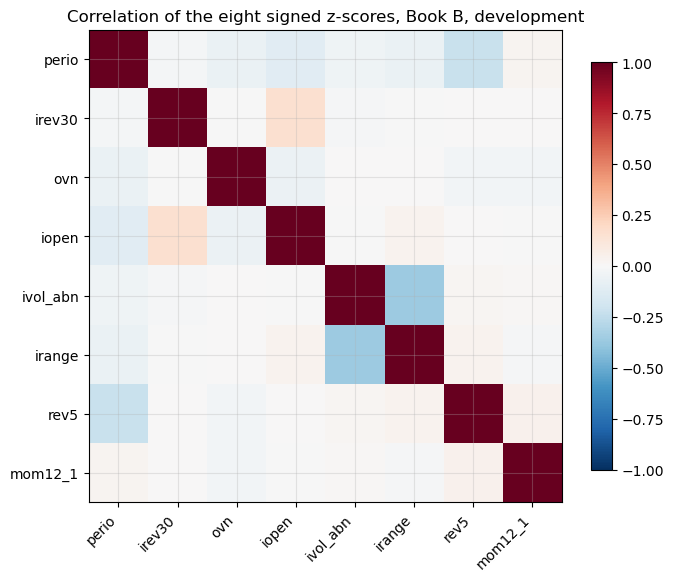

In [16]:
def period_of(sess_idx):
    d = S_W[sess_idx]
    return np.where(d <= DEV_END, "dev", np.where((d >= TEST_START) & (d <= TEST_END), "test",
                    np.where(d >= HOLD_START, "hold", "gap")))

for b in "ABC":
    PAN[b]["period"] = period_of(PAN[b]["sess"])
    PAN[b]["date"] = S_W[PAN[b]["sess"]]

rows = []
for b in "ABC":
    P = PAN[b]; dev = P["period"] == "dev"
    valid = np.arange(NMAX)[None, :] < P["n"][dev][:, None]
    for j, a in enumerate(ALPHAS):
        z = P["Z"][dev][:, j, :]
        rows.append({"book": b, "alpha": a, "coverage": np.isfinite(z)[valid].mean()})
cov_a = pd.DataFrame(rows).pivot(index="alpha", columns="book", values="coverage").loc[ALPHAS]
display(cov_a.round(3))

PB = PAN["B"]; dev = PB["period"] == "dev"
Zdev = PB["Z"][dev]                                                          # (F, 8, NMAX)
flat = np.moveaxis(Zdev, 1, 0).reshape(NA, -1)
keep = np.isfinite(flat).sum(0) >= 2
corr = pd.DataFrame(flat[:, keep]).T.corr().to_numpy()
corr = pd.DataFrame(corr, index=ALPHAS, columns=ALPHAS)
display(corr.round(2))
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.to_numpy(), vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(NA)); ax.set_xticklabels(ALPHAS, rotation=45, ha="right")
ax.set_yticks(range(NA)); ax.set_yticklabels(ALPHAS)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation of the eight signed z-scores, Book B, development")
plt.tight_layout(); plt.show()

## 4. Univariate information coefficients

For each alpha, book window and period, the Pearson correlation between the signed z-score and the hedged
target is computed formation by formation (pairwise-complete, more than 30 names), and averaged over the
**probe** formations: every fifth session of the trading range, and for Book C every bar of every fifth
session. Probe sessions are five sessions apart, so the windows they score do not overlap (a 24-hour window
of Book B on one probe session cannot reach the next), and the standard error is the standard deviation of
those formation-level correlations over the square root of their count. The table also gives the mean number
of names in the pairwise-complete cross-section. The Benjamini–Hochberg verdict at q = 0.10 is computed once,
across the eight alphas' development p-values on Book B's window. Only the development and test periods are
shown here; the hold-out waits for §9.

In [17]:
def row_corr(X, Y, min_n=30, chunk=4000):
    # Pearson correlation of X and Y along axis 1, pairwise-complete; NaN unless more than min_n valid pairs
    F = X.shape[0]
    out, cnt = np.full(F, np.nan), np.zeros(F, int)
    for a in range(0, F, chunk):
        x, y = X[a:a + chunk].astype(np.float64), Y[a:a + chunk].astype(np.float64)
        m = np.isfinite(x) & np.isfinite(y)
        n = m.sum(1)
        with np.errstate(all="ignore"):
            xm = np.where(m, x, 0.0); ym = np.where(m, y, 0.0)
            xc = np.where(m, x - (xm.sum(1) / n)[:, None], 0.0)
            yc = np.where(m, y - (ym.sum(1) / n)[:, None], 0.0)
            c = (xc * yc).sum(1) / np.sqrt((xc ** 2).sum(1) * (yc ** 2).sum(1))
        c[n <= min_n] = np.nan
        out[a:a + chunk], cnt[a:a + chunk] = c, n
    return out, cnt

trade_pos = np.array(sess_list)
PROBE_SESS = set(trade_pos[::5])
ICF, ICN = {}, {}
t0 = time.time()
for b in "ABC":
    P = PAN[b]
    P["probe"] = np.isin(P["sess"], list(PROBE_SESS))
    ICF[b] = np.full((len(P["sess"]), NA), np.nan); ICN[b] = np.zeros((len(P["sess"]), NA), int)
    for j in range(NA):
        ICF[b][:, j], ICN[b][:, j] = row_corr(P["Z"][:, j, :], P["Y"])
print(f"formation-level ICs for all three books and eight alphas in {time.time() - t0:.0f}s; "
      f"{len(PROBE_SESS):,} probe sessions")

def ic_stats(b, j, period, ic_arr=None, cnt_arr=None):
    P = PAN[b]
    arr = ICF[b][:, j] if ic_arr is None else ic_arr
    m = P["probe"] & (P["period"] == period) & np.isfinite(arr)
    a = arr[m]
    if len(a) < 2:
        return dict(ic=np.nan, se=np.nan, t=np.nan, n=len(a), names=np.nan)
    ic, se = a.mean(), a.std(ddof=1) / np.sqrt(len(a))
    names = (ICN[b][m, j].mean() if cnt_arr is None else cnt_arr[m].mean())
    return dict(ic=ic, se=se, t=ic / se if se > 0 else np.nan, n=len(a), names=names)

def ic_table(b, periods=("dev", "test")):
    rows = {}
    for j, a in enumerate(ALPHAS):
        r = {}
        for p in periods:
            g = ic_stats(b, j, p)
            r[f"{p}_ic"], r[f"{p}_se"], r[f"{p}_t"], r[f"{p}_n"], r[f"{p}_names"] = g["ic"], g["se"], g["t"], g["n"], g["names"]
        rows[a] = r
    return pd.DataFrame(rows).T

icB = ic_table("B")
icB["sign_agrees_dev"] = icB["dev_ic"] > 0
dev_p = 2 * stats.t.sf(np.abs(icB["dev_t"].astype(float)), df=(icB["dev_n"].astype(float) - 1))
reject, p_adj = benjamini_hochberg_fdr(dev_p, alpha=0.10)
icB["bh_pass_dev"] = reject
print("Book B (15:30 to the next 15:30), h = one session:")
display(icB.round(4))
print(f"Book B development ICs with the pre-registered sign: {int(icB['sign_agrees_dev'].sum())} of {NA}")
print(f"Benjamini-Hochberg (q=0.10) survivors among the eight Book B development ICs: {int(icB['bh_pass_dev'].sum())} of {NA}")

formation-level ICs for all three books and eight alphas in 2s; 786 probe sessions
Book B (15:30 to the next 15:30), h = one session:


,dev_ic,dev_se,dev_t,dev_n,dev_names,test_ic,test_se,test_t,test_n,test_names,sign_agrees_dev,bh_pass_dev
perio,-0.0022,0.0042,-0.5401,453.0,431.6976,-0.0011,0.0066,-0.1693,202.0,412.8614,False,False
irev30,0.0255,0.0063,4.0172,453.0,431.6976,0.0034,0.0096,0.3536,202.0,412.8614,True,True
ovn,0.0034,0.0029,1.1432,453.0,431.6909,0.0002,0.0049,0.0402,202.0,412.8614,True,False
iopen,0.0131,0.0068,1.9343,453.0,431.6932,0.0246,0.0113,2.1718,202.0,412.8614,True,False
ivol_abn,-0.0035,0.0029,-1.2074,453.0,431.6976,0.0044,0.0048,0.9000,202.0,412.8465,False,False
irange,0.0102,0.0028,3.6134,453.0,431.6976,0.0000,0.0044,0.0062,202.0,412.8614,True,True
rev5,0.0013,0.0040,0.3252,453.0,431.6976,0.0051,0.0064,0.7884,202.0,412.8614,True,False
mom12_1,0.0013,0.0033,0.3952,453.0,431.6976,-0.0047,0.0052,-0.9131,202.0,412.8614,True,False


Book B development ICs with the pre-registered sign: 6 of 8
Benjamini-Hochberg (q=0.10) survivors among the eight Book B development ICs: 2 of 8


Book A (10:30 to the close):


,dev_ic,dev_se,dev_t,dev_n,dev_names,test_ic,test_se,test_t,test_n,test_names
perio,0.0036,0.0035,1.0227,453.0,431.9272,-0.0030,0.0055,-0.5414,202.0,413.1733
irev30,0.0112,0.0064,1.7544,453.0,431.9272,0.0239,0.0095,2.5209,202.0,413.1733
ovn,0.0041,0.0032,1.2528,453.0,431.9249,0.0019,0.0054,0.3520,202.0,413.1733
iopen,0.0150,0.0069,2.1705,453.0,431.9272,0.0253,0.0105,2.4178,202.0,413.1733
ivol_abn,0.0095,0.0029,3.2491,453.0,431.9227,-0.0017,0.0044,-0.3941,202.0,413.1733
irange,-0.0026,0.0029,-0.8706,453.0,431.9272,0.0041,0.0043,0.9543,202.0,413.1733
rev5,0.0097,0.0037,2.6360,453.0,431.9272,0.0069,0.0058,1.1893,202.0,413.1733
mom12_1,0.0009,0.0034,0.2812,453.0,431.9272,0.0032,0.0053,0.6038,202.0,413.1733


Book C (each 30-minute bar):


,dev_ic,dev_se,dev_t,dev_n,dev_names,test_ic,test_se,test_t,test_n,test_names
perio,0.0034,0.0009,3.7897,5412.0,431.9278,-0.0004,0.0014,-0.2546,2412.0,413.1692
irev30,0.0409,0.0020,20.8104,5412.0,431.9274,0.0266,0.0030,8.8733,2412.0,413.1692
ovn,0.0013,0.0009,1.4691,5412.0,431.9224,-0.0004,0.0014,-0.2709,2412.0,413.1692
iopen,0.0178,0.0020,8.7967,5412.0,431.9246,0.0148,0.0031,4.8458,2412.0,413.1692
ivol_abn,0.0058,0.0008,6.8270,5412.0,431.8368,-0.0002,0.0013,-0.1182,2412.0,413.1633
irange,-0.0003,0.0009,-0.4011,5412.0,431.9278,0.0007,0.0013,0.5299,2412.0,413.1687
rev5,0.0026,0.0011,2.4120,5412.0,431.9278,0.0034,0.0018,1.8880,2412.0,413.1692
mom12_1,0.0007,0.0009,0.7445,5412.0,431.9278,0.0015,0.0015,1.0267,2412.0,413.1692


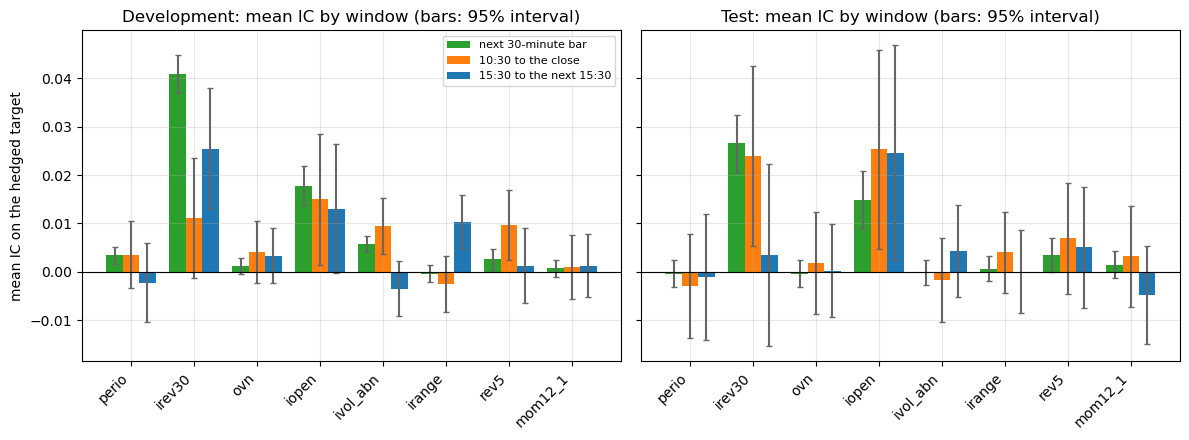

In [18]:
icA, icC = ic_table("A"), ic_table("C")
print("Book A (10:30 to the close):")
display(icA.round(4))
print("Book C (each 30-minute bar):")
display(icC.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, per in zip(axes, ("dev", "test")):
    w = 0.26
    for q, (b, lab, col) in enumerate((("C", "next 30-minute bar", "tab:green"), ("A", "10:30 to the close", "tab:orange"),
                                       ("B", "15:30 to the next 15:30", "tab:blue"))):
        tab = {"A": icA, "B": icB, "C": icC}[b]
        ax.bar(np.arange(NA) + (q - 1) * w, tab[f"{per}_ic"].astype(float), width=w, label=lab, color=col,
               yerr=1.96 * tab[f"{per}_se"].astype(float), capsize=2, ecolor="0.4")
    ax.set_xticks(range(NA)); ax.set_xticklabels(ALPHAS, rotation=45, ha="right")
    ax.axhline(0, color="k", lw=0.8)
    ax.set_title(f"{'Development' if per == 'dev' else 'Test'}: mean IC by window (bars: 95% interval)")
axes[0].set_ylabel("mean IC on the hedged target"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

**What the tables say.** On Book B's window six of the eight development ICs had the pre-registered sign (`perio` and
`ivol_abn` did not) and two survived Benjamini–Hochberg at q = 0.10: `irev30` (IC 0.0255, s.e. 0.0063, t = 4.0172) and
`irange` (0.0102, s.e. 0.0028, t = 3.6134). Neither carried into the test period (0.0034, t = 0.3536, and 0.0000,
t = 0.0062). The only alpha above two standard errors there was `iopen` (0.0246, t = 2.1718), which had not passed in
development (0.0131, t = 1.9343, just under two). Six of the eight test ICs were positive (`ovn` at 0.0002 and `irange`
at 0.0000 only barely); `perio` and `mom12_1` were not. The two daily controls were small in both periods (`rev5`
0.0013 and 0.0051, `mom12_1` 0.0013 and −0.0047).

On Book A's window (10:30 to the close) `iopen` (0.0150, t = 2.1705), `ivol_abn` (0.0095, t = 3.2491) and `rev5` (0.0097,
t = 2.6360) were the development ICs above two standard errors, and `irev30` (0.0239, t = 2.5209) and `iopen` (0.0253,
t = 2.4178) the ones in the test period; no rule was applied to Book A's table. On Book C's window, the next 30-minute
bar, `irev30` had an IC of 0.0409 (s.e. 0.0020, t = 20.8104) in development and 0.0266 (t = 8.8733) in the test period,
and `iopen` 0.0178 (t = 8.7967) and 0.0148 (t = 4.8458); the other alphas were near zero in the test period, `ivol_abn`
(−0.0002) and `perio` (−0.0004) among them. Book C's standard errors treat every bar of a probe session as independent,
which the bars of one session are not, so its t-statistics are the least reliable in the tables. What the alphas carry
is a short-horizon reversal (`irev30`, `iopen`), largest on the next 30-minute bar. The hold-out counterparts of these
tables are in §9.0.

## 5. Blends

**Equal-weight (the decision blend)**: the mean of the eight signed z-scores at each formation, computed over the
alphas a name has (a name missing an alpha is blended from the others rather than dropped). A second
equal-weight blend of alphas 7 and 8 alone (`rev5` and `mom12_1`, the daily controls) is kept for the
secondary question.

**Ridge**: the book's hedged target regressed on the eight signed z-scores pooled over (name, formation) rows of
the trailing 36 months, refit at the first session of every month, walk-forward. The penalty is chosen from
{0.1, 1, 10, 100} times the mean diagonal of X'X by leave-one-calendar-year-out cross-validation inside the
trailing window, and the final fit for the month uses the whole window at the chosen penalty. A formation
enters the history only once its target has realized: for Book B (24-hour target) a session's formation is
admitted at the refit only if the session is at least one session older than the refit date, and for Books A
and C (targets realized the same day) any earlier session is. Missing z-scores enter the design as zero. A
refit needs at least a year of admitted history. Because the ridge only needs the cross-products of the design
and the target, they are computed once per formation and added up, which makes every refit, every
cross-validation fold and every placebo draw a small linear-algebra problem.

**Where the blend disagrees with the univariate sign.** The coefficients act on already-signed z-scores, so a
negative coefficient means the blend wants that alpha to point the other way from its pre-registered sign that
month. For each book the table gives, per alpha, the share of monthly refits with a negative coefficient and
whether the **median** coefficient over the refits disagrees in sign with the pre-registration.

In [19]:
def blend_ew(P, cols=None):
    Z = P["Z"] if cols is None else P["Z"][:, cols, :]
    out = np.empty((Z.shape[0], NMAX), np.float32)
    for a in range(0, Z.shape[0], 4000):
        with np.errstate(all="ignore"):
            out[a:a + 4000] = np.nanmean(Z[a:a + 4000], axis=1)
    return out

date_arr = S_W[trade_pos]
year_arr = np.asarray(date_arr.year)
pos_of_sess = {int(s): i for i, s in enumerate(trade_pos)}
MIN_RIDGE_SESSIONS = 100 if SMOKE else 252

def formation_stats(P, Zr, chunk=2000):
    # per-session sums of X'X, X'y, y'y and the row count, over the rows that have a target
    Sn = len(trade_pos)
    XTX, XTY = np.zeros((Sn, NA, NA)), np.zeros((Sn, NA))
    YTY, NN = np.zeros(Sn), np.zeros(Sn)
    pos = np.array([pos_of_sess[int(s)] for s in P["sess"]])
    for a in range(0, len(pos), chunk):
        z = np.nan_to_num(Zr[a:a + chunk], nan=0.0).astype(np.float64)
        y = P["Y"][a:a + chunk].astype(np.float64)
        m = np.isfinite(y)
        z = z * m[:, None, :]; y = np.where(m, y, 0.0)
        np.add.at(XTX, pos[a:a + chunk], np.einsum("fan,fbn->fab", z, z))
        np.add.at(XTY, pos[a:a + chunk], np.einsum("fan,fn->fa", z, y))
        np.add.at(YTY, pos[a:a + chunk], (y ** 2).sum(1))
        np.add.at(NN, pos[a:a + chunk], m.sum(1))
    return XTX, XTY, YTY, NN

first_of_month = pd.Series(np.arange(len(date_arr)), index=date_arr).groupby(date_arr.to_period("M")).min().to_numpy()

def ridge_walk(st, lag):
    XTX, XTY, YTY, NN = st
    cs = [np.concatenate([np.zeros((1,) + x.shape[1:]), np.cumsum(x, axis=0)]) for x in (XTX, XTY, YTY, NN)]
    take = lambda a, b: tuple(c[b] - c[a] for c in cs)
    coef_at = np.zeros((len(date_arr), NA))
    refits, mult_log = {}, []
    for pos in first_of_month:
        d = date_arr[pos]
        lo = int(date_arr.searchsorted(d - pd.DateOffset(months=RIDGE_TRAIL_MONTHS), side="left"))
        hi = pos - lag                                                     # sessions p with p + lag < pos
        if hi - lo < MIN_RIDGE_SESSIONS:
            continue
        tot = take(lo, hi)
        pieces = []
        for y in np.unique(year_arr[lo:hi]):
            idx = np.flatnonzero(year_arr == y)
            pieces.append(take(max(lo, idx[0]), min(hi, idx[-1] + 1)))
        mult = RIDGE_GRID[1]
        if len(pieces) >= 2:
            scores = {}
            for mu in RIDGE_GRID:
                mses = []
                for h in pieces:
                    tr = tuple(t_ - h_ for t_, h_ in zip(tot, h))
                    if tr[3] < 50 or h[3] < 10:
                        continue
                    lam = mu * np.mean(np.diag(tr[0]))
                    c = np.linalg.solve(tr[0] + lam * np.eye(NA), tr[1])
                    mses.append((h[2] - 2 * c @ h[1] + c @ h[0] @ c) / h[3])
                if mses:
                    scores[mu] = float(np.mean(mses))
            mult = min(scores, key=scores.get) if scores else RIDGE_GRID[1]
        lam = mult * np.mean(np.diag(tot[0]))
        coef = np.linalg.solve(tot[0] + lam * np.eye(NA), tot[1])
        refits[int(pos)] = coef
        mult_log.append({"refit": d, "lambda_mult": mult, "rows": int(tot[3])})
        coef_at[pos:] = coef
    return coef_at, refits, pd.DataFrame(mult_log)

def ridge_scores(P, coef_at, Zr=None, chunk=2000):
    pos = np.array([pos_of_sess[int(s)] for s in P["sess"]])
    out = np.zeros((len(pos), NMAX), np.float32)
    for a in range(0, len(pos), chunk):
        z = np.nan_to_num((P["Z"] if Zr is None else Zr)[a:a + chunk], nan=0.0)
        out[a:a + chunk] = np.einsum("fan,fa->fn", z, coef_at[pos[a:a + chunk]]).astype(np.float32)
    return out

t0 = time.time()
SCORE, RIDGE_COEF, RIDGE_LOG, STATS = {}, {}, {}, {}
LAG = {"A": 0, "B": 1, "C": 0}
for b in "ABC":
    P = PAN[b]
    SCORE[(b, "ew")] = blend_ew(P)
    STATS[b] = formation_stats(P, P["Z"])
    coef_at, refits, log = ridge_walk(STATS[b], LAG[b])
    RIDGE_COEF[b], RIDGE_LOG[b] = refits, log
    SCORE[(b, "ridge")] = ridge_scores(P, coef_at)
    n_first = min(refits) if refits else None
    print(f"Book {b}: {len(refits)} monthly ridge refits, first {date_arr[n_first].date() if n_first is not None else 'none'}")
SCORE[("B", "ew78")] = blend_ew(PAN["B"], cols=[ALPHAS.index("rev5"), ALPHAS.index("mom12_1")])
print(f"blends built in {time.time() - t0:.0f}s")
display(RIDGE_LOG["B"]["lambda_mult"].value_counts().to_frame("Book B refits at this penalty multiple").T)

Book A: 176 monthly ridge refits, first 2011-01-03


Book B: 175 monthly ridge refits, first 2011-02-01


Book C: 176 monthly ridge refits, first 2011-01-03
blends built in 3s


lambda_mult,1.0,0.1,10.0,100.0
Book B refits at this penalty multiple,74,61,27,13


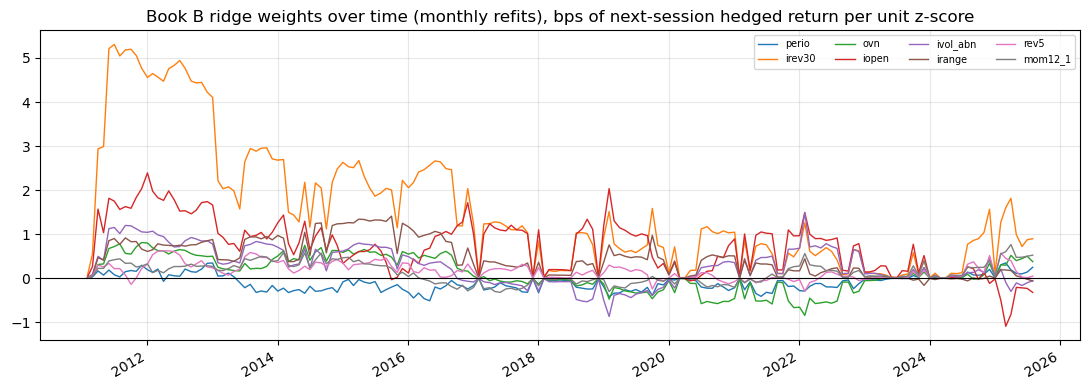

Book B: ridge coefficients over 143 monthly refits up to the end of the test period


,share of refits with coef < 0,median coefficient (bps per z),median coef disagrees with SIGN
perio,0.818,-0.171,True
ovn,0.483,0.037,False
mom12_1,0.434,0.043,False
ivol_abn,0.301,0.352,False
rev5,0.154,0.155,False
iopen,0.028,0.958,False
irev30,0.000,1.217,False
irange,0.000,0.468,False


  4 of 8 alphas have a negative coefficient (disagree with the pre-registered sign) in more than a quarter of refits: ['perio', 'ovn', 'mom12_1', 'ivol_abn']
  alphas whose MEDIAN ridge coefficient disagrees in sign with the pre-registered sign: ['perio']
Book A: ridge coefficients over 144 monthly refits up to the end of the test period


,share of refits with coef < 0,median coefficient (bps per z),median coef disagrees with SIGN
mom12_1,0.465,0.015,False
irange,0.403,0.038,False
rev5,0.278,0.179,False
ivol_abn,0.222,0.285,False
perio,0.056,0.245,False
ovn,0.042,0.258,False
irev30,0.000,0.943,False
iopen,0.000,0.642,False


  3 of 8 alphas have a negative coefficient (disagree with the pre-registered sign) in more than a quarter of refits: ['mom12_1', 'irange', 'rev5']
  alphas whose MEDIAN ridge coefficient disagrees in sign with the pre-registered sign: []
Book C: ridge coefficients over 144 monthly refits up to the end of the test period


,share of refits with coef < 0,median coefficient (bps per z),median coef disagrees with SIGN
mom12_1,0.486,0.001,False
irange,0.382,0.016,False
rev5,0.188,0.035,False
ivol_abn,0.049,0.139,False
perio,0.021,0.093,False
irev30,0.000,0.886,False
ovn,0.000,0.057,False
iopen,0.000,0.197,False


  2 of 8 alphas have a negative coefficient (disagree with the pre-registered sign) in more than a quarter of refits: ['mom12_1', 'irange']
  alphas whose MEDIAN ridge coefficient disagrees in sign with the pre-registered sign: []


In [20]:
fig, ax = plt.subplots(figsize=(11, 4))
cB = pd.DataFrame({date_arr[p]: c for p, c in RIDGE_COEF["B"].items()}, index=ALPHAS).T
(cB * 1e4).plot(ax=ax, lw=1.0)
ax.axhline(0, color="k", lw=0.8)
ax.set_title("Book B ridge weights over time (monthly refits), bps of next-session hedged return per unit z-score")
ax.legend(fontsize=7, ncol=4)
plt.tight_layout(); plt.show()

def sign_table(b):
    c = pd.DataFrame({date_arr[p]: v for p, v in RIDGE_COEF[b].items()}, index=ALPHAS).T
    c = c[c.index <= TEST_END]                                             # the hold-out refits wait for section 9
    t = pd.concat([(c < 0).mean().rename("share of refits with coef < 0"),
                   (c.median() * 1e4).rename("median coefficient (bps per z)")], axis=1)
    t["median coef disagrees with SIGN"] = t["median coefficient (bps per z)"] < 0
    return t.sort_values("share of refits with coef < 0", ascending=False), len(c)

for b in "BAC":
    t, n_ref = sign_table(b)
    print(f"Book {b}: ridge coefficients over {n_ref} monthly refits up to the end of the test period")
    display(t.round(3))
    flipped = t.index[t["share of refits with coef < 0"] > 0.25].tolist()
    print(f"  {len(flipped)} of {NA} alphas have a negative coefficient (disagree with the pre-registered sign) in more than a "
          f"quarter of refits: {flipped}")
    print(f"  alphas whose MEDIAN ridge coefficient disagrees in sign with the pre-registered sign: "
          f"{t.index[t['median coef disagrees with SIGN']].tolist()}")

### 5.1 Blend information coefficients, and the intraday-versus-daily question

The blend IC is the correlation of the blend score with the book's hedged target, on the same probe
formations as §4. For the secondary question, the eight-alpha equal-weight IC is compared with that of the
two daily controls alone **formation by formation**, so the standard error of the difference uses the paired
differences. Pairing helps only as far as the two blends' formation-level ICs move together, and they share
just two of the eight alphas, so the cell below prints that correlation next to the three standard errors instead
of assuming it is high.

In [21]:
BLEND_IC = {}
for key, sc in SCORE.items():
    BLEND_IC[key] = row_corr(sc, PAN[key[0]]["Y"])
rows = []
for key in [("B", "ew"), ("B", "ridge"), ("B", "ew78"), ("A", "ew"), ("A", "ridge"), ("C", "ew"), ("C", "ridge")]:
    row = {"book": key[0], "blend": key[1]}
    for p in ("dev", "test"):
        g = ic_stats(key[0], 0, p, ic_arr=BLEND_IC[key][0], cnt_arr=BLEND_IC[key][1])
        row[f"{p}_ic"], row[f"{p}_se"], row[f"{p}_t"] = g["ic"], g["se"], g["t"]
    rows.append(row)
blend_ic_tab = pd.DataFrame(rows).set_index(["book", "blend"])
display(blend_ic_tab.round(4))

P = PAN["B"]
diff = BLEND_IC[("B", "ew")][0] - BLEND_IC[("B", "ew78")][0]
ADD = {}
for p in ("dev", "test"):
    m = P["probe"] & (P["period"] == p) & np.isfinite(diff)
    a = diff[m]
    ADD[p] = dict(diff=a.mean(), se=a.std(ddof=1) / np.sqrt(len(a)), n=len(a))
    ADD[p]["t"] = ADD[p]["diff"] / ADD[p]["se"]
print(f"Book B, eight-alpha equal-weight IC minus the IC of alphas 7 and 8 alone (paired over probe formations):")
for p in ("dev", "test"):
    print(f"  {p}: difference {ADD[p]['diff']:+.4f}, s.e. {ADD[p]['se']:.4f}, ratio {ADD[p]['t']:+.2f}, {ADD[p]['n']} formations")
print(f"development difference exceeds twice its s.e.: {ADD['dev']['diff'] > 2 * ADD['dev']['se']}; "
      f"same sign in the test period: {np.sign(ADD['test']['diff']) == np.sign(ADD['dev']['diff'])}")

def pairing_row(p):
    ic8, ic2 = BLEND_IC[("B", "ew")][0], BLEND_IC[("B", "ew78")][0]
    m = PAN["B"]["probe"] & (PAN["B"]["period"] == p) & np.isfinite(ic8) & np.isfinite(ic2)
    a8, a2 = ic8[m], ic2[m]
    return {"period": p, "formations": int(m.sum()), "s.e. eight-alpha blend": a8.std(ddof=1) / np.sqrt(m.sum()),
            "s.e. controls blend": a2.std(ddof=1) / np.sqrt(m.sum()),
            "s.e. paired difference": (a8 - a2).std(ddof=1) / np.sqrt(m.sum()),
            "correlation of formation ICs": float(np.corrcoef(a8, a2)[0, 1])}
pairing_tab = pd.DataFrame([pairing_row(p) for p in ("dev", "test")]).set_index("period")
display(pairing_tab.round(4))

dev_ic  dev_se    dev_t  test_ic  test_se  test_t
book blend                                                   
B    ew     0.0182  0.0047   3.8568   0.0131   0.0075  1.7481
     ridge  0.0236  0.0066   3.5837   0.0084   0.0086  0.9743
     ew78   0.0015  0.0036   0.4175   0.0005   0.0058  0.0782
A    ew     0.0186  0.0047   3.9454   0.0220   0.0076  2.9112
     ridge  0.0135  0.0064   2.0922   0.0266   0.0099  2.6907
C    ew     0.0261  0.0014  18.5189   0.0167   0.0022  7.6420
     ridge  0.0390  0.0021  18.7807   0.0279   0.0030  9.3381

Book B, eight-alpha equal-weight IC minus the IC of alphas 7 and 8 alone (paired over probe formations):
  dev: difference +0.0167, s.e. 0.0046, ratio +3.64, 453 formations
  test: difference +0.0127, s.e. 0.0072, ratio +1.77, 202 formations
development difference exceeds twice its s.e.: True; same sign in the test period: True


,formations,s.e. eight-alpha blend,s.e. controls blend,s.e. paired difference,correlation of formation ICs
period,,,,,
dev,453,0.0047,0.0036,0.0046,0.4127
test,202,0.0075,0.0058,0.0072,0.4472


**What the tables say.** On Book B the equal-weight blend's IC was 0.0182 (s.e. 0.0047) in development and 0.0131
(s.e. 0.0075) in the test period. The ridge blend's was higher in development, 0.0236 (s.e. 0.0066), and lower in the
test period, 0.0084 (s.e. 0.0086). The blend of the two daily controls alone had 0.0015 (s.e. 0.0036) and 0.0005
(s.e. 0.0058). The paired difference between the eight-alpha blend and the controls was +0.0167 (s.e. 0.0046, ratio
+3.64, 453 formations) in development and +0.0127 (s.e. 0.0072, ratio +1.77, 202 formations) in the test period:
significant in the first, and of the same sign but not significant on its own in the second, which is what rule two
asks for. The paired s.e. is about the eight-alpha blend's own (0.0046 against 0.0047 in development, 0.0072 against 0.0075 in
the test period) and larger than the controls blend's (0.0036 and 0.0058): the two blends' formation ICs correlate at
only 0.413 and 0.447, so pairing gains little. §9.0 adds the hold-out, where the sign reverses. On Book A the ridge blend's development IC was lower than
the equal-weight one (0.0135 against 0.0186), on Book C higher (0.0390 against 0.0261), and on C the ridge leaned on
`irev30` (median coefficient 0.886 bps per z-score).

**Where the ridge disagreed with the pre-registered signs.** On Book B the median `perio` coefficient was negative
(−0.171 bps per z-score, negative in 0.818 of the refits); its development IC was slightly negative too (−0.0022,
t = −0.5401), not distinguishable from zero, so the disagreement is a weak one. `ovn` and `mom12_1` were negative in
0.483 and 0.434 of the refits with medians near zero (0.037 and 0.043), so the fitted blend gave them no stable weight,
while `irev30` and `iopen` were positive in nearly every refit (medians 1.217 and 0.958). On Books A and C no median
disagreed; `mom12_1` was negative in 0.465 and 0.486 of the refits with medians of 0.015 and 0.001.

## 6. Books

Target weights are `neutralize(blend score, B) * CAP` with notebook 17's corrected, joint projection against the
loadings and a constant column (the loadings here are the session's 15 PCA betas, nine SPDR betas and the size
column), applied to the names that have a price at the formation instant, missing scores counted as zero. The
gross is notebook 12's one million dollars.

* **Book B, the decision instrument.** One formation per session at 15:30. Held weights move a fraction phi of
  the gap to target once per session (Garleanu–Pedersen partial adjustment) and the book is rescaled to the
  full gross; positions are held overnight and earn the window return to the next session's 15:30 with the
  ex-dividend credited, and pay 50 bp a year of borrow on the short notional. phi = 0.25 is primary; 1, 0.5 and
  0.1 are reported and never chosen from.
* **Book A.** One formation per session at 10:30, a full trade to target, flat at the close.
* **Book C.** A formation at every bar close from 10:00 to 15:30, a full trade to target each time, flat at
  the close. It exists to put the fundamental-law arithmetic and the cost cliff on the page at the desk's own
  frequency and is never selected on.

Rows are labeled by the **realization** date, the session the position's profit lands on (the next session for
Book B), while costs and turnover are charged on the session the trade is placed, as in notebook 17.
Books A and C hold nothing overnight and pay no borrow.

In [22]:
cost_cells = pd.read_parquet(CACHE / "xs_costs.parquet")
cost_ok = cost_cells[cost_cells["err"].eq("")]
COST_DAY = {int(y): g.set_index("ticker")["cost_used"] for y, g in cost_ok.groupby("year")}
MED_DAY = {y: float(v.median()) for y, v in COST_DAY.items()}
tick_arr = np.array([TICK_OF_CODE.get(c, "") for c in range(N_ID)])
book_years = sorted({int(y) for y in S_W[trade_pos].year})

def cost_vectors(y):
    r = np.full(N_ID, np.nan)
    sub = roll_tab[(roll_tab["year"] == y) & roll_tab["roll_bps"].notna()]
    ci = all_id_index.get_indexer(sub["ticker"].astype(str) + "|" + sub["id"].astype(str))
    ok = ci >= 0
    r[ci[ok]] = sub["roll_bps"].to_numpy()[ok]
    med = ROLL_MED.get(y, float(roll_tab["roll_bps"].median()))
    prim = COMMISSION_BPS + 0.5 * np.where(np.isfinite(r), r, med)        # primary basis: commission + half the Roll spread
    ser = COST_DAY.get(y)
    dflt = MED_DAY.get(y, float(cost_ok["cost_used"].median()))
    sec = dflt if ser is None else np.where(np.isfinite(ser.reindex(tick_arr).to_numpy()), ser.reindex(tick_arr).to_numpy(), dflt)
    return prim, np.broadcast_to(sec, (N_ID,)).astype(float)

CV_P, CV_D = {}, {}
for y in book_years:
    CV_P[y], CV_D[y] = cost_vectors(y)
mid = book_years[len(book_years) // 2]
print(f"primary cost basis (commission plus half the Roll spread): median {np.median(CV_P[mid]):.2f} bps per name per side in {mid}; "
      f"secondary basis (notebook 14's day-lake measured costs): median {np.median(CV_D[mid]):.2f}")
print(f"stock costs reused from notebook 12/14: {len(cost_ok):,} of {len(cost_cells):,} (ticker, year) cells measured")

def neutral_targets(b, score):
    P = PAN[b]
    F = len(P["sess"])
    W = np.zeros((F, NMAX))
    for f in range(F):
        n = int(P["n"][f]); ok = P["ok"][f, :n]
        if ok.sum() < 30:
            continue
        sc = np.nan_to_num(score[f, :n].astype(np.float64))
        W[f, :n][ok] = neutralize(sc[ok], LOAD[int(P["sess"][f])]["B"][ok].astype(np.float64))
    return W

def _frame(rows, cols):
    return pd.DataFrame(rows, columns=cols).set_index("date")
BOOK_COLS = ["date", "s", "slot", "pnl_gross", "cost_p", "cost_d", "borrow", "traded", "gross", "n"]

def run_B(W, phi):
    P = PAN["B"]
    w_prev, rows = np.zeros(N_ID), []
    for f in range(len(P["sess"])):
        s, n = int(P["sess"][f]), int(P["n"][f]); codes = LOAD[s]["codes"]
        wt = np.zeros(N_ID); wt[codes] = W[f, :n] * CAP
        w = w_prev + phi * (wt - w_prev)
        g = np.abs(w).sum()
        if g > 0:
            w = w * (CAP / g)
        w[np.abs(w) < 1e-9] = 0.0
        dw = np.abs(w - w_prev)
        y = S_W[s].year
        r = np.zeros(N_ID); r[codes] = np.nan_to_num(P["R"][f, :n].astype(np.float64))
        rows.append((S_W[s + 1], s, int(P["slot"][f]), float((w * r).sum()), float((dw * CV_P[y]).sum() / 1e4),
                     float((dw * CV_D[y]).sum() / 1e4), float(-w[w < 0].sum() * BORROW_BPS / 1e4 / ANN),
                     float(dw.sum()), float(np.abs(w).sum()), int((w != 0).sum())))
        w_prev = w
    return _frame(rows, BOOK_COLS)

def run_A(W):
    P = PAN["A"]
    rows = []
    for f in range(len(P["sess"])):
        s, n = int(P["sess"][f]), int(P["n"][f]); codes = LOAD[s]["codes"]
        w = np.zeros(N_ID); w[codes] = W[f, :n] * CAP
        y = S_W[s].year
        r = np.zeros(N_ID); r[codes] = np.nan_to_num(P["R"][f, :n].astype(np.float64))
        aw = np.abs(w)
        rows.append((S_W[s], s, int(P["slot"][f]), float((w * r).sum()), float(2 * (aw * CV_P[y]).sum() / 1e4), np.nan, 0.0,
                     float(2 * aw.sum()), float(aw.sum()), int((w != 0).sum())))
    return _frame(rows, BOOK_COLS)

def run_C(W):
    # returns the formation-level frame; the session-level book is its daily sum
    P = PAN["C"]
    sess = P["sess"]; F = len(sess)
    rows, w_prev = [], np.zeros(N_ID)
    for f in range(F):
        s, n = int(sess[f]), int(P["n"][f]); codes = LOAD[s]["codes"]
        if f == 0 or sess[f - 1] != s:
            w_prev = np.zeros(N_ID)
        w = np.zeros(N_ID); w[codes] = W[f, :n] * CAP
        y = S_W[s].year
        dw = np.abs(w - w_prev)
        traded, cost = float(dw.sum()), float((dw * CV_P[y]).sum() / 1e4)
        if f == F - 1 or sess[f + 1] != s:                                    # flat at the close
            traded += float(np.abs(w).sum()); cost += float((np.abs(w) * CV_P[y]).sum() / 1e4)
        r = np.zeros(N_ID); r[codes] = np.nan_to_num(P["R"][f, :n].astype(np.float64))
        rows.append((S_W[s], s, int(P["slot"][f]), float((w * r).sum()), cost, np.nan, 0.0, traded,
                     float(np.abs(w).sum()), int((w != 0).sum())))
        w_prev = w
    return _frame(rows, BOOK_COLS)

def to_daily(bf):
    g = bf.groupby(level=0)
    out = g[["pnl_gross", "cost_p", "borrow", "traded"]].sum()
    out["cost_d"] = np.nan
    out["gross"] = g["gross"].mean()
    out["n"] = g["n"].mean()
    out["s"] = g["s"].first()
    return out

t0 = time.time()
TARGETS, BOOKS, BOOKS_F = {}, {}, {}
for blend in ("ew", "ridge", "ew78"):
    TARGETS[("B", blend)] = neutral_targets("B", SCORE[("B", blend)])
for blend in ("ew", "ridge"):
    for phi in PHIS:
        BOOKS[("B", blend, phi)] = run_B(TARGETS[("B", blend)], phi)
BOOKS[("B", "ew78", PHI_PRIMARY)] = run_B(TARGETS[("B", "ew78")], PHI_PRIMARY)
for blend in ("ew", "ridge"):
    TARGETS[("A", blend)] = neutral_targets("A", SCORE[("A", blend)])
    BOOKS[("A", blend, 1.0)] = run_A(TARGETS[("A", blend)])
    TARGETS[("C", blend)] = neutral_targets("C", SCORE[("C", blend)])
    BOOKS_F[("C", blend, 1.0)] = run_C(TARGETS[("C", blend)])
    BOOKS[("C", blend, 1.0)] = to_daily(BOOKS_F[("C", blend, 1.0)])
print(f"{len(BOOKS)} books built in {time.time() - t0:.0f}s: Book B two blends x four phi plus the daily-controls blend, "
      f"Books A and C two blends each at a full trade")

primary cost basis (commission plus half the Roll spread): median 2.64 bps per name per side in 2018; secondary basis (notebook 14's day-lake measured costs): median 2.08
stock costs reused from notebook 12/14: 11,913 of 11,992 (ticker, year) cells measured


13 books built in 15s: Book B two blends x four phi plus the daily-controls blend, Books A and C two blends each at a full trade


## 7. Costs and metrics

The **primary cost basis** is notebook 18's: one basis point of commission plus half the Roll spread per name per
side, the Roll spread estimated per name and calendar year from that year's one-minute closes (§1.3), with
unmeasured cells at that year's median, and 50 bp a year of borrow on overnight shorts. The **secondary basis**
is notebook 14's day-lake measured cost per (ticker, year), with the same borrow, so that Book B can be set
beside notebook 17's book on the same footing in §9. Sharpe ratios are annualized, with standard error
$\sqrt{252/\text{sessions}}$ on all sessions and again on the sessions where the book holds a position;
turnover per session is traded notional over the gross (both sides, notebook 17's convention); break-even cost
is gross P&L over traded notional in basis points, a per-side figure. Everything in this section stops at the
end of the test period.

In [23]:
def se_sharpe(n):
    return float(np.sqrt(ANN / n)) if n > 0 else np.nan

def vis(df):
    return df[df.index <= TEST_END]

def summarize(key, df=None, with_hold=False):
    d = vis(BOOKS[key]) if df is None else df
    net = d["pnl_gross"] - d["cost_p"] - d["borrow"]
    net_d = d["pnl_gross"] - d["cost_d"] - d["borrow"]
    pos = d["gross"] > 0
    n = len(d)
    seg = lambda lo=None, hi=None: net[((d.index >= lo) if lo is not None else True) & ((d.index <= hi) if hi is not None else True)]
    s_dev, s_test = sharpe(seg(hi=DEV_END) / CAP), sharpe(seg(TEST_START, TEST_END) / CAP)
    out = {"book": key[0], "blend": key[1], "phi": key[2],
           "gross Sharpe": sharpe(d["pnl_gross"] / CAP), "net Sharpe": sharpe(net / CAP),
           "net Sharpe, day-lake costs": sharpe(net_d / CAP) if net_d.notna().all() else np.nan,
           "s.e.": se_sharpe(n), "sessions": n, "with a position": int(pos.sum()),
           "net Sharpe, positioned sessions": sharpe(net[pos] / CAP), "s.e., positioned": se_sharpe(int(pos.sum())),
           "turnover / session": float((d["traded"] / d["gross"].replace(0, np.nan)).mean()),
           "break-even bps": float(d["pnl_gross"].sum() / d["traded"].sum() * 1e4),
           "net Sharpe dev": s_dev, "net Sharpe test": s_test,
           "t, test": s_test * np.sqrt(len(seg(TEST_START, TEST_END)) / ANN) if np.isfinite(s_test) else np.nan}
    out["net P&L dev ($k)"] = seg(hi=DEV_END).sum() / 1e3
    out["net P&L test ($k)"] = seg(TEST_START, TEST_END).sum() / 1e3
    if with_hold:
        out["net Sharpe hold-out"] = sharpe(seg(HOLD_START) / CAP)
        out["net P&L hold-out ($k)"] = seg(HOLD_START).sum() / 1e3
    return out

sum_keys = [("B", b, p) for b in ("ew", "ridge") for p in PHIS] + [("B", "ew78", PHI_PRIMARY)] + \
           [(b, bl, 1.0) for b in "AC" for bl in ("ew", "ridge")]
SUMMARY = pd.DataFrame([summarize(k) for k in sum_keys]).set_index(["book", "blend", "phi"])
display(SUMMARY.round(3))
print(f"sessions shown: {int(SUMMARY['sessions'].iloc[0]):,} of the book's, up to {TEST_END.date()}")

gross Sharpe  net Sharpe  net Sharpe, day-lake costs   s.e.  \
book blend phi                                                                 
B    ew    0.25         1.105       0.453                       0.533  0.278   
           1.00         2.498      -0.276                       0.100  0.278   
           0.50         1.787       0.455                       0.629  0.278   
           0.10         0.797       0.508                       0.538  0.278   
     ridge 0.25         1.168       0.385                       0.495  0.278   
           1.00         2.541      -0.778                      -0.268  0.278   
           0.50         2.065       0.314                       0.576  0.278   
           0.10         0.331       0.024                       0.060  0.278   
     ew78  0.25         0.550      -0.009                       0.056  0.278   
A    ew    1.00         3.743      -4.609                         NaN  0.278   
     ridge 1.00         3.151      -3.913                         NaN  0.278   
C    ew    1.00         9.214     -24.214                         NaN  0.278   
     ridge 1.00         9.911     -23.664                         NaN  0.278   

                 sessions  with a position  net Sharpe, positioned sessions  \
book blend phi                                                                
B    ew    0.25      3271             3271                            0.453   
           1.00      3271             3271                           -0.276   
           0.50      3271             3271                            0.455   
           0.10      3271             3271                            0.508   
     ridge 0.25      3271             2999                            0.402   
           1.00      3271             2999                           -0.813   
           0.50      3271             2999                            0.328   
           0.10      3271             2999                            0.025   
     ew78  0.25      3271             3271                           -0.009   
A    ew    1.00      3272             3272                           -4.609   
     ridge 1.00      3272             3020                           -4.084   
C    ew    1.00      3272             3272                          -24.214   
     ridge 1.00      3272             3020                          -27.292   

                 s.e., positioned  turnover / session  break-even bps  \
book blend phi                                                          
B    ew    0.25             0.278               0.263           5.467   
           1.00             0.278               1.119           2.636   
           0.50             0.278               0.547           4.056   
           0.10             0.278               0.102          10.545   
     ridge 0.25             0.290               0.308           4.782   
           1.00             0.290               1.358           2.263   
           0.50             0.290               0.707           3.564   
           0.10             0.290               0.110           4.081   
     ew78  0.25             0.278               0.194           3.355   
A    ew    1.00             0.278               2.000           1.280   
     ridge 1.00             0.289               2.000           1.284   
C    ew    1.00             0.278              11.170           0.805   
     ridge 1.00             0.289              16.659           0.818   

                 net Sharpe dev  net Sharpe test  t, test  net P&L dev ($k)  \
book blend phi                                                                
B    ew    0.25           0.651            0.176    0.352           163.275   
           1.00           0.077           -0.816   -1.632            17.468   
           0.50           0.723            0.085    0.170           170.868   
           0.10           0.634            0.322    0.643           170.745   
     ridge 0.25           0.553            0.162    0.325   

sessions shown: 3,271 of the book's, up to 2022-12-30


**What the table says.** Through the end of the test period Book B's equal-weight, phi = 0.25 book had a gross Sharpe of
1.105 and a net Sharpe of 0.453 on the primary basis and 0.533 on the day-lake basis (s.e. 0.278 on 3271 sessions),
with 0.263 of the gross traded each session and a break-even cost of 5.467 bps per side. On the primary basis the net
Sharpe was −0.276 at phi = 1.00, 0.455 at 0.50, 0.453 at 0.25 and 0.508 at 0.10, while the gross fell from 2.498 to
0.797. Damping from 1.00 to 0.50 saved far more in cost than it gave up in gross; below 0.50 the net was flat within a
fraction of a standard error, and not monotone (the four are reported, not chosen from). On the day-lake basis phi =
0.50, 0.25 and 0.10 were indistinguishable (0.629, 0.533, 0.538) and phi = 1.00 (0.100) was the lowest, by between one
and a half and two standard errors of the other three. The ridge blend was lower than equal-weight at every phi on both
bases through the test period (0.385 against 0.453 at phi = 0.25 on the primary basis). The book of the two daily
controls alone had a gross Sharpe of 0.550 and a net of −0.009, so the intraday alphas lifted the gross to 1.105 and
the net to 0.453: consistent with rule two through the test period (§9.0 shows the hold-out). Books A and C turned a
gross Sharpe of 3.743 and 9.214 into a net of −4.609 and −24.214, with break-even costs of 1.280 and 0.805 bps per
side, below the median primary cost of 2.64 bps (2018), at 2.000 and 11.170 of the gross traded per session.

### 7.1 P&L by year, and five-year blocks

Book B at the primary phi, both blends, on the primary cost basis. Years and blocks stop at the end of the test
period; the partial last block is labeled by the years it holds.

Book B, ew, phi=0.25, by year:


,gross Sharpe,net Sharpe,net P&L ($k)
date,,,
2010,3.215,2.326,54.038
2011,2.191,1.500,43.863
2012,0.261,-0.491,-13.580
2013,2.334,1.552,38.353
2014,1.649,0.850,22.696
2015,2.293,1.580,46.859
2016,-0.599,-1.229,-40.335
2017,1.078,0.259,6.977
2018,0.921,0.157,4.404


Book B, ew, phi=0.25, by five-year block:


,sessions,gross Sharpe,net Sharpe,s.e.
2010-2014,1257,1.874,1.100,0.448
2015-2019,1258,0.730,0.018,0.448
2020-2022,756,0.847,0.331,0.577


Book B, ridge, phi=0.25, by year:


,gross Sharpe,net Sharpe,net P&L ($k)
date,,,
2010,NaN,NaN,0.000
2011,2.266,1.252,27.805
2012,1.279,0.284,7.145
2013,3.334,2.198,44.594
2014,1.988,0.918,21.624
2015,1.796,0.779,19.025
2016,1.709,0.965,31.349
2017,0.205,-0.815,-20.471
2018,0.483,-0.335,-10.150


Book B, ridge, phi=0.25, by five-year block:


,sessions,gross Sharpe,net Sharpe,s.e.
2010-2014,1257,1.921,0.988,0.448
2015-2019,1258,0.911,0.054,0.448
2020-2022,756,0.952,0.304,0.577


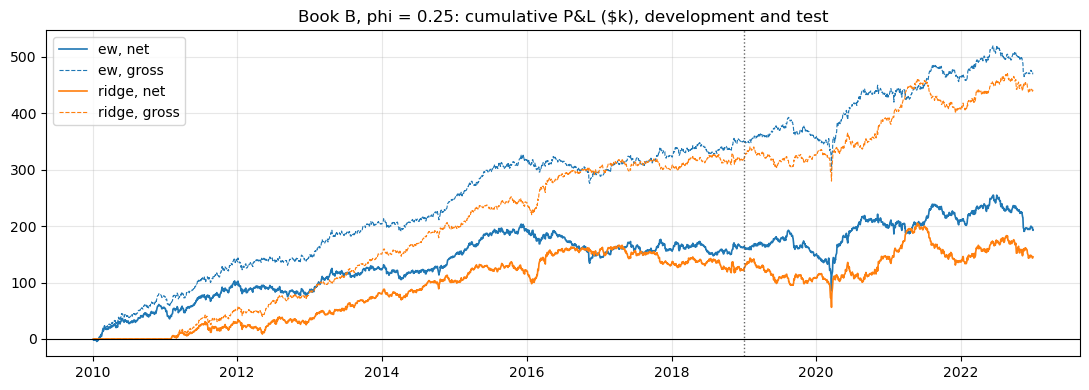

In [24]:
def by_year_table(key, upto=None):
    d = vis(BOOKS[key]) if upto is None else BOOKS[key][BOOKS[key].index <= upto]
    net = d["pnl_gross"] - d["cost_p"] - d["borrow"]
    g = pd.DataFrame({"gross": d["pnl_gross"], "net": net}).groupby(d.index.year)
    return pd.DataFrame({"gross Sharpe": g["gross"].apply(lambda x: sharpe(x / CAP)),
                         "net Sharpe": g["net"].apply(lambda x: sharpe(x / CAP)),
                         "net P&L ($k)": g["net"].sum() / 1e3})

def block_table(key, upto=None):
    d = vis(BOOKS[key]) if upto is None else BOOKS[key][BOOKS[key].index <= upto]
    net = d["pnl_gross"] - d["cost_p"] - d["borrow"]
    yrs = d.index.year
    blk = (yrs - FIRST_SESSION.year) // 5
    lab = pd.Series([f"{FIRST_SESSION.year + 5 * b}-{min(FIRST_SESSION.year + 5 * b + 4, yrs.max())}" for b in blk], index=d.index)
    g = pd.DataFrame({"gross": d["pnl_gross"], "net": net}).groupby(lab.to_numpy())
    return pd.DataFrame({"sessions": g.size(), "gross Sharpe": g["gross"].apply(lambda x: sharpe(x / CAP)),
                         "net Sharpe": g["net"].apply(lambda x: sharpe(x / CAP)),
                         "s.e.": [se_sharpe(n) for n in g.size()]})

prim_keys = [("B", "ew", PHI_PRIMARY), ("B", "ridge", PHI_PRIMARY)]
for k in prim_keys:
    print(f"Book B, {k[1]}, phi={k[2]}, by year:")
    display(by_year_table(k).round(3))
    print(f"Book B, {k[1]}, phi={k[2]}, by five-year block:")
    display(block_table(k).round(3))

fig, ax = plt.subplots(figsize=(11, 4))
for k, col in zip(prim_keys, ("tab:blue", "tab:orange")):
    d = vis(BOOKS[k])
    ax.plot(d.index, (d["pnl_gross"] - d["cost_p"] - d["borrow"]).cumsum() / 1e3, color=col, lw=1.2, label=f"{k[1]}, net")
    ax.plot(d.index, d["pnl_gross"].cumsum() / 1e3, color=col, lw=0.8, ls="--", label=f"{k[1]}, gross")
ax.axvline(DEV_END, color="0.4", ls=":", lw=1)
ax.axhline(0, color="k", lw=0.8); ax.legend()
ax.set_title(f"Book B, phi = {PHI_PRIMARY}: cumulative P&L ($k), development and test")
plt.tight_layout(); plt.show()

**What the tables say.** Book B's equal-weight net Sharpe by year ran from 2.326 in 2010 to −1.229 in 2016, and its
gross from 3.215 to −0.599 in 2016. The year 2012, which the first full run's interleaved Roll series had turned into
the one year that decided the sign of the period, lost 13.580 thousand dollars net on a gross Sharpe of 0.261, and no
single year decides the sign of the period; four years lost net (2012, 2016, 2019 and 2022). By five-year block the
equal-weight net Sharpe was 1.100, 0.018 and 0.331 (s.e. 0.448, 0.448 and 0.577); only the first was more than two
standard errors from zero, and the gross fell from 1.874 to 0.730 and then rose to 0.847, the decay of an edge that was
strong early in the sample and did not come back to its early level. The ridge blend's blocks were 0.988, 0.054 and
0.304, the first also just over two standard errors.

### 7.2 Exposures

Each book's net return regressed on SPY, the nine SPDRs, a size factor-mimicking return and a 12-1 momentum
factor-mimicking return, **all measured over the book's own realization window**: the ETFs' returns from the
formation instant to the end of the window (Book B: 15:30 to the next 15:30, dividends credited), and the two
mimicking returns are the characteristic's demeaned, unit-gross z-score at formation applied to the window
returns of the names. Aligning the regressors to the window matters for Book B, whose profit lands overnight:
regressing it on close-to-close returns would compare it with the wrong hours. Momentum is not neutralized (it
is an alpha under test), so its exposure is a measurement, not a zero by construction; SPY is not a factor of
the risk model, so its exposure tests whether the sector hedge left a market beta. Book C's regression is at
the formation level, one row per bar.

In [25]:
def formation_regressors(b):
    P = PAN[b]
    F = len(P["sess"])
    size_f, mom_f = np.zeros(F), np.zeros(F)
    for f in range(F):
        L, n = LOAD[int(P["sess"][f])], int(P["n"][f])
        okm = P["ok"][f, :n]
        r = np.nan_to_num(P["R"][f, :n].astype(np.float64))
        for zv, arr in ((L["sizez"], size_f), (L["momz"], mom_f)):
            zz = np.where(okm & np.isfinite(zv), zv, np.nan)
            m = np.isfinite(zz)
            if m.sum() < 10:
                continue
            w = zz[m] - zz[m].mean()
            g = np.abs(w).sum()
            if g > 1e-12:
                arr[f] = float((w / g * r[m]).sum())
    X = pd.DataFrame(P["E"], columns=ETF10)
    X["size"], X["mom12_1"] = size_f, mom_f
    return X

REGRESSORS = {b: formation_regressors(b) for b in "ABC"}

def exposure_table(key, upto=None):
    upto = TEST_END if upto is None else upto
    bf = BOOKS_F[key] if key[0] == "C" else BOOKS[key]
    X = REGRESSORS[key[0]]
    assert len(bf) == len(X)
    y = ((bf["pnl_gross"] - bf["cost_p"] - bf["borrow"]) / CAP).to_numpy()
    m = np.asarray(bf.index <= upto)
    fit = sm.OLS(y[m], sm.add_constant(X[m].to_numpy())).fit()
    return pd.DataFrame({"beta": fit.params, "t": fit.tvalues}, index=["const"] + list(X.columns))

EXPOSURE = {k: exposure_table(k) for k in [("B", "ew", PHI_PRIMARY), ("B", "ridge", PHI_PRIMARY), ("A", "ew", 1.0), ("C", "ew", 1.0)]}
for k, tab in EXPOSURE.items():
    print(f"exposures, Book {k[0]}, {k[1]}, phi={k[2]} (regressors over the realization window):")
    display(tab.round(3))
# the ten ETF regressors are almost collinear (SPY against the sum of the nine SPDRs), so their joint coefficients are not
# separately interpretable; the market exposure is read from SPY alone and from the sum of the ten betas
for k in EXPOSURE:
    bf = BOOKS_F[k] if k[0] == "C" else BOOKS[k]
    Xk = REGRESSORS[k[0]]
    yk = ((bf["pnl_gross"] - bf["cost_p"] - bf["borrow"]) / CAP).to_numpy()
    mk = np.asarray(bf.index <= TEST_END)
    f_spy = sm.OLS(yk[mk], sm.add_constant(Xk.loc[mk, ["SPY"]].to_numpy())).fit()
    tab = EXPOSURE[k]
    print(f"Book {k[0]} {k[1]}: SPY-only beta {f_spy.params[1]:+.3f} (t {f_spy.tvalues[1]:+.2f}); sum of the ten ETF betas in the "
          f"joint regression {tab.loc[ETF10, 'beta'].sum():+.3f}; corr(SPY window return, sum of nine SPDR returns) "
          f"{np.corrcoef(Xk['SPY'], Xk[ETF9].sum(axis=1))[0, 1]:.3f}")
big = pd.DataFrame({f"{k[0]}-{k[1]}": v["t"].drop("const").abs() for k, v in EXPOSURE.items()}).max()
print("largest absolute t-statistic on any factor exposure, by book: " + ", ".join(f"{i} {v:.2f}" for i, v in big.items()))

exposures, Book B, ew, phi=0.25 (regressors over the realization window):


,beta,t
const,0.000,0.140
SPY,-0.213,-5.502
XLB,0.009,1.521
XLE,0.019,5.595
XLF,0.025,3.939
XLI,0.010,1.322
XLK,0.071,5.738
XLP,0.000,0.066
XLU,0.007,1.544
XLV,0.033,4.105


exposures, Book B, ridge, phi=0.25 (regressors over the realization window):


,beta,t
const,0.000,1.516
SPY,0.011,0.296
XLB,0.005,0.821
XLE,0.013,3.953
XLF,0.004,0.698
XLI,-0.028,-3.660
XLK,-0.005,-0.391
XLP,-0.027,-3.640
XLU,-0.013,-3.043
XLV,0.021,2.699


exposures, Book A, ew, phi=1.0 (regressors over the realization window):


,beta,t
const,-0.000,-16.783
SPY,-0.049,-1.237
XLB,-0.005,-0.848
XLE,0.008,2.274
XLF,0.001,0.113
XLI,0.015,1.916
XLK,0.019,1.505
XLP,-0.010,-1.324
XLU,0.002,0.551
XLV,0.001,0.098


exposures, Book C, ew, phi=1.0 (regressors over the realization window):


,beta,t
const,-0.000,-101.379
SPY,-0.035,-3.430
XLB,-0.001,-0.720
XLE,0.002,2.449
XLF,0.003,1.582
XLI,0.006,2.773
XLK,0.013,3.785
XLP,-0.015,-7.325
XLU,-0.001,-1.026
XLV,0.012,5.373


Book B ew: SPY-only beta +0.028 (t +8.15); sum of the ten ETF betas in the joint regression +0.030; corr(SPY window return, sum of nine SPDR returns) 0.971
Book B ridge: SPY-only beta +0.025 (t +8.18); sum of the ten ETF betas in the joint regression +0.006; corr(SPY window return, sum of nine SPDR returns) 0.971
Book A ew: SPY-only beta +0.012 (t +4.65); sum of the ten ETF betas in the joint regression +0.007; corr(SPY window return, sum of nine SPDR returns) 0.979
Book C ew: SPY-only beta +0.005 (t +5.68); sum of the ten ETF betas in the joint regression -0.000; corr(SPY window return, sum of nine SPDR returns) 0.975
largest absolute t-statistic on any factor exposure, by book: B-ew 24.85, B-ridge 6.66, A-ew 9.74, C-ew 27.62


**What the tables say.** The joint regression's coefficients on SPY and the nine SPDRs are not separately interpretable:
the window returns of SPY and of the nine SPDRs together correlate at 0.971, so the equal-weight Book B's −0.213 on SPY
(t = −5.502) is offset by positive coefficients on the sector ETFs (largest 0.071 on XLK and 0.069 on XLY), and reading
it as a net short of a fifth of the gross would be wrong. The market exposure is what the two summary lines under the
tables give: a SPY-only beta of +0.028 (t = +8.15) and a sum of the ten joint betas of +0.030, a small net long. The
other books' SPY-only betas were similar small positives (+0.025, +0.012 and +0.005 for the ridge Book B, A and C),
with sums of the ten joint betas of +0.006, +0.007 and −0.000. The equal-weight Book B's exposure to the 12-1 momentum
mimicking return was large and positive (0.153, t = 24.852). That is the unneutralized `mom12_1` alpha, one eighth of
the blend score, showing up as an exposure by construction (its IC was 0.0013 in development and −0.0047 in the test
period), not as an edge. The intercept was 0.000 (t = 0.140). The ridge Book B had a small SPY coefficient (0.011,
t = 0.296), a size exposure of −0.081 (t = −4.155) and a momentum exposure of −0.040 (t = −6.661), the opposite sign to
the equal-weight book's. Books A and C had joint SPY coefficients of −0.049 (t = −1.237) and −0.035 (t = −3.430) and a
momentum exposure of 0.062 (t = 9.744) and 0.056 (t = 27.616); their intercepts, −0.000 with t-statistics of −16.783 and
−101.379, are their net loss, which is the cost, since no factor exposure explains it.

### 7.3 The five-clause scorecard for Book B

Notebook 14 section 9's five clauses, adapted as notebook 17 adapted them: the independent-bet unit is one
non-overlapping block of five sessions (positions persist for roughly four sessions at phi = 0.25, so trades
inside a block share most of their information), clause (b) is scored against the eight pre-registered alphas
(no other search was run), and clause (c) uses the test period here; the hold-out figure is added in §9.

In [26]:
def scorecard(key, upto=None, hold=False):
    d = (vis(BOOKS[key]) if upto is None else BOOKS[key][BOOKS[key].index <= upto]).copy()
    d["block"] = np.arange(len(d)) // 5
    net = d["pnl_gross"] - d["cost_p"] - d["borrow"]
    tr = d["traded"].replace(0, np.nan)
    gross_bps, cost_bps = d["pnl_gross"] / tr * 1e4, (d["cost_p"] + d["borrow"]) / tr * 1e4
    block_net = (net / tr * 1e4).groupby(d["block"]).mean().dropna()
    t_bets = float(block_net.mean() / (block_net.std(ddof=1) / np.sqrt(len(block_net))))
    t_needed = float(stats.norm.ppf(1 - (1 - 0.95 ** (1 / NA)) / 2))
    s_test = sharpe(net[(net.index >= TEST_START) & (net.index <= TEST_END)] / CAP)
    c_text = f"test-period net Sharpe {s_test:.3f}"
    if hold:
        c_text += f", hold-out net Sharpe {sharpe(net[net.index >= HOLD_START] / CAP):.3f}"
    return pd.DataFrame([
        {"clause": "(0) profit per bet beats cost per bet",
         "value": f"{gross_bps.mean():.2f} bps gross vs {cost_bps.mean():.2f} bps cost ({gross_bps.mean() / cost_bps.mean():.2f}x)"},
        {"clause": "(a) survives its own sampling error",
         "value": f"t = {t_bets:.2f} over {len(block_net):,} non-overlapping 5-session blocks"},
        {"clause": "(b) survives the search that found it",
         "value": f"t = {t_needed:.2f} needed for one of {NA} pre-registered alphas (Sidak); achieved t = {t_bets:.2f}"},
        {"clause": "(c) survives out of sample", "value": c_text},
        {"clause": "(d) large enough to be worth running",
         "value": f"${net.sum():,.0f} net P&L over {len(d) / ANN:.1f} years on a ${CAP:,.0f} book"},
    ]).set_index("clause")

for k in prim_keys:
    print(f"five-clause scorecard, Book B, {k[1]}, phi={k[2]} (development and test):")
    display(scorecard(k))

five-clause scorecard, Book B, ew, phi=0.25 (development and test):


,value
clause,
(0) profit per bet beats cost per bet,5.40 bps gross vs 3.23 bps cost (1.68x)
(a) survives its own sampling error,t = 1.58 over 655 non-overlapping 5-session bl...
(b) survives the search that found it,t = 2.73 needed for one of 8 pre-registered al...
(c) survives out of sample,test-period net Sharpe 0.176
(d) large enough to be worth running,"$192,522 net P&L over 13.0 years on a $1,000,0..."


five-clause scorecard, Book B, ridge, phi=0.25 (development and test):


,value
clause,
(0) profit per bet beats cost per bet,4.68 bps gross vs 3.21 bps cost (1.46x)
(a) survives its own sampling error,t = 1.29 over 601 non-overlapping 5-session bl...
(b) survives the search that found it,t = 2.73 needed for one of 8 pre-registered al...
(c) survives out of sample,test-period net Sharpe 0.162
(d) large enough to be worth running,"$145,379 net P&L over 13.0 years on a $1,000,0..."


**What the table says.** For the equal-weight book (through the test period) the profit per bet was 5.40 bps gross
against 3.23 bps of cost (1.68x), so clause (0) passed: the book earned more per traded dollar than it paid. Clause (a)
came out at t = 1.58 over 655 non-overlapping blocks, positive and short of two. Clause (b) asked t = 2.73 of one of
eight alphas and the book's was 1.58. Clause (c) was a test-period net Sharpe of 0.176 (t = 0.35). Clause (d) was a net
profit of 192,522 dollars over 13.0 years on a one-million-dollar book. The ridge book scored lower on every clause that
varies: 4.68 gross against 3.21 cost (1.46x), t = 1.29, a test-period net Sharpe of 0.162 and a profit of 145,379
dollars.

### 7.4 The fundamental law, for every book

Information ratio is roughly the information coefficient times the square root of the number of independent
bets a year. The realized IC is the blend's mean IC on the book's own target over probe formations
(development and test), with its standard error. Bets per year is breadth times how much of it turns over: the
average number of names held, times 252, times the one-way turnover per session (half of the two-sided
turnover of §7, so a book that replaces its whole portfolio each session counts one bet per name per
session). This is a rough check, not a proof: the IC is per formation, and on Books A and C the formations
within a session are treated as adding to the session's turnover rather than as separate bets.

In [27]:
rows = []
for key in [("B", "ew", PHI_PRIMARY), ("B", "ridge", PHI_PRIMARY), ("A", "ew", 1.0), ("A", "ridge", 1.0),
            ("C", "ew", 1.0), ("C", "ridge", 1.0)]:
    d = vis(BOOKS[key])
    P = PAN[key[0]]
    arr = BLEND_IC[(key[0], key[1])][0]
    m = P["probe"] & np.isin(P["period"], ["dev", "test"]) & np.isfinite(arr)
    a = arr[m]
    ic, ic_se = a.mean(), a.std(ddof=1) / np.sqrt(len(a))
    names = d.loc[d["gross"] > 0, "n"].mean()
    one_way = float((d["traded"] / d["gross"].replace(0, np.nan)).mean() / 2)
    bets = float(names * ANN * one_way)
    rows.append({"book": key[0], "blend": key[1], "realized IC": ic, "IC s.e.": ic_se, "names held": names,
                 "one-way turnover / session": one_way, "bets / year": bets, "IC x sqrt(bets)": ic * np.sqrt(bets),
                 "realized gross Sharpe": sharpe(d["pnl_gross"] / CAP)})
FLAW = pd.DataFrame(rows).set_index(["book", "blend"])
display(FLAW.round(3))
for (b, bl), r in FLAW.iterrows():
    print(f"Book {b}, {bl}: IC x sqrt(bets) = {r['IC x sqrt(bets)']:.3f} against a realized gross Sharpe of "
          f"{r['realized gross Sharpe']:.3f} (IC {r['realized IC']:.4f}, s.e. {r['IC s.e.']:.4f}, {r['bets / year']:,.0f} bets a year)")

realized IC  IC s.e.  names held  one-way turnover / session  \
book blend                                                                 
B    ew           0.017    0.004     486.601                       0.131   
     ridge        0.019    0.005     525.644                       0.154   
A    ew           0.020    0.004     426.192                       1.000   
     ridge        0.018    0.005     427.456                       1.000   
C    ew           0.023    0.001     426.192                       5.585   
     ridge        0.035    0.002     427.457                       8.329   

            bets / year  IC x sqrt(bets)  realized gross Sharpe  
book blend                                                       
B    ew       16098.978            2.107                  1.105  
     ridge    20379.308            2.642                  1.168  
A    ew      107400.367            6.445                  3.743  
     ridge   107718.985            5.863                  3.151  
C    ew      599846.308           17.943                  9.214  
     ridge   897241.981           33.409                  9.911

Book B, ew: IC x sqrt(bets) = 2.107 against a realized gross Sharpe of 1.105 (IC 0.0166, s.e. 0.0040, 16,099 bets a year)
Book B, ridge: IC x sqrt(bets) = 2.642 against a realized gross Sharpe of 1.168 (IC 0.0185, s.e. 0.0053, 20,379 bets a year)
Book A, ew: IC x sqrt(bets) = 6.445 against a realized gross Sharpe of 3.743 (IC 0.0197, s.e. 0.0040, 107,400 bets a year)
Book A, ridge: IC x sqrt(bets) = 5.863 against a realized gross Sharpe of 3.151 (IC 0.0179, s.e. 0.0054, 107,719 bets a year)
Book C, ew: IC x sqrt(bets) = 17.943 against a realized gross Sharpe of 9.214 (IC 0.0232, s.e. 0.0012, 599,846 bets a year)
Book C, ridge: IC x sqrt(bets) = 33.409 against a realized gross Sharpe of 9.911 (IC 0.0353, s.e. 0.0017, 897,242 bets a year)


### 7.5 The cost cliff

The same gross P&L and traded notional, charged a flat per-side cost from zero upward, for the equal-weight
books. This is an illustration of where each book's net Sharpe crosses zero, not a cost rule: the pre-registered
costs are the measured ones above. Book B also pays its borrow.

,0 bps,0.5 bps,1 bps,1.5 bps,2 bps,3 bps,5 bps,8 bps
"A, 10:30 to the close",3.74,2.28,0.82,-0.64,-2.11,-5.03,-10.88,-19.65
"B, overnight, phi=0.25",1.03,0.93,0.83,0.73,0.62,0.42,0.02,-0.59
"C, every bar",9.21,3.51,-2.25,-8.05,-13.89,-25.65,-49.30,-84.15


break-even cost per side (bps of traded notional), gross of the flat cost, by book: A 1.28, B 5.47, C 0.81
median measured cost per name per side on the primary basis: 2010 2.48 bps, 2025 2.82 bps


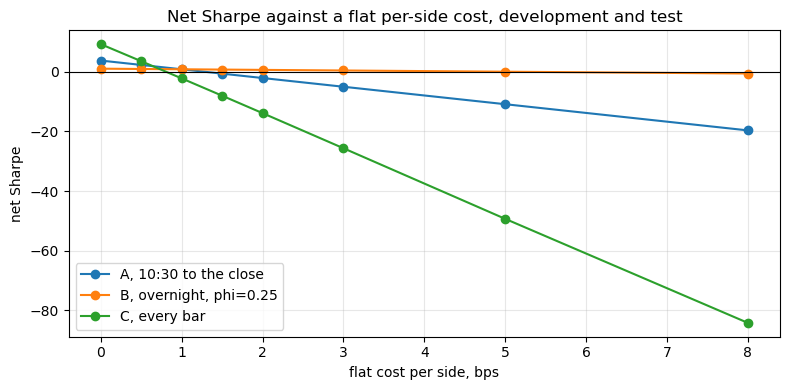

In [28]:
flat = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0]
rows = {}
for key, lab in ((("A", "ew", 1.0), "A, 10:30 to the close"), (("B", "ew", PHI_PRIMARY), "B, overnight, phi=0.25"),
                 (("C", "ew", 1.0), "C, every bar")):
    d = vis(BOOKS[key])
    rows[lab] = {c: sharpe((d["pnl_gross"] - d["traded"] * c / 1e4 - d["borrow"]) / CAP) for c in flat}
cliff = pd.DataFrame(rows).T
cliff.columns = [f"{c:g} bps" for c in flat]
display(cliff.round(2))
be = {lab: float(vis(BOOKS[k])["pnl_gross"].sum() / vis(BOOKS[k])["traded"].sum() * 1e4)
      for k, lab in ((("A", "ew", 1.0), "A"), (("B", "ew", PHI_PRIMARY), "B"), (("C", "ew", 1.0), "C"))}
print("break-even cost per side (bps of traded notional), gross of the flat cost, by book: "
      + ", ".join(f"{k} {v:.2f}" for k, v in be.items()))
med_cost = {y: float(np.median(CV_P[y])) for y in (book_years[0], book_years[-1])}
print("median measured cost per name per side on the primary basis: "
      + ", ".join(f"{y} {v:.2f} bps" for y, v in med_cost.items()))

fig, ax = plt.subplots(figsize=(8, 4))
for lab, r in cliff.iterrows():
    ax.plot(flat, r.to_numpy(), marker="o", label=lab)
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("flat cost per side, bps"); ax.set_ylabel("net Sharpe"); ax.legend()
ax.set_title("Net Sharpe against a flat per-side cost, development and test")
plt.tight_layout(); plt.show()

**What the table says.** Charged a flat cost per side, Book B's net Sharpe fell by about a tenth of a unit for every half
basis point (1.03 at zero, 0.93 at 0.5, 0.83 at 1, 0.62 at 2, 0.42 at 3) and reached zero at about 5 bps (0.02, then −0.59
at 8), against break-evens of 5.47 bps for B, 1.28 for A and 0.81 for C. Book A fell by about 1.5 Sharpe units per half
basis point at first (3.74, 2.28, 0.82 at 1 bp) and Book C by about 5.7 (9.21, 3.51, −2.25 at 1 bp): the slope of the
cliff is the turnover, 0.263 for B, 2.000 for A and 11.170 for C per session. The median measured cost per name per side
was 2.48 bps in 2010 and 2.82 bps in 2025, so B's break-even sat well above the median cost and A's and C's below it.
The charge the primary basis actually levied on B was 3.23 bps per traded dollar in clause (0) of §7.3, borrow included
(well under a basis point of it at 50 bp a year and this turnover), a little above the median name's 2.48 to 2.82: the
traded dollars sit in somewhat costlier names than the median name, not in a heavy tail. The book's net Sharpe at that
charge, 0.453, is close to the flat-cost row at 3 bps (0.42). Every row here trades at the signal's own 15:30 print;
§9.4 re-runs the book half an hour later.

## 8. Placebo, turnover-matched

Each alpha's name-to-signal map is permuted **once per calendar month** and held fixed within it: within a
month, name i receives the signed z-score of a fixed other name, drawn independently for each alpha, at every
formation of the month. A placebo book therefore turns over about as the real one does (the signal a name
carries changes as slowly as the real signal does), which the shuffle-every-session placebo of notebook 17
did not achieve. Each draw runs the whole Book B pipeline: equal-weight blend, neutralization, partial
adjustment at phi = 0.25, the primary costs. The ridge placebo also refits the walk-forward ridge on the
permuted signals. Draws use `np.random.default_rng(0)`. Gross and net Sharpe percentiles are both reported;
the gross one is the comparison the null supports, since a placebo has no reason to pay the real book's
costs identically. Sessions here stop at the end of the test period.

In [29]:
PBK = PAN["B"]
months_B = PBK["date"].to_period("M")
month_groups = {m: np.flatnonzero(months_B == m) for m in months_B.unique()}
month_codes = {m: np.array(sorted(set(np.concatenate([LOAD[int(s)]["codes"] for s in np.unique(PBK["sess"][fi])]))))
               for m, fi in month_groups.items()}

def permute_B(rg):
    Z = PBK["Z"]
    Zp = np.full_like(Z, np.nan)
    for m, fidx in month_groups.items():
        mc = month_codes[m]
        maps = []
        for a in range(NA):
            pm = np.arange(N_ID)
            pm[mc] = mc[rg.permutation(len(mc))]
            maps.append(pm)
        for f in fidx:
            codes = LOAD[int(PBK["sess"][f])]["codes"]
            n = len(codes)
            posmap = np.full(N_ID, -1)
            posmap[codes] = np.arange(n)
            for a in range(NA):
                sp = posmap[maps[a][codes]]
                v = Z[f, a, :n]
                Zp[f, a, :n] = np.where(sp >= 0, v[np.maximum(sp, 0)], np.nan)
    return Zp

def book_stats(df):
    d = vis(df)
    net = d["pnl_gross"] - d["cost_p"] - d["borrow"]
    return sharpe(d["pnl_gross"] / CAP), sharpe(net / CAP), float((d["traded"] / d["gross"].replace(0, np.nan)).mean())

real_ew = book_stats(BOOKS[("B", "ew", PHI_PRIMARY)])
real_ridge = book_stats(BOOKS[("B", "ridge", PHI_PRIMARY)])

t0 = time.time()
ew_null = []
for draw in range(N_EW_DRAWS):
    Zp = permute_B(rng)
    W = neutral_targets("B", blend_ew({"Z": Zp}))
    ew_null.append(book_stats(run_B(W, PHI_PRIMARY)))
ew_null = pd.DataFrame(ew_null, columns=["gross", "net", "turnover"])
print(f"equal-weight placebo: {len(ew_null)} draws in {time.time() - t0:.0f}s")

equal-weight placebo: 40 draws in 37s


ridge placebo: 40 of 40 draws in 43s (budget 1800 s)


book,equal-weight,ridge
draws,40.000,40.000
real gross,1.105,1.168
null gross mean,-0.001,-0.029
null gross sd,0.242,0.270
gross percentile,100.000,100.000
gross z,4.572,4.425
real net,0.453,0.385
null net mean,-1.306,-1.266
net percentile,100.000,100.000
real turnover,0.263,0.308


equal-weight Book B (phi=0.25): gross Sharpe 1.105 sits at the 100.0th percentile of its 40-draw gross null (mean -0.001, sd 0.242); net Sharpe 0.453 at the 100.0th percentile of the net null
turnover per session, real 0.263 against the placebo's mean 0.265: matched
ridge Book B: gross Sharpe 1.168 against its 40-draw gross null (mean -0.029, sd 0.270), 4.4 null standard deviations; on 40 draws that is a z, not a percentile


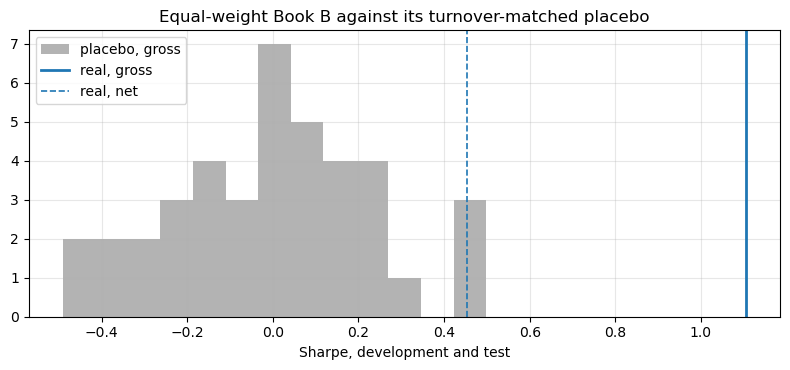

In [30]:
t0 = time.time()
ridge_null, draw = [], 0
while draw < N_RIDGE_DRAWS and (time.time() - t0) < RIDGE_PLACEBO_BUDGET_S:
    Zp = permute_B(rng)
    st_p = formation_stats(PBK, Zp)
    coef_p, _, _ = ridge_walk(st_p, LAG["B"])
    W = neutral_targets("B", ridge_scores(PBK, coef_p, Zr=Zp))
    ridge_null.append(book_stats(run_B(W, PHI_PRIMARY)))
    draw += 1
ridge_null = pd.DataFrame(ridge_null, columns=["gross", "net", "turnover"])
elapsed = time.time() - t0
print(f"ridge placebo: {len(ridge_null)} of {N_RIDGE_DRAWS} draws in {elapsed:.0f}s "
      f"(budget {RIDGE_PLACEBO_BUDGET_S} s{'; the budget cut it short' if len(ridge_null) < N_RIDGE_DRAWS else ''})")
if len(ridge_null) < N_RIDGE_DRAWS:
    DEVIATIONS.append(
        f"Section 8: the ridge placebo completed {len(ridge_null)} of the pre-registered {N_RIDGE_DRAWS} draws before its "
        f"{RIDGE_PLACEBO_BUDGET_S}-second budget ({elapsed:.0f}s elapsed); the shortfall is logged, nothing else was changed. "
        f"With this few draws the ridge percentile has coarse resolution.")

def null_row(name, real, null):
    if len(null) < 2:
        return {"book": name, "draws": len(null)}
    return {"book": name, "draws": len(null),
            "real gross": real[0], "null gross mean": null["gross"].mean(), "null gross sd": null["gross"].std(ddof=1),
            "gross percentile": float((null["gross"] < real[0]).mean() * 100),
            "gross z": (real[0] - null["gross"].mean()) / null["gross"].std(ddof=1),
            "real net": real[1], "null net mean": null["net"].mean(), "net percentile": float((null["net"] < real[1]).mean() * 100),
            "real turnover": real[2], "null turnover": null["turnover"].mean()}
null_tab = pd.DataFrame([null_row("equal-weight", real_ew, ew_null), null_row("ridge", real_ridge, ridge_null)]).set_index("book")
display(null_tab.round(3).T)
print(f"equal-weight Book B (phi={PHI_PRIMARY}): gross Sharpe {real_ew[0]:.3f} sits at the "
      f"{null_tab.loc['equal-weight', 'gross percentile']:.1f}th percentile of its {len(ew_null)}-draw gross null "
      f"(mean {ew_null['gross'].mean():.3f}, sd {ew_null['gross'].std(ddof=1):.3f}); net Sharpe {real_ew[1]:.3f} at the "
      f"{null_tab.loc['equal-weight', 'net percentile']:.1f}th percentile of the net null")
print(f"turnover per session, real {real_ew[2]:.3f} against the placebo's mean {ew_null['turnover'].mean():.3f}: "
      f"{'matched' if abs(real_ew[2] - ew_null['turnover'].mean()) < 0.5 * real_ew[2] else 'not matched'}")
if len(ridge_null) > 1:
    print(f"ridge Book B: gross Sharpe {real_ridge[0]:.3f} against its {len(ridge_null)}-draw gross null "
          f"(mean {ridge_null['gross'].mean():.3f}, sd {ridge_null['gross'].std(ddof=1):.3f}), "
          f"{null_tab.loc['ridge', 'gross z']:.1f} null standard deviations; on {len(ridge_null)} draws that is a z, not a percentile")

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(ew_null["gross"], bins=max(6, len(ew_null) // 3), color="0.7", label="placebo, gross")
ax.axvline(real_ew[0], color="tab:blue", lw=2, label="real, gross")
ax.axvline(real_ew[1], color="tab:blue", lw=1.2, ls="--", label="real, net")
ax.set_xlabel("Sharpe, development and test"); ax.legend()
ax.set_title("Equal-weight Book B against its turnover-matched placebo")
plt.tight_layout(); plt.show()

### 8.1 Why the placebo's net Sharpe is lower: cost per dollar, or risk?

The net comparison above is not one the null supports, but its gap invites an explanation, and the tempting one (the
placebo pays more per unit of turnover) is a claim about costs that can be read off the books directly. The cell below
regenerates the equal-weight placebo draws (a fresh generator with the same seed reproduces the draws above, since nothing
else consumed the notebook's generator before them; the cell checks that the gross Sharpe ratios agree) and puts the
real book's cost per traded dollar, dollars of cost per session, turnover and P&L volatility beside the placebo's.

In [31]:
def cost_profile(d):
    d = vis(d)
    sd = d["pnl_gross"].std(ddof=0)
    return {"cost per traded dollar (bps)": float(d["cost_p"].sum() / d["traded"].sum() * 1e4),
            "cost per session ($)": float(d["cost_p"].mean()),
            "turnover / session": float((d["traded"] / d["gross"].replace(0, np.nan)).mean()),
            "gross Sharpe": sharpe(d["pnl_gross"] / CAP),
            "net Sharpe": sharpe((d["pnl_gross"] - d["cost_p"] - d["borrow"]) / CAP),
            "daily gross P&L s.d. ($)": float(sd),
            "annual cost over annual P&L s.d.": float(d["cost_p"].mean() * ANN / (sd * np.sqrt(ANN)))}

rg_chk = np.random.default_rng(0)
prof_rows, gross_chk = [], []
for draw in range(N_EW_DRAWS):
    dfp = run_B(neutral_targets("B", blend_ew({"Z": permute_B(rg_chk)})), PHI_PRIMARY)
    prof_rows.append(cost_profile(dfp)); gross_chk.append(prof_rows[-1]["gross Sharpe"])
prof_null = pd.DataFrame(prof_rows)
prof_real = cost_profile(BOOKS[("B", "ew", PHI_PRIMARY)])
prof_tab = pd.DataFrame({"real book": pd.Series(prof_real), "placebo mean": prof_null.mean(),
                         "placebo min": prof_null.min(), "placebo max": prof_null.max()})
display(prof_tab.round(3))
print(f"the regenerated draws reproduce the placebo above: {np.allclose(gross_chk, ew_null['gross'].to_numpy())}")
print(f"cost per traded dollar: real {prof_real['cost per traded dollar (bps)']:.2f} bps against the placebo's mean "
      f"{prof_null['cost per traded dollar (bps)'].mean():.2f}; cost per session ${prof_real['cost per session ($)']:.0f} against "
      f"${prof_null['cost per session ($)'].mean():.0f}; daily gross P&L s.d. ${prof_real['daily gross P&L s.d. ($)']:,.0f} against "
      f"${prof_null['daily gross P&L s.d. ($)'].mean():,.0f}; annual cost over annual P&L s.d. "
      f"{prof_real['annual cost over annual P&L s.d.']:.3f} against {prof_null['annual cost over annual P&L s.d.'].mean():.3f}")

,real book,placebo mean,placebo min,placebo max
cost per traded dollar (bps),2.848,2.726,2.725,2.728
cost per session ($),74.770,72.381,72.223,72.554
turnover / session,0.263,0.265,0.265,0.266
gross Sharpe,1.105,-0.001,-0.491,0.498
net Sharpe,0.453,-1.306,-1.798,-0.817
daily gross P&L s.d. ($),2062.443,1001.490,967.539,1034.707
annual cost over annual P&L s.d.,0.576,1.148,1.110,1.188


the regenerated draws reproduce the placebo above: True
cost per traded dollar: real 2.85 bps against the placebo's mean 2.73; cost per session $75 against $72; daily gross P&L s.d. $2,062 against $1,001; annual cost over annual P&L s.d. 0.576 against 1.148


**What the tables say.** Both real books sat above their nulls before costs: the equal-weight gross Sharpe of 1.105 was
above every one of 40 draws (null mean −0.001, s.d. 0.242, z = 4.572) and the ridge book's 1.168 was 4.425 null standard
deviations above its own (mean −0.029, s.d. 0.270). With 40 draws a 100.0th percentile means only that the real book
beat all of them, so the z is the better summary (it assumes a roughly normal null, which 40 draws cannot test). The
null gross means sit near zero, so the placebo pipeline (neutralization, partial adjustment, the blend) did not
manufacture a Sharpe on its own. Turnover was matched for the equal-weight book (0.263 against 0.265) but not exactly
for the ridge (0.308 against 0.266). The net comparison is not one the null supports and is reported for completeness:
the placebo's net Sharpe averaged −1.306 on a gross of −0.001, the real book's 0.453 on 1.105, and every placebo draw's net
Sharpe sat below the real book's. That is the 100.0th net percentile, and it says nothing about the alphas. §8.1 shows
where the gap does not come from: the placebo paid the same cost per traded dollar (2.73 against 2.85 bps, slightly less
than the real book) and the same dollars per session ($72 against $75). Its net Sharpe is lower because a permuted signal
spreads weight over names with half the real book's P&L volatility (a daily gross P&L standard deviation of $1,001 against
$2,062), so the same cost is twice the drag on the Sharpe ratio (an annual cost of 1.148 annual P&L standard deviations
against 0.576). The placebo is matched on turnover, not on risk, and the real signals concentrate weight in the more
volatile names. The gross comparison is the one the null supports; reading it as a z-score with the risk matched would
take a volatility-scaled placebo, which this notebook did not build.

## 9. Decision, and the hold-out

Both pre-registered rules, applied verbatim, and then the hold-out, displayed in this run for the third time (the
two earlier runs showed it too, and Amendment 1 and the data-sanity rules were written after that display; Deviation 17).
Nothing above in this run read it: the ridge refits and every table stopped at the end of the test period.

**Rule one.** The intraday desk **works** if Book B's equal-weight, phi = 0.25, net-of-primary-cost Sharpe on
the test period is positive with t > 2 and the hold-out has the same sign. **Rule two.** Intraday alphas
**add to the daily ones** if the eight-alpha equal-weight blend on Book B has a higher development IC than the
blend of alphas 7 and 8 alone by more than twice the difference's standard error, and the same sign of
difference in the test period; reported, not decided, if only one holds.

In [32]:
key = ("B", "ew", PHI_PRIMARY)
dfull = BOOKS[key]
net_full = dfull["pnl_gross"] - dfull["cost_p"] - dfull["borrow"]
seg = lambda lo, hi: net_full[(net_full.index >= lo) & (net_full.index <= hi)]
s_test = sharpe(seg(TEST_START, TEST_END) / CAP)
n_test = len(seg(TEST_START, TEST_END))
t_test = s_test * np.sqrt(n_test / ANN)
s_hold = sharpe(seg(HOLD_START, pd.Timestamp("2100-01-01")) / CAP)
n_hold = len(seg(HOLD_START, pd.Timestamp("2100-01-01")))
works = bool(np.isfinite(s_test) and s_test > 0 and t_test > 2 and np.sign(s_hold) == np.sign(s_test))
print(f"RULE ONE: the intraday desk {'works' if works else 'does not work'} by the pre-registered rule. Book B equal-weight, "
      f"phi={PHI_PRIMARY}, net of the primary costs: test-period Sharpe {s_test:.3f} (t = {t_test:.2f} on {n_test} sessions, "
      f"against the threshold of 2), hold-out Sharpe {s_hold:.3f} on {n_hold} sessions, "
      f"{'the same sign as' if np.sign(s_hold) == np.sign(s_test) else 'the opposite sign to'} the test period.")

dev_ok = ADD["dev"]["diff"] > 2 * ADD["dev"]["se"]
test_ok = bool(np.sign(ADD["test"]["diff"]) == np.sign(ADD["dev"]["diff"]))
adds = dev_ok and test_ok
verdict2 = "add to the daily ones" if adds else ("do not add to the daily ones" if not (dev_ok or test_ok)
                                                 else "are reported only (exactly one of the two conditions holds)")
print(f"RULE TWO: intraday alphas {verdict2}. Development IC difference {ADD['dev']['diff']:+.4f} against twice its s.e. "
      f"{2 * ADD['dev']['se']:.4f} ({'exceeds' if dev_ok else 'does not exceed'} it); test-period difference "
      f"{ADD['test']['diff']:+.4f} ({'same' if test_ok else 'opposite'} sign).")

RULE ONE: the intraday desk does not work by the pre-registered rule. Book B equal-weight, phi=0.25, net of the primary costs: test-period Sharpe 0.176 (t = 0.35 on 1008 sessions, against the threshold of 2), hold-out Sharpe 0.809 on 655 sessions, the same sign as the test period.
RULE TWO: intraday alphas add to the daily ones. Development IC difference +0.0167 against twice its s.e. 0.0092 (exceeds it); test-period difference +0.0127 (same sign).


### 9.0 Hold-out information coefficients

Sections 4 and 5 stopped at the test period. The same formation-level ICs, on the same probe formations, for the
hold-out, displayed here (this run's first display of it, after two earlier displays): every alpha on every book, the blends, and rule two's paired
difference, so that the decision rules can be read against the period they did not use.

In [33]:
hold_rows = []
for b in "ABC":
    for j, a in enumerate(ALPHAS):
        g = ic_stats(b, j, "hold")
        hold_rows.append({"book": b, "series": a, "hold_ic": g["ic"], "hold_se": g["se"], "hold_t": g["t"], "n": g["n"]})
    for bl in ("ew", "ridge") + (("ew78",) if b == "B" else ()):
        g = ic_stats(b, 0, "hold", ic_arr=BLEND_IC[(b, bl)][0], cnt_arr=BLEND_IC[(b, bl)][1])
        hold_rows.append({"book": b, "series": f"blend {bl}", "hold_ic": g["ic"], "hold_se": g["se"], "hold_t": g["t"], "n": g["n"]})
hold_ic_tab = pd.DataFrame(hold_rows).set_index(["book", "series"])
display(hold_ic_tab.round(4))
m_h = PAN["B"]["probe"] & (PAN["B"]["period"] == "hold") & np.isfinite(diff)
a_h = diff[m_h]
ADD["hold"] = dict(diff=a_h.mean(), se=a_h.std(ddof=1) / np.sqrt(len(a_h)), n=len(a_h))
ADD["hold"]["t"] = ADD["hold"]["diff"] / ADD["hold"]["se"]
print(f"Book B, eight-alpha equal-weight IC minus the IC of alphas 7 and 8 alone, hold-out: difference {ADD['hold']['diff']:+.4f}, "
      f"s.e. {ADD['hold']['se']:.4f}, ratio {ADD['hold']['t']:+.2f}, {ADD['hold']['n']} formations")
pairing_hold = pairing_row("hold")
print(f"hold-out pairing: s.e. of the eight-alpha blend {pairing_hold['s.e. eight-alpha blend']:.4f}, of the controls blend "
      f"{pairing_hold['s.e. controls blend']:.4f}, of the paired difference {pairing_hold['s.e. paired difference']:.4f}; "
      f"correlation of the two blends' formation ICs {pairing_hold['correlation of formation ICs']:.3f}")
# leave-one-out: which alpha carries the intraday addition in each period (eight-alpha equal-weight blend without alpha j)
loo = {}
for j, a in enumerate(ALPHAS[:6]):
    keep_j = [i for i in range(NA) if i != j]
    sc_j = blend_ew(PAN["B"], cols=keep_j)
    ic_j = row_corr(sc_j, PAN["B"]["Y"])[0]
    d_j = BLEND_IC[("B", "ew")][0] - ic_j
    row = {}
    for p in ("dev", "test", "hold"):
        m_ = PAN["B"]["probe"] & (PAN["B"]["period"] == p) & np.isfinite(d_j)
        x_ = d_j[m_]
        row[f"{p}: IC gain from alpha"] = x_.mean(); row[f"{p}_t"] = x_.mean() / (x_.std(ddof=1) / np.sqrt(len(x_)))
    loo[a] = row
print("what each intraday alpha adds to the eight-alpha equal-weight blend's IC (blend minus blend without it), Book B:")
display(pd.DataFrame(loo).T.round(4))

hold_ic  hold_se  hold_t     n
book series                                     
A    perio        -0.0105   0.0067 -1.5613   131
     irev30        0.0235   0.0126  1.8587   131
     ovn           0.0018   0.0063  0.2793   131
     iopen         0.0126   0.0129  0.9715   131
     ivol_abn     -0.0067   0.0055 -1.2052   131
     irange        0.0095   0.0059  1.5999   131
     rev5          0.0006   0.0080  0.0717   131
     mom12_1      -0.0001   0.0074 -0.0152   131
     blend ew      0.0123   0.0098  1.2577   131
     blend ridge   0.0180   0.0123  1.4709   131
B    perio        -0.0169   0.0081 -2.0806   131
     irev30        0.0067   0.0122  0.5500   131
     ovn          -0.0006   0.0062 -0.1053   131
     iopen        -0.0046   0.0110 -0.4195   131
     ivol_abn     -0.0044   0.0060 -0.7336   131
     irange       -0.0002   0.0054 -0.0350   131
     rev5          0.0105   0.0074  1.4314   131
     mom12_1       0.0160   0.0069  2.3273   131
     blend ew      0.0033   0.0088  0.3811   131
     blend ridge   0.0058   0.0109  0.5311   131
     blend ew78    0.0184   0.0073  2.5232   131
C    perio         0.0017   0.0019  0.8790  1572
     irev30        0.0090   0.0038  2.3915  1572
     ovn           0.0009   0.0018  0.4922  1572
     iopen         0.0075   0.0038  1.9794  1572
     ivol_abn     -0.0037   0.0017 -2.2375  1572
     irange        0.0037   0.0018  2.1247  1572
     rev5          0.0010   0.0022  0.4492  1572
     mom12_1      -0.0001   0.0020 -0.0639  1572
     blend ew      0.0074   0.0028  2.6740  1572
     blend ridge   0.0103   0.0037  2.7624  1572

Book B, eight-alpha equal-weight IC minus the IC of alphas 7 and 8 alone, hold-out: difference -0.0151, s.e. 0.0082, ratio -1.83, 131 formations
hold-out pairing: s.e. of the eight-alpha blend 0.0088, of the controls blend 0.0073, of the paired difference 0.0082; correlation of the two blends' formation ICs 0.488


what each intraday alpha adds to the eight-alpha equal-weight blend's IC (blend minus blend without it), Book B:


,dev: IC gain from alpha,dev_t,test: IC gain from alpha,test_t,hold: IC gain from alpha,hold_t
perio,-0.0009,-0.5787,-0.0003,-0.1325,-0.0063,-2.0379
irev30,0.0087,3.5880,0.0001,0.0183,0.0027,0.5689
ovn,-0.0002,-0.1837,-0.0005,-0.2347,-0.0008,-0.3089
iopen,0.0035,1.3281,0.0094,2.1364,-0.0023,-0.5193
ivol_abn,-0.0017,-1.6409,0.0017,0.9635,-0.0011,-0.4984
irange,0.0032,3.1765,-0.0002,-0.1038,-0.0005,-0.2498


**What the tables say.** The hold-out ICs do not support the intraday alphas. On Book B's window the eight-alpha
equal-weight blend's IC was 0.0033 (s.e. 0.0088, t = 0.3811) on 131 probe formations, against 0.0184 (s.e. 0.0073,
t = 2.5232) for the blend of the two daily controls alone, so rule two's paired difference was −0.0151 (s.e. 0.0082,
ratio −1.83; the paired s.e. was again about the eight-alpha blend's own, 0.0088, and above the controls blend's, 0.0073, the
two blends' formation ICs correlating at 0.488): the sign that held in development (+0.0167) and in the test period (+0.0127) reversed, and the hold-out
difference sits just short of two standard errors from zero (the pre-amendment run's was `−1.42`). Among the single
alphas on Book B the hold-out ICs were `perio` −0.0169 (t = −2.0806), `mom12_1` +0.0160 (t = 2.3273), `rev5` 0.0105
(t = 1.4314) and, within one standard error of zero, `irev30` 0.0067, `ovn` −0.0006, `iopen` −0.0046, `ivol_abn` −0.0044
and `irange` −0.0002, so the two alphas above two standard errors are one intraday alpha pointing the wrong way and one
daily control. The leave-one-out table shows that the addition rule two credits was carried by a different alpha in
each period: `irev30` in development (its removal cost the blend 0.0087 of IC, t = 3.5880, with `irange` at 0.0032,
t = 3.1765) and `iopen` in the test period (0.0094, t = 2.1364), while `irev30` added 0.0001 in the test period and
`iopen` 0.0035 in development (t = 1.3281, under two). In the hold-out `irev30` was the only intraday alpha with a
positive gain (0.0027, t = 0.5689) and removing `perio` helped by 0.0063 (t = −2.0379). On Book A the eight-alpha
blend's hold-out IC was 0.0123 (t = 1.2577) and on Book C 0.0074 (t = 2.6740, on 1,572 bar formations whose standard
errors are the least reliable); Book C's `irev30` kept a positive hold-out IC (0.0090, t = 2.3915).

### 9.1 The hold-out, all books

The full-span versions of the §7 tables, with the hold-out column. The hold-out is 2023 to the end of the data,
the window of notebooks 11 and 17, and is displayed here, in this run's only display of it (the third across the
study; Deviation 17).

gross Sharpe  net Sharpe  net Sharpe, day-lake costs   s.e.  \
book blend phi                                                                 
B    ew    0.25         1.162       0.516                       0.586  0.253   
           1.00         2.301      -0.456                      -0.122  0.253   
           0.50         1.698       0.380                       0.533  0.253   
           0.10         0.931       0.647                       0.673  0.253   
     ridge 0.25         1.333       0.568                       0.662  0.253   
           1.00         2.258      -1.001                      -0.562  0.253   
           0.50         1.944       0.244                       0.467  0.253   
           0.10         0.646       0.345                       0.376  0.253   
     ew78  0.25         0.702       0.152                       0.207  0.253   
A    ew    1.00         3.376      -4.775                         NaN  0.253   
     ridge 1.00         2.814      -4.168                         NaN  0.253   
C    ew    1.00         8.594     -24.952                         NaN  0.253   
     ridge 1.00         9.350     -24.928                         NaN  0.253   

                 sessions  net Sharpe dev  net Sharpe test  \
book blend phi                                               
B    ew    0.25      3926           0.651            0.176   
           1.00      3926           0.077           -0.816   
           0.50      3926           0.723            0.085   
           0.10      3926           0.634            0.322   
     ridge 0.25      3926           0.553            0.162   
           1.00      3926          -0.311           -1.540   
           0.50      3926           0.773           -0.353   
           0.10      3926           0.095           -0.073   
     ew78  0.25      3926           0.214           -0.373   
A    ew    1.00      3927          -5.401           -3.587   
     ridge 1.00      3927          -4.888           -2.926   
C    ew    1.00      3927         -29.697          -18.740   
     ridge 1.00      3927         -27.646          -19.379   

                 net Sharpe hold-out  net P&L dev ($k)  net P&L test ($k)  \
book blend phi                                                              
B    ew    0.25                0.809           163.275             29.247   
           1.00               -1.307            17.468           -124.076   
           0.50                0.036           170.868             13.641   
           0.10                1.273           170.745             53.504   
     ridge 0.25                1.357           120.922             24.457   
           1.00               -1.981           -67.359           -214.576   
           0.50               -0.045           165.507            -50.768   
           0.10                1.719            21.923            -12.171   
     ew78  0.25                0.879            50.772            -54.224   
A    ew    1.00               -5.551          -721.021           -310.549   
     ridge 1.00               -5.336          -664.650           -299.327   
C    ew    1.00              -29.588         -5152.618          -2421.293   
     ridge 1.00              -33.971         -7051.508          -3419.552   

                 net P&L hold-out ($k)  turnover / session  break-even bps  
book blend phi                                                              
B    ew    0.25                 73.989               0.263           5.813  
           1.00               -106.491               1.119           2.450  
           0.50                  3.155               0.547           3.906  
           0.10                125.785               0.102          12.561  
     ridge 0.25                120.287               0.304           5.602  
           1.00               -164.305               1.345           2.052  
           0.50                 -3.931               0.697           3.464  
           0.10                164.3

Book B, ew, phi=0.25, by year including the hold-out:


,gross Sharpe,net Sharpe,net P&L ($k)
date,,,
2010,3.215,2.326,54.038
2011,2.191,1.500,43.863
2012,0.261,-0.491,-13.580
2013,2.334,1.552,38.353
2014,1.649,0.850,22.696
2015,2.293,1.580,46.859
2016,-0.599,-1.229,-40.335
2017,1.078,0.259,6.977
2018,0.921,0.157,4.404


Book B, ew, phi=0.25, by five-year block including the hold-out:


,sessions,gross Sharpe,net Sharpe,s.e.
2010-2014,1257,1.874,1.100,0.448
2015-2019,1258,0.730,0.018,0.448
2020-2024,1258,1.070,0.524,0.448
2025-2025,153,1.127,0.497,1.283


...

,sessions,gross Sharpe,net Sharpe,s.e.
2010-2014,1258,4.652,-5.275,0.448
2015-2019,1258,3.579,-5.526,0.448
2020-2024,1258,2.655,-4.044,0.448
2025-2025,153,2.710,-5.900,1.283


Book C, ew, by year including the hold-out:


,gross Sharpe,net Sharpe,net P&L ($k)
date,,,
2010,15.040,-24.335,-483.832
2011,16.320,-22.799,-440.231
2012,10.679,-31.781,-586.277
2013,12.658,-34.445,-532.390
2014,10.381,-34.725,-637.347
2015,9.324,-31.850,-626.423
2016,10.751,-25.622,-543.245
2017,9.529,-38.431,-676.817
2018,10.157,-35.145,-626.056


Book C, ew, by five-year block including the hold-out:


,sessions,gross Sharpe,net Sharpe,s.e.
2010-2014,1258,12.822,-28.377,0.448
2015-2019,1258,9.060,-31.928,0.448
2020-2024,1258,6.788,-20.269,0.448
2025-2025,153,4.721,-27.854,1.283


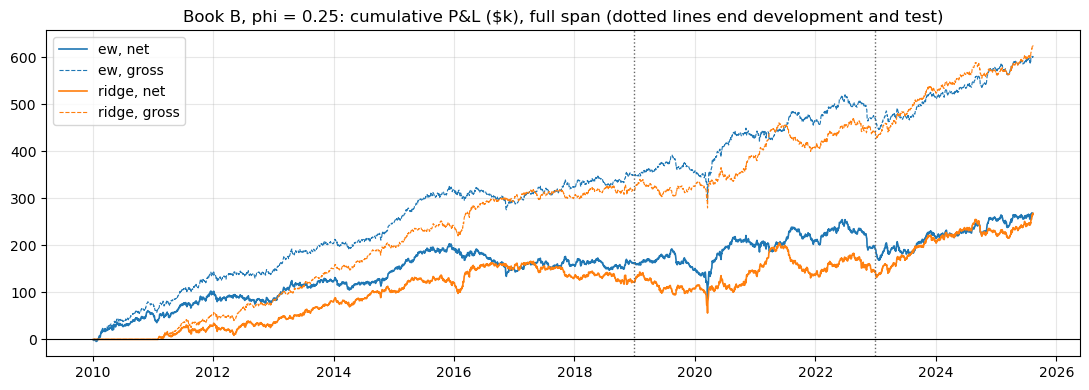

In [34]:
full_summary = pd.DataFrame([summarize(k, df=BOOKS[k], with_hold=True) for k in sum_keys]).set_index(["book", "blend", "phi"])
display(full_summary[["gross Sharpe", "net Sharpe", "net Sharpe, day-lake costs", "s.e.", "sessions",
                      "net Sharpe dev", "net Sharpe test", "net Sharpe hold-out", "net P&L dev ($k)", "net P&L test ($k)",
                      "net P&L hold-out ($k)", "turnover / session", "break-even bps"]].round(3))
for k in prim_keys:
    print(f"Book B, {k[1]}, phi={k[2]}, by year including the hold-out:")
    display(by_year_table(k, upto=LAST_SESSION + pd.Timedelta(days=5)).round(3))
    print(f"Book B, {k[1]}, phi={k[2]}, by five-year block including the hold-out:")
    display(block_table(k, upto=LAST_SESSION + pd.Timedelta(days=5)).round(3))
    print(f"five-clause scorecard with the hold-out, Book B, {k[1]}, phi={k[2]}:")
    display(scorecard(k, upto=LAST_SESSION + pd.Timedelta(days=5), hold=True))
for k in [("A", "ew", 1.0), ("C", "ew", 1.0)]:
    print(f"Book {k[0]}, {k[1]}, by year including the hold-out:")
    display(by_year_table(k, upto=LAST_SESSION + pd.Timedelta(days=5)).round(3))
    print(f"Book {k[0]}, {k[1]}, by five-year block including the hold-out:")
    display(block_table(k, upto=LAST_SESSION + pd.Timedelta(days=5)).round(3))

fig, ax = plt.subplots(figsize=(11, 4))
for k, col in zip(prim_keys, ("tab:blue", "tab:orange")):
    d = BOOKS[k]
    ax.plot(d.index, (d["pnl_gross"] - d["cost_p"] - d["borrow"]).cumsum() / 1e3, color=col, lw=1.2, label=f"{k[1]}, net")
    ax.plot(d.index, d["pnl_gross"].cumsum() / 1e3, color=col, lw=0.8, ls="--", label=f"{k[1]}, gross")
ax.axvline(DEV_END, color="0.4", ls=":", lw=1); ax.axvline(TEST_END, color="0.4", ls=":", lw=1)
ax.axhline(0, color="k", lw=0.8); ax.legend()
ax.set_title(f"Book B, phi = {PHI_PRIMARY}: cumulative P&L ($k), full span (dotted lines end development and test)")
plt.tight_layout(); plt.show()

**What the tables say.** Over the full span Book B's equal-weight, phi = 0.25 book had a gross Sharpe of 1.162 and a net
of 0.516 on the primary basis (0.586 on the day-lake basis, s.e. 0.253). Its hold-out net Sharpe was 0.809 (net P&L
+73.989 thousand dollars), higher than the test figure (0.176) and above the development one (0.651), and by year 0.746
in 2023, 1.109 in 2024 and 0.497 in 2025. That is the sign rule one asked for, and it is not evidence of an edge in the
intraday alphas: the hold-out is 655 sessions long, clause (a) with the hold-out included was t = 1.87 over 786 blocks,
the profit per bet was 5.74 bps gross against 3.23 bps of cost (1.78x, against 1.68x through the test period), and the
book of the two daily controls alone earned 0.879 in the hold-out, above the eight-alpha book's 0.809, with the
eight-alpha blend's own hold-out IC at 0.0033 (§9.0). The ridge book's hold-out (1.357) was higher still but rested on
2023 (1.891) and 2025 (1.770), with 2024 lower at 0.479. The lowest-turnover books did best in the hold-out (phi = 0.10:
1.273 equal-weight, 1.719 ridge) and the fastest worst (phi = 1.00: −1.307 and −1.981), the order of the cost cliff.
Books A and C lost in every period (hold-out −5.551 and −29.588), in every calendar year (the best years were 2011 for
A at −0.492 and 2020 for C at −11.606) and in every five-year block (A −5.275, −5.526, −4.044; C −28.377, −31.928,
−20.269).

### 9.2 Like-for-like against notebooks 17 and 11

Reported, not decided. Notebook 17's equal-weight book scored a net Sharpe of 0.596 at notebook 14's measured
day-lake costs, with a standard error of 0.23 (its span is 2006 to 2025); notebook 11's pairs book scored 0.49 with
0.26 on the same footing. The comparison here is Book B's equal-weight, phi = 0.25 book on the **secondary cost
basis only**, over its own span (which starts in 2010, so the two spans differ and the difference is not a
clean like-for-like in time), with the difference divided by the combined standard error.

In [35]:
net_day = dfull["pnl_gross"] - dfull["cost_d"] - dfull["borrow"]
s_day, se_day = sharpe(net_day / CAP), se_sharpe(len(net_day))
print(f"Book B equal-weight, phi={PHI_PRIMARY}, secondary basis (day-lake measured costs, {BORROW_BPS:g} bp borrow), "
      f"{len(net_day):,} sessions {net_day.index.min().date()} -> {net_day.index.max().date()}: Sharpe {s_day:.3f}, s.e. {se_day:.3f}")
for name, ref, ref_se in (("notebook 17's equal-weight book", NB17_SHARPE, NB17_SE), ("notebook 11", NB11_SHARPE, NB11_SE)):
    comb = float(np.sqrt(se_day ** 2 + ref_se ** 2))
    print(f"  against {name} (Sharpe {ref:.3f}, s.e. {ref_se:.2f}): difference {s_day - ref:+.3f}, combined s.e. {comb:.3f}, "
          f"{abs(s_day - ref) / comb:.2f} combined standard errors")
print(f"for reference, the same book on the primary (Roll) basis: Sharpe {sharpe(net_full / CAP):.3f}")

Book B equal-weight, phi=0.25, secondary basis (day-lake measured costs, 50 bp borrow), 3,926 sessions 2010-01-05 -> 2025-08-13: Sharpe 0.586, s.e. 0.253
  against notebook 17's equal-weight book (Sharpe 0.596, s.e. 0.23): difference -0.010, combined s.e. 0.342, 0.03 combined standard errors
  against notebook 11 (Sharpe 0.490, s.e. 0.26): difference +0.096, combined s.e. 0.363, 0.26 combined standard errors
for reference, the same book on the primary (Roll) basis: Sharpe 0.516


**What the table says.** On the secondary basis Book B's full-span Sharpe of 0.586 (s.e. 0.253) sat 0.010 below notebook
17's 0.596 and 0.096 above notebook 11's 0.490, that is 0.03 and 0.26 combined standard errors (combined s.e. 0.342 and
0.363). The three are not distinguishable, and the comparison could not have distinguished a difference of several
tenths: two combined standard errors span about 0.7. It is also not a like-for-like in construction: notebook 17's book
blended eleven daily alphas, Book B blends eight (six intraday), and the spans differ. Inside this notebook, on the
same span and basis, the eight-alpha book's 0.586 compares with 0.207 for the two daily controls alone (§9.1); the two
share their controls, so that difference is tested only by rule two's paired IC, not here. The same book on the primary
basis had 0.516, within a third of a standard error of the secondary figure, so here the two bases tell the same story.

### 9.3 Rule two by year and by block

Rule two's development difference is an average over nine years, and a decision rule read on one pooled number cannot
say whether it is a steady addition or a few years' worth. The cell below splits the same paired IC differences (Book B,
probe formations, eight-alpha equal-weight blend minus the blend of alphas 7 and 8) by calendar year and by block, re-reads
the development ratio with the first two development years dropped, and prints the ICs of the six-intraday blend and of the
controls blend on their own, since the difference is one minus the other. This is a post-hoc reading of a verdict that was
fixed as pre-registered (Deviation 19); it does not replace the verdict.

In [36]:
PB = PAN["B"]
yr_B = np.asarray(PB["date"].year)
pr_ok = PB["probe"] & np.isfinite(diff)

def paired_stats(mask):
    a = diff[mask & pr_ok]
    if len(a) < 2:
        return {"formations": len(a), "difference": np.nan, "s.e.": np.nan, "ratio": np.nan}
    se = a.std(ddof=1) / np.sqrt(len(a))
    return {"formations": len(a), "difference": a.mean(), "s.e.": se, "ratio": a.mean() / se}

yrows = []
for y in sorted(np.unique(yr_B[pr_ok])):
    r = paired_stats(yr_B == y)
    r.update(year=int(y), period=str(PB["period"][yr_B == y][0]))
    yrows.append(r)
by_year_diff = pd.DataFrame(yrows).set_index("year")
display(by_year_diff.round(4))
print(f"largest year-by-year ratios: {by_year_diff['ratio'].round(2).sort_values().head(2).to_dict()} (lowest), "
      f"{by_year_diff['ratio'].round(2).sort_values().tail(2).to_dict()} (highest)")

BLOCKS_R2 = [(2010, 2012), (2013, 2015), (2016, 2018), (2019, 2022), (2023, 2025)]
brows = []
for lo, hi in BLOCKS_R2:
    r = paired_stats((yr_B >= lo) & (yr_B <= hi))
    r["block"] = f"{lo}-{hi}"
    brows.append(r)
block_diff = pd.DataFrame(brows).set_index("block")
display(block_diff.round(4))

dev_m = PB["period"] == "dev"
rows = []
for label, mask in (("development, as pre-registered (2010-2018)", dev_m),
                    ("development from 2012", dev_m & (yr_B >= 2012)),
                    ("development from 2014", dev_m & (yr_B >= 2014))):
    r = paired_stats(mask)
    r["reading"] = label
    r["exceeds twice its s.e."] = bool(r["difference"] > 2 * r["s.e."])
    rows.append(r)
dev_readings = pd.DataFrame(rows).set_index("reading")
display(dev_readings.round(4))

BL_SIX = blend_ew(PB, cols=list(range(6)))
IC_SIX = row_corr(BL_SIX, PB["Y"])
rows = []
for name, (ica, cnta) in (("six intraday alphas, equal-weight", IC_SIX), ("two daily controls, equal-weight", BLEND_IC[("B", "ew78")]),
                          ("all eight, equal-weight", BLEND_IC[("B", "ew")])):
    for per in ("dev", "test", "hold"):
        g = ic_stats("B", 0, per, ic_arr=ica, cnt_arr=cnta)
        rows.append({"blend": name, "period": per, "IC": g["ic"], "s.e.": g["se"], "t": g["t"]})
own_ic = pd.DataFrame(rows).set_index(["blend", "period"])
display(own_ic.round(4))

,formations,difference,s.e.,ratio,period
year,,,,,
2010,51,0.0334,0.0122,2.7343,dev
2011,50,0.0398,0.0144,2.7663,dev
2012,50,0.0140,0.0149,0.9428,dev
2013,51,0.0107,0.0139,0.7668,dev
2014,50,0.0135,0.0120,1.1299,dev
2015,50,0.0237,0.0153,1.5479,dev
2016,51,0.0178,0.0143,1.2476,dev
2017,50,-0.0076,0.0132,-0.5806,dev
2018,50,0.0046,0.0133,0.3456,dev


largest year-by-year ratios: {2024: -2.84, 2017: -0.58} (lowest), {2010: 2.73, 2011: 2.77} (highest)


,formations,difference,s.e.,ratio
block,,,,
2010-2012,151,0.0291,0.0080,3.6395
2013-2015,151,0.0159,0.0079,2.0094
2016-2018,151,0.0050,0.0078,0.6379
2019-2022,202,0.0127,0.0072,1.7727
2023-2025,131,-0.0151,0.0082,-1.8293


,formations,difference,s.e.,ratio,exceeds twice its s.e.
reading,,,,,
"development, as pre-registered (2010-2018)",453,0.0167,0.0046,3.6357,True
development from 2012,352,0.0110,0.0052,2.1011,True
development from 2014,251,0.0104,0.0061,1.7098,False


IC    s.e.       t
blend                             period                        
six intraday alphas, equal-weight dev     0.0200  0.0050  4.0070
                                  test    0.0141  0.0079  1.7811
                                  hold   -0.0079  0.0088 -0.8961
two daily controls, equal-weight  dev     0.0015  0.0036  0.4175
                                  test    0.0005  0.0058  0.0782
                                  hold    0.0184  0.0073  2.5232
all eight, equal-weight           dev     0.0182  0.0047  3.8568
                                  test    0.0131  0.0075  1.7481
                                  hold    0.0033  0.0088  0.3811

**What the tables say.** Rule two's development difference is a 2010 and 2011 result. The paired difference was +0.0334 in
2010 (ratio 2.73) and +0.0398 in 2011 (2.77); in each of the seven years from 2012 to 2018 the ratio was at most 1.55
(2015), and the lowest was −0.58 (2017), and the differences ran from −0.0076 to +0.0237. By block the difference was +0.0291
(ratio 3.64) in 2010-2012, +0.0159 (2.01) in 2013-2015, +0.0050 (0.64) in 2016-2018, +0.0127 (1.77) in 2019-2022 and −0.0151
(−1.83) in 2023-2025, of which 2024 alone was −0.0374 (−2.84); 2020 was the test period's one strong year (+0.0294, ratio
1.97). On the other plausible readings of "development" the rule is close: from 2012 the difference is +0.0110 (s.e. 0.0052,
ratio 2.10), which just passes, and from 2014 it is +0.0104 (s.e. 0.0061, ratio 1.71), which does not. The pre-registered
verdict stands as written, because the rule named the whole development period. What it means is narrower than "the
intraday alphas add to the daily ones": the controls blend had no IC on this window in development (0.0015, t = 0.4175) or
in the test period (0.0005, t = 0.0782), so the difference is essentially the six-intraday blend's own IC (0.0200, t =
4.0070 in development; 0.0141, t = 1.7811 in the test period; −0.0079, t = −0.8961 in the hold-out), and the addition is a
statement that the intraday blend has an IC where the daily ones have none, in the years it had one. In the hold-out the
controls were the ones with an IC (0.0184, t = 2.5232).

### 9.4 When Book B earns its P&L, and what a half-hour delay does

Book B forms at 15:30 and is held to the next session's 15:30, but those 24 hours are not one bet. The cell below rebuilds
the book's weights exactly as before and splits its gross P&L into three legs on the same weights: the last half hour
(15:30 to the 16:00 close, with the signal's own print as the entry), the overnight leg (16:00 to the next session's 09:30
open, with the ex-dividend credit) and the next day (open to 15:30). The legs are additive up to the cross terms of
compounding, and the residual row shows what is left. It then re-runs the book entering at the 16:00 close instead of the
15:30 print and leaving at the next 16:00 (same weights, same costs), the delay a desk faces if it cannot trade at the
signal's own print, and prints the unhedged information coefficient of every alpha against each leg on the development
probe formations. Like §9.3 this is a post-hoc reading (Deviation 19).

In [37]:
PB = PAN["B"]
F_B = len(PB["sess"])
LEGS = {k: np.full((F_B, NMAX), np.nan) for k in ("last", "ovn", "next", "delay")}
with np.errstate(all="ignore"):
    for f in range(F_B):
        s, n = int(PB["sess"][f]), int(PB["n"][f]); codes = LOAD[s]["codes"]; s1 = s + 1
        ns, ns1 = int(NSLOT[s]), int(NSLOT[s1])
        c15, c16 = Cc[s, ns - 2][codes].astype(np.float64), Cc[s, ns - 1][codes].astype(np.float64)
        o1, c15n, c16n = (Oo[s1, 0][codes].astype(np.float64), Cc[s1, ns1 - 2][codes].astype(np.float64),
                          Cc[s1, ns1 - 1][codes].astype(np.float64))
        d1 = DIVc[s1][codes].astype(np.float64)
        d_a = np.where(d1 > 0.5 * c15, 0.0, d1)               # the dividend rule of session_rows, against the 15:30 price
        d_b = np.where(d1 > 0.5 * c16, 0.0, d1)
        tot_ok = np.isfinite(PB["R"][f, :n])
        LEGS["last"][f, :n] = np.where(tot_ok, cap(c16 / c15 - 1.0), np.nan)
        LEGS["ovn"][f, :n] = np.where(tot_ok, cap((o1 + d_a) / c16 - 1.0), np.nan)
        LEGS["next"][f, :n] = np.where(tot_ok, cap(c15n / o1 - 1.0), np.nan)
        LEGS["delay"][f, :n] = cap((c16n + d_b) / c16 - 1.0)

def run_B_R(W, phi, Rmat):
    # run_B on a different window-return matrix; the panel's own target is restored whatever happens
    keep = PB["R"]
    PB["R"] = Rmat.astype(np.float32)
    try:
        return run_B(W, phi)
    finally:
        PB["R"] = keep

seg_p = lambda x, lo, hi: x[(x.index >= lo) & (x.index <= hi)]
FAR = pd.Timestamp("2100-01-01")
def leg_row(label, pnl, total):
    return {"leg": label, "gross P&L, full span ($k)": pnl.sum() / 1e3, "share of the book's gross": pnl.sum() / total.sum(),
            "Sharpe, full span": sharpe(pnl / CAP), "Sharpe, development": sharpe(seg_p(pnl, pd.Timestamp("2000-01-01"), DEV_END) / CAP),
            "Sharpe, test": sharpe(seg_p(pnl, TEST_START, TEST_END) / CAP), "Sharpe, hold-out": sharpe(seg_p(pnl, HOLD_START, FAR) / CAP)}

LEG_TABS = {}
for book, W, key in (("eight-alpha blend", TARGETS[("B", "ew")], ("B", "ew", PHI_PRIMARY)),
                     ("two daily controls", TARGETS[("B", "ew78")], ("B", "ew78", PHI_PRIMARY))):
    total = BOOKS[key]["pnl_gross"]
    parts = {lab: run_B_R(W, PHI_PRIMARY, LEGS[k])["pnl_gross"] for k, lab in
             (("last", "last half hour, 15:30 to 16:00"), ("ovn", "overnight, 16:00 to the next open"),
              ("next", "next day, open to 15:30"))}
    rows = [leg_row(lab, v, total) for lab, v in parts.items()]
    rows.append(leg_row("sum of the three legs", sum(parts.values()), total))
    rows.append(leg_row("residual (compounding cross terms, unpriced legs)", total - sum(parts.values()), total))
    rows.append(leg_row("the book as built (15:30 to 15:30)", total, total))
    LEG_TABS[book] = pd.DataFrame(rows).set_index("leg")
    print(f"Book B, phi = {PHI_PRIMARY}, {book}: gross P&L by leg on the same weights")
    display(LEG_TABS[book].round(3))

def perf_row(label, df):
    net = df["pnl_gross"] - df["cost_p"] - df["borrow"]
    nt = seg_p(net, pd.Timestamp("2000-01-01"), TEST_END)
    ns_ = seg_p(net, TEST_START, TEST_END)
    return {"execution": label, "gross Sharpe, full span": sharpe(df["pnl_gross"] / CAP), "net Sharpe, full span": sharpe(net / CAP),
            "net Sharpe through test": sharpe(nt / CAP), "net Sharpe, test period": sharpe(ns_ / CAP),
            "t, test period": sharpe(ns_ / CAP) * np.sqrt(len(ns_) / ANN), "net P&L test period ($k)": ns_.sum() / 1e3}
drows = []
for phi in (PHI_PRIMARY, 1.0):
    drows.append({**perf_row("at the signal's own 15:30 print", BOOKS[("B", "ew", phi)]), "phi": phi})
    drows.append({**perf_row("half an hour later, at the 16:00 close (exit at the next 16:00)",
                             run_B_R(TARGETS[("B", "ew")], phi, LEGS["delay"])), "phi": phi})
delay_tab = pd.DataFrame(drows).set_index(["phi", "execution"])
display(delay_tab.round(3))

ic_rows = {}
m_dev = PB["probe"] & (PB["period"] == "dev")
for j, a in enumerate(ALPHAS):
    r = {}
    for k, lab in (("last", "last half hour"), ("ovn", "overnight"), ("next", "next day")):
        c = row_corr(PB["Z"][:, j, :], LEGS[k])[0]
        x = c[m_dev & np.isfinite(c)]
        r[f"{lab} IC"], r[f"{lab} t"] = x.mean(), x.mean() / (x.std(ddof=1) / np.sqrt(len(x)))
    ic_rows[a] = r
leg_ic = pd.DataFrame(ic_rows).T
print("development IC of each signed alpha against the unhedged return of each leg (probe formations):")
display(leg_ic.round(4))

Book B, phi = 0.25, eight-alpha blend: gross P&L by leg on the same weights


,"gross P&L, full span ($k)",share of the book's gross,"Sharpe, full span","Sharpe, development","Sharpe, test","Sharpe, hold-out"
leg,,,,,,
"last half hour, 15:30 to 16:00",126.038,0.210,1.646,1.250,1.223,3.558
"overnight, 16:00 to the next open",411.388,0.685,1.573,1.746,2.017,0.757
"next day, open to 15:30",73.070,0.122,0.173,0.513,-0.593,0.608
sum of the three legs,610.496,1.017,1.185,1.439,0.686,1.502
"residual (compounding cross terms, unpriced legs)",-10.248,-0.017,-0.270,-0.350,0.787,-0.944
the book as built (15:30 to 15:30),600.248,1.000,1.162,1.400,0.713,1.428


Book B, phi = 0.25, two daily controls: gross P&L by leg on the same weights


,"gross P&L, full span ($k)",share of the book's gross,"Sharpe, full span","Sharpe, development","Sharpe, test","Sharpe, hold-out"
leg,,,,,,
"last half hour, 15:30 to 16:00",-2.989,-0.009,-0.041,-1.212,-0.029,2.665
"overnight, 16:00 to the next open",440.634,1.325,1.824,2.042,1.888,1.372
"next day, open to 15:30",-96.679,-0.291,-0.247,0.034,-0.985,0.208
sum of the three legs,340.966,1.026,0.722,0.865,0.096,1.432
"residual (compounding cross terms, unpriced legs)",-8.492,-0.026,-0.241,-0.334,0.538,-0.749
the book as built (15:30 to 15:30),332.474,1.000,0.702,0.828,0.116,1.394


gross Sharpe, full span  \
phi  execution                                                                     
0.25 at the signal's own 15:30 print                                       1.162   
     half an hour later, at the 16:00 close (exit at...                    0.931   
1.00 at the signal's own 15:30 print                                       2.301   
     half an hour later, at the 16:00 close (exit at...                    1.309   

                                                         net Sharpe, full span  \
phi  execution                                                                   
0.25 at the signal's own 15:30 print                                     0.516   
     half an hour later, at the 16:00 close (exit at...                  0.276   
1.00 at the signal's own 15:30 print                                    -0.456   
     half an hour later, at the 16:00 close (exit at...                 -1.503   

                                                         net Sharpe through test  \
phi  execution                                                                     
0.25 at the signal's own 15:30 print                                       0.453   
     half an hour later, at the 16:00 close (exit at...                    0.183   
1.00 at the signal's own 15:30 print                                      -0.276   
     half an hour later, at the 16:00 close (exit at...                   -1.430   

                                                         net Sharpe, test period  \
phi  execution                                                                     
0.25 at the signal's own 15:30 print                                       0.176   
     half an hour later, at the 16:00 close (exit at...                   -0.020   
1.00 at the signal's own 15:30 print                                      -0.816   
     half an hour later, at the 16:00 close (exit at...                   -1.614   

                                                         t, test period  \
phi  execution                                                            
0.25 at the signal's own 15:30 print                              0.352   
     half an hour later, at the 16:00 close (exit at...          -0.041   
1.00 at the signal's own 15:30 print                             -1.632   
     half an hour later, at the 16:00 close (exit at...          -3.228   

                                                         net P&L test period ($k)  
phi  execution                                                                     
0.25 at the signal's own 15:30 print                                       29.247  
     half an hour later, at the 16:00 close (exit at...                    -3.292  
1.00 at the signal's own 15:30 print                                     -124.076  
     half an hour later, at the 16:00 close (exit at...                  -241.282

development IC of each signed alpha against the unhedged return of each leg (probe formations):


,last half hour IC,last half hour t,overnight IC,overnight t,next day IC,next day t
perio,0.0160,2.7857,-0.0060,-0.9423,0.0135,1.7933
irev30,0.0410,11.6402,0.0142,4.4566,0.0014,0.4671
ovn,0.0136,2.2963,-0.0072,-0.9851,0.0014,0.1835
iopen,0.0331,9.1354,0.0141,4.3579,-0.0116,-3.3484
ivol_abn,0.0034,0.9081,-0.0017,-0.4686,0.0028,0.8111
irange,0.0051,1.1492,0.0073,1.8573,0.0065,1.4904
rev5,-0.0107,-3.6085,0.0111,3.6704,-0.0021,-0.6301
mom12_1,-0.0053,-0.8806,0.0170,2.4553,0.0077,0.7491


**What the tables say.** Book B is an overnight book plus the last half hour. Of its full-span gross P&L of 600.248
thousand dollars (the residual of −10.248 is the compounding cross terms), the overnight leg earned 411.388 (0.685 of the
book's gross, Sharpe 1.573), the last half hour after the signal 126.038 (0.210, Sharpe 1.646) and the next day, from the
open to 15:30, 73.070 (0.122, Sharpe 0.173). In the test period the next-day leg lost (Sharpe −0.593) against 2.017 overnight
and 1.223 in the last half hour. The book of the two daily controls earns entirely overnight, 440.634 thousand on a total
of 332.474 (Sharpe 1.824 overnight, −0.041 in the last half hour, −0.247 the next day), so what the intraday alphas add is the last
half hour and a part of the overnight leg. The ICs say the same: `irev30` has a development IC of 0.0410 (t = 11.6402)
against the last half hour and 0.0142 (t = 4.4566) overnight, and 0.0014 (t = 0.4671) from the next open; `iopen`
0.0331 (t = 9.1354), 0.0141 (t = 4.3579) and −0.0116 (t = −3.3484), a continuation that the book pays for on the third leg.

The delay is the point of the second table. Entering at the 16:00 close instead of the 15:30 print, and leaving at the next
16:00, on the same weights and the same costs, cuts Book B's full-span gross Sharpe from 1.162 to 0.931 and its net Sharpe
from 0.516 to 0.276, about one standard error (0.253) above zero; through the test period the net Sharpe falls from 0.453
to 0.183, and the test period alone from 0.176 to −0.020 (t = −0.041), a net P&L of −3.292 thousand dollars against
+29.247. At phi = 1.00 the delay takes the net Sharpe from −0.456 to −1.503. The margin above the cost cliff is therefore
a margin for a desk that trades at the signal's own print. The signal's reversal is largely paid out in the half hour after
it, and a half-hour lag gives that leg away. A leg-by-leg Sharpe ratio is not additive and the residual row shows how much
the compounding cross terms and the unpriced legs move it, so the shares above are read as orders of magnitude.

### 9.5 Split and class-share artifacts in the Book B target

Notebook 12's rule treats a window return beyond ±100% as a data error, and §3 applies it. It does not catch an unadjusted
split or a class-share distribution, which enters a window return as −50% or −67%, or a price level that is itself corrupt
but whose jump falls inside ±100%. This section measures how much of that reaches Book B. **It does not change the
pipeline:** a split check placed before the cap would change every target, signal and figure above and below, so the cell
below leaves them as they are and reports the effect of removing the flagged cells from the *P&L side* of Book B (the
window return the weights earn, with the weights unchanged) as a sensitivity, on the full span including the hold-out
(Deviation 18). Two flags: a **split-like** cell has a 24-hour window return within two points of −50% or −67% (two-for-one and three-for-one
splits and the class-share distributions the audit found; a three-for-two split, at −33%, is left out because it is
indistinguishable from an ordinary one-day fall of a third) and
a next-session share volume between 1.4 and 4 times its mean of the prior 20 sessions (a split roughly doubles or triples
the share count, where a genuine collapse usually brings far more volume, so the upper bound trades misses for fewer
false flags); a **level jump** has a 15:30 price that
changes by a factor of ten or more between adjacent sessions. A third row zeroes every cell below −40%, a superset of the
artifacts that also takes genuine collapses out.

In [38]:
vol_day = np.nansum(Vv, axis=1)                                                 # (sessions, ids), shares
PBK_R0 = PB["R"]
flag_split = np.zeros(PBK_R0.shape, bool); flag_level = np.zeros(PBK_R0.shape, bool)
det_rows = []
SPLIT_Q = (1 / 2, 1 / 3)
with np.errstate(all="ignore"):
    for f in range(F_B):
        s, n = int(PB["sess"][f]), int(PB["n"][f]); codes = LOAD[s]["codes"]; s1 = s + 1
        ns, ns1 = int(NSLOT[s]), int(NSLOT[s1])
        r = PBK_R0[f, :n].astype(np.float64)
        ratio = 1.0 + r
        near = np.zeros(n, bool)
        for q in SPLIT_Q:
            near |= np.abs(ratio - q) < 0.02
        vr = vol_day[s1][codes] / np.maximum(vol_day[max(0, s - 19):s + 1][:, codes].mean(0), 1.0)
        fs = near & (vr >= 1.4) & (vr <= 4.0) & np.isfinite(r)
        lv = Cc[s1, ns1 - 2][codes].astype(np.float64) / Cc[s, ns - 2][codes].astype(np.float64)
        fl = ((lv >= 10) | (lv <= 0.1)) & np.isfinite(r)
        flag_split[f, :n], flag_level[f, :n] = fs, fl
        for i in np.flatnonzero(fs | fl):
            det_rows.append({"formation date": S_W[s].date(), "ticker": TICK_OF_CODE.get(int(codes[i]), "?"), "window return": r[i],
                             "volume ratio": vr[i], "flag": "level jump" if fl[i] else "split-like"})
det = pd.DataFrame(det_rows)
print(f"{int(flag_split.sum())} split-like cells and {int(flag_level.sum())} level-jump cells among {int(np.isfinite(PBK_R0).sum()):,} "
      f"Book B name-windows with a return, on {len(det['ticker'].unique()) if len(det) else 0} tickers")
if len(det):
    display(det.sort_values("formation date").round(3).reset_index(drop=True))

variants = {"as built": None,
            "split-like cells removed": flag_split,
            "level-jump cells removed": flag_level,
            "split-like and level-jump cells removed": flag_split | flag_level,
            "every cell below -40% removed": np.isfinite(PBK_R0) & (PBK_R0 < -0.40)}
srows, base_gross = [], None
for lab, msk in variants.items():
    df_v = BOOKS[("B", "ew", PHI_PRIMARY)] if msk is None else run_B_R(TARGETS[("B", "ew")], PHI_PRIMARY, np.where(msk, np.nan, PBK_R0))
    net_v = df_v["pnl_gross"] - df_v["cost_p"] - df_v["borrow"]
    ns_v = seg_p(net_v, TEST_START, TEST_END)
    base_gross = df_v["pnl_gross"].sum() if msk is None else base_gross
    srows.append({"variant": lab, "cells": 0 if msk is None else int(msk.sum()), "gross Sharpe": sharpe(df_v["pnl_gross"] / CAP),
                  "net Sharpe": sharpe(net_v / CAP), "test-period net Sharpe": sharpe(ns_v / CAP),
                  "t, test period": sharpe(ns_v / CAP) * np.sqrt(len(ns_v) / ANN),
                  "gross P&L change ($k)": (df_v["pnl_gross"].sum() - base_gross) / 1e3})
split_tab = pd.DataFrame(srows).set_index("variant")
display(split_tab.round(3))
SPLIT_SUMMARY = dict(n_split=int(flag_split.sum()), n_level=int(flag_level.sum()),
                     d_gross=float(split_tab.iloc[3]["gross P&L change ($k)"]), d_gross_all=float(split_tab.iloc[4]["gross P&L change ($k)"]),
                     n_all=int(split_tab.iloc[4]["cells"]))
print(f"removing the flagged cells changes Book B's full-span gross P&L by {SPLIT_SUMMARY['d_gross']:+.1f} thousand dollars "
      f"and removing every cell below -40% ({SPLIT_SUMMARY['n_all']} cells) by {SPLIT_SUMMARY['d_gross_all']:+.1f}")

15 split-like cells and 3 level-jump cells among 1,665,470 Book B name-windows with a return, on 17 tickers


,formation date,ticker,window return,volume ratio,flag
0,2010-06-07,ESRX,-0.514,1.634,split-like
1,2011-02-22,WLL,-0.485,2.481,split-like
2,2011-03-31,FTI,-0.490,3.965,split-like
3,2011-12-20,EXPE,-0.515,2.659,split-like
4,2012-01-25,COG,-0.517,1.706,split-like
5,2012-07-09,UA,-0.493,1.723,split-like
6,2012-09-28,TYC,-0.493,1.516,split-like
7,2013-12-16,BWA,-0.494,2.002,split-like
8,2014-03-31,EOG,-0.497,1.898,split-like
9,2014-04-02,GOOG,-0.500,2.446,split-like


,cells,gross Sharpe,net Sharpe,test-period net Sharpe,"t, test period",gross P&L change ($k)
variant,,,,,,
as built,0,1.162,0.516,0.176,0.352,0.000
split-like cells removed,15,1.199,0.552,0.186,0.371,18.135
level-jump cells removed,3,1.180,0.533,0.176,0.352,8.220
split-like and level-jump cells removed,18,1.217,0.569,0.186,0.371,26.355
every cell below -40% removed,69,1.249,0.595,0.203,0.407,37.167


removing the flagged cells changes Book B's full-span gross P&L by +26.4 thousand dollars and removing every cell below -40% (69 cells) by +37.2


**What the table says.** The flags find 15 split-like cells (two-for-one splits and class-share events, among them GOOG on
2014-04-02 and UNP on 2014-06-06) and 3 level jumps: GTAT (−0.912) and XIV (−0.930), which are genuine collapses, and PARA
(−0.980), the corrupt series. The flag is a heuristic and misses some artifacts the audit found (CTRP's −50% on 2015-12-01
is not in the list), so the row that removes every one of the 69 cells below −40%, which is a superset of the artifacts and
also removes genuine collapses, is the upper bracket. Removing the 15 split-like cells raises the full-span gross Sharpe from
1.162 to 1.199 and the net from 0.516 to 0.552 (+18.135 thousand dollars of gross P&L); the 3 level jumps alone raise them to
1.180 and 0.533 (+8.220); together they give 1.217 and 0.569 (+26.355); every cell below −40% gives 1.249 and 0.595
(+37.167). The test-period net Sharpe moves from 0.176 to 0.186 (t from 0.352 to 0.371) and, at the upper bracket, to 0.203
(t = 0.407). The artifacts cost the book money, so they bias the result against it; neither verdict moves (rule one's test-period t
stays below 0.41 against a threshold of 2). The same artifacts also sit in the signals' inputs and in the hedged target the
information coefficients use, which this sensitivity does not touch, so it does not say how much of rule two's paired
difference they move.

### 9.6 What the pieces say

**The rules.** Rule one failed: Book B's test-period net Sharpe was 0.176 (t = 0.35 on 1008 sessions, threshold 2), with
a hold-out Sharpe of 0.809 of the same sign. The sign condition was met, but by the daily controls and not by the intraday
alphas: the book of `rev5` and `mom12_1` alone earned 0.879 in the hold-out, the eight-alpha blend's hold-out IC was
0.0033, and `mom12_1` alone had +0.0160 (t = 2.3273). Rule two held as pre-registered: the eight-alpha blend's development
IC exceeded that of the daily controls alone by +0.0167 against twice its standard error of 0.0092, and the test-period
difference, +0.0127, had the same sign (ratio +1.77, not significant by itself). The addition did not persist into the
hold-out (−0.0151, ratio −1.83, closer to two standard errors than the pre-amendment run's `−1.42` and still short of
them, so the reversal is one of sign and not an established one) and was carried by `irev30` (with `irange` behind it) in
development and by `iopen` in the test period (§9.0), so "the intraday alphas add to the daily ones" is a statement
about two periods, each resting on different alphas, and not about a stable source of information. The desk as
pre-registered does not work at the measured costs, and the evidence that the intraday alphas carry information the
daily ones lack is weaker than rule two's verdict alone suggests. The gross placebo (below) is the stronger evidence that
the signals carry something, on the periods it covers. Both verdicts, and their direction, are those of the
pre-amendment run (test-period Sharpe `0.144`, hold-out `0.675`; rule two `+0.0156`, `+0.0113` and `−0.0124`):
Amendment 1 moved the figures and no conclusion. That agreement is not three independent confirmations: the hold-out was
displayed in each of the three runs, and the fifth and sixth exclusions and the data-sanity rules were written with it in
view (Deviation 17), so §9 is a confirmatory read of an amended universe. Read by block (§9.3), rule two's verdict is
also narrower than its wording: the development difference is a 2010-2011 result, it passes at a ratio of 2.10 from 2012 and
fails at 1.71 from 2014, and "adds to the daily ones" means that the intraday blend had an IC (0.0200 in development) where the
daily controls had none (0.0015).

**Which alphas kept their sign.** On Book B's window six of the eight development ICs had the pre-registered sign (`perio`
at −0.0022 and `ivol_abn` at −0.0035 did not, neither distinguishable from zero) and two survived the
Benjamini–Hochberg step, `irev30` (t = 4.0172) and `irange` (t = 3.6134), the same two as in the pre-amendment run. In
the test period six of the eight were positive (`ovn` at 0.0002 and `irange` at 0.0000 only barely; the pre-amendment
run had `five`), both survivors fell under one standard error (t = 0.3536 and 0.0062), and the one alpha above two,
`iopen` (t = 2.1718), had missed the development cut (t = 1.9343); that t is below the 2.73 clause (b) of §7.3 asks of
one of eight alphas, so it is not evidence either. Selecting on development would have kept the two alphas that faded,
and the equal-weight blend, which selects nothing, held an IC of 0.0131 in the test period. The ridge disagreed with the
pre-registered sign only on `perio` (Book B), and was lower than equal-weight at every phi on both cost bases through
the test period (§7). Equal-weight is the decision blend, and the fitted one added nothing to it in that period. Over
the full span the ridge book's net Sharpe on the primary basis (0.568) was above the equal-weight one's (0.516), on the
strength of a hold-out of 1.357 (§9.1); that comparison is not one of the pre-registered decisions and the difference is
well inside the standard error of 0.253.

**The fundamental law, book by book.** IC x sqrt(bets) was 2.107 for Book B's equal-weight blend against a realized gross
Sharpe of 1.105 (IC 0.0166, s.e. 0.0040, 16,099 bets a year) and 2.642 against 1.168 for its ridge blend (IC 0.0185,
s.e. 0.0053, 20,379 bets); 6.445 against 3.743 and 5.863 against 3.151 for Book A (107,400 and 107,719 bets); 17.943
against 9.214 and 33.409 against 9.911 for Book C (599,846 and 897,242 bets). The arithmetic overstated the realized
gross Sharpe by a factor of between about 1.7 and 2.3 in five of the six cases and by about 3.4 for Book C's ridge, the
book with the highest IC (0.0353) and the highest one-way turnover (8.329 per session). The sign of the overstatement is
the expected one: the law counts every unit of one-way turnover as an independent bet, while positions that persist for
roughly four sessions at phi = 0.25, alphas that share a reversal horizon, and the formations inside one session (Books
A and C) share information, and the IC is measured on the blend score before neutralization and scaling. The law still
explains the cliff. The Sharpe ratio grows with the square root of the bets and the cost bill grows with their number:
Book C's gross Sharpe of 9.214 was about eight and a third times Book B's 1.105 on more than forty times the traded
notional (11.170 against 0.263 of the gross per session), and only Book B's profit per traded dollar beat its cost.

**The placebo.** Read gross, the alphas carry information: 1.105 against a null of mean −0.001 and s.d. 0.242 (z = 4.572)
for the equal-weight book, and 1.168 against −0.029 and 0.270 (z = 4.425) for the ridge book, from 40 draws each at
matched turnover for equal-weight (0.263 against 0.265). Read net, the placebo says nothing about the alphas: its net
Sharpe averaged −1.306 against the real book's 0.453, and permuting the signals does not preserve which names are
traded; but that is not where the gap comes from. §8.1 decomposed it: the placebo paid the same cost per traded dollar
(2.73 against 2.85 bps) and the same dollars per session, and its net Sharpe is lower because a permuted signal spreads weight
over names with half the real book's P&L volatility, so the placebo is matched on turnover, not on risk. That is why the
pre-registration named the gross comparison as the one the null supports. The placebo separates "the signal has information" (yes, at about four and a
half null standard deviations, on the development and test periods it covers) from "the information pays for its own
trading" (yes on the primary basis over the full span, not established by any test the notebook ran), and only the
second was the question rule one asked.

**Which cost basis decides.** The primary basis decides because the pre-registration made it the decision basis before
any number existed: rule one is written on the net-of-primary-cost Sharpe, and the secondary basis was reserved for the
comparison with notebooks 17 and 11, so that the choice between them could not be made after seeing which one flattered
the book. It is also the basis measured on this notebook's own one-minute closes for the names and years the book
traded, and the only one computed for all three books (Deviation 13). It happens not to matter for Book B here. The
secondary basis, notebook 14's day-lake measured cost per name and year, gave Book B a net Sharpe of 0.586 (s.e. 0.253)
over the full span against 0.516 on the primary, a difference of less than a third of a standard error, and the
first full run's apparent gap (a primary net Sharpe below zero) came from six names whose interleaved minutes had given
them Roll spreads in the thousands of basis points, not from the cost model (Deviation 14). On the secondary basis
Book B was positive at phi = 0.50, 0.25 and 0.10 (0.533, 0.586, 0.673) and negative at phi = 1.00 (−0.122); the best of
the eight Book B cells there, 0.673, sat more than two and a half standard errors from zero and is one of eight
reported, not chosen from. On the primary basis the same cells were 0.380, 0.516 and 0.647 and −0.456. The two bases
have similar medians (2.64 against 2.08 bps per name per side in 2018) and, on the corrected data, similar charges on
what the book traded. The remaining uncertainty is not which basis to use but whether either measures what a resting or
crossing order would really cost, which needs quotes or fills this notebook does not have: Book B's gross Sharpe
(1.105 through the test period, the span the placebo covers) is well outside the placebo null, and its full-span net
Sharpe, on a gross of 1.162, is positive on both bases, with a standard error of 0.253, for a desk that trades at the
signal's own print (§9.4: entered half an hour later, the primary net Sharpe is 0.276 over the full span).

**Distance to the measured cost.** Break-even cost per side over the full span was 5.813 bps for Book B, 1.186 for Book A
and 0.749 for Book C, against a median measured cost of 2.48 to 2.82 bps per name per side (primary basis, 2010 and
2025) and a charge of 3.23 bps per bet on Book B (clause (0), §9.1, against 5.74 bps of gross profit per bet: 1.78x).
Book B's gross profit per bet was about one and eight-tenths times its cost. Books A and C were below half the median
cost, and Book C's break-even was below the one basis point of commission alone.

**What a desk with passive execution would face.** The primary basis charges every traded dollar the full half spread
plus a basis point of commission, the cost of crossing. A passive desk would pay less on the orders that filled, and
Book B's flat-cost row bounds the gain: 0.62 at 2 bps a side and 0.42 at 3 bps through the test period, against 0.453 at
the measured charge, if every order filled and none was adversely selected. Neither assumption is safe for these alphas,
which are mostly reversals: a resting bid fills when the price is still falling, before the reversal the signal
predicted, so the fill-conditional edge is smaller than the unconditional one this notebook measured, and the orders
that do not fill are the ones that would have profited. The minute lake carries prices and volume only, with no quotes or queue
information, so this notebook cannot measure either effect.
For Books A and C passive execution cannot close the gap on these numbers: break-evens of 1.186 bps (A) and 0.749 bps (C)
leave little or nothing after one basis point of commission, so they would need commission and spread near zero or a
rebate, and the fill-selection problem is strongest at C's 30-minute reversal (`irev30`, the largest IC in the tables).
Book B is the only book on which passive execution is a live question, and it is a question about fills, not about the
alphas. It is also a question about timing: two thirds of Book B's gross is earned overnight, but a fifth is earned in the half
hour after the signal, and a desk that could not trade at the signal's own print, or that waited for a resting order to
fill half an hour later, would see the full-span net Sharpe fall to 0.276 (about one standard error) and the test period to
−0.020 (§9.4). The margin above the cost cliff is a margin for aggressive execution at the signal print, not a margin passive
execution would widen.

## 10. Deviations

In [39]:
if SMOKE:
    DEVIATIONS.append("SMOKE MODE: this execution used the reduced span 2015-01-02 to 2016-12-30, fewer placebo draws and "
                      "periods re-cut inside that span (development 2015, test to mid-2016, hold-out after). Its numbers are "
                      "a debugging run and are not the recorded result.")
DEVIATIONS += [
    "Clock times. The pre-registration names instants by clock time ('15:30', '10:30'). This build reads the price at an "
    "instant as the close of the 30-minute bar that ends there (the bar labeled thirty minutes earlier), so a signal at a "
    "bar close uses that bar and the target starts at that close, as the timing rule requires. On the roughly three "
    "13:00 early-close sessions a year the instant thirty minutes before the close (12:30) plays the role of 15:30 for "
    "Book B, and the same relative slot is compared with the prior sessions' same clock slot.",
    "Universe. The monthly list is built on the last session before the month starts (nothing from the month itself), "
    "the exclusions are applied after the 500-name cap (each rule is judged on the full capped list, so their counts overlap and the table prints both the flags and the names only that rule removes), and a name must also have "
    "a complete 252-session daily return history to enter the PCA loadings and the risk model, as in notebooks 12 and 17. "
    "The nine sector SPDRs of the risk model are read as the nine classic Select Sector SPDRs, as in notebook 17.",
    "Minute-lake keys. The build notes say to key the market layout by `id`; the lake's `id` is not unique to a ticker inside a "
    "session file (see section 1.3), so rows are kept by the ticker-and-id pair the day lake resolved, which is what "
    "the ticker-reuse resolution was meant to achieve. The pair key fixed the day-lake merge and the row filter, but the first "
    "full run still grouped the filtered rows by `id` alone (see Deviation 14), which the pair key did not cover.",
    "Minute-lake history. The 25 sessions before the first formation session are read as history only (the 20-session "
    "same-clock alphas need them); no book forms on them. The ids kept per session are those of the month's universe and "
    "the two following months, so that a name entering the universe already has its history on hand.",
    "Alphas where the pre-registration was silent. A same-clock alpha (perio, ivol_abn, irange) needs at least "
    f"{MIN_PRIOR} valid sessions among the previous {LOOKBACK}; a log of zero volume or zero range is left missing; the "
    "range of irange is in price units (high minus low), as written, so its log ratio carries the ratio of prices over "
    "the twenty sessions, which is small next to the ratio of ranges. rev5 and mom12_1 are notebook 17's definitions "
    "taken at the prior close (rev5 sums the last five residuals of the 60-session regression with its intercept, as "
    "in notebook 17, where it is a signal and not a target).",
    "Risk-model betas are estimated on the 60 sessions ending at the prior close, not at the formation instant, so a "
    "15:30 formation uses no same-day data in its hedge. Neutralization is applied to the names that have a price at the "
    "formation instant.",
    "Roll spread. The per-name, per-year Roll spread is assembled from per-session pooled sufficient statistics of the "
    "traded one-minute closes rather than by handing a year of minute closes for every name to `roll_spread`; the "
    "assembly is checked against `roll_spread` itself in section 1.3 and agrees.",
    "Periods. Information coefficients, blends and ridge history are assigned to a period by the formation session; profit "
    "and loss rows by the realization session, so the single Book B position formed on the last session of a period "
    "realizes in the next period. The hold-out is computed together with everything else but displayed only in section 9.",
    "Ridge. It is fit for Books A and C as well as B (the build notes allowed it if time permitted; the cross-product "
    "formulation made it cheap). The admission rule is that a formation is history only once its target has realized: "
    "Book B admits sessions at least one session before the refit, Books A and C any earlier session.",
    "Placebo scope. The turnover-matched placebo runs for Book B only (the pre-registration asks for it there); Books A "
    "and C have none. The placebo sessions stop at the end of the test period.",
    "Bets per year in the fundamental law use the one-way turnover per session (half the two-sided figure of section 7); "
    "the pre-registration says only 'from breadth and turnover'. The secondary cost basis is computed for Book B only.",
    "Session grouping by ticker-and-id pair (a defect found after the first full run and corrected before the results were "
    "written up). Deviation 5 kept rows by the ticker-and-id pair, but the first full run then grouped the kept rows by `id` "
    "alone, so two kept tickers sharing one day-lake id inside a session were interleaved into one minute series. Fourteen day-lake ids "
    "carry two union tickers; eleven are renames that never trade in the same session and were harmless, and three pairs "
    "(JCI/TYC, ACE/CB, LBTYA/LBTYK) trade together. The interleaved series corrupted the Roll spread of those names "
    "(18 (name, year) cells above 50 bps, the largest 9,968 bps, against 30 bps for the largest other cell) and spliced their "
    "bars (a JCI first bar with a close-to-open move above 20% on 17% of sessions). The bars, Roll statistics, Roll table and panels "
    "were rebuilt with the pair as the grouping key, with an assertion that no (session, ticker, id) row repeats and that no Roll "
    "cell holds more pairs than its sessions times 391; every primary-basis number in this notebook is from the rebuild. The "
    "defect was not a pre-registered choice, but it moved the decision-basis numbers, so it is logged here rather than "
    "corrected silently: the primary-basis net Sharpe of Book B, the cost per traded dollar, the cost-basis comparison and "
    "Books A and C's net figures all changed, while the test-period and hold-out verdicts did not.",
    "Hold-out figures added beyond the pre-registered display. The pre-registration asks for the hold-out on rule one only. "
    "Section 9 also prints the hold-out information coefficient of every alpha and blend on all three books, rule two's paired "
    "difference in the hold-out, a leave-one-out of which intraday alpha carries the blend's addition in each period, and "
    "the by-year and by-block P&L of Books A and C. They were computed with the rest and added after the audit found their absence "
    "material; none of them changes either pre-registered verdict, and the rule-two verdict is read on development and test "
    "as pre-registered.",
    "Market exposure reading. The joint regression of section 7.2 has SPY and the nine SPDRs together, whose window "
    "returns are almost collinear, so the notebook now also prints the SPY-only beta and the sum of the ten betas; the "
    "joint coefficients on individual ETFs are not separately interpretable.",
    "Hold-out exposure (Deviation 17). The pre-registration says the hold-out is computed once and that no universe rule changes "
    "after the first development run. Neither held. The hold-out was displayed in the first full run, again in the rebuild "
    "after Deviation 14 (the run of commit e012840, whose hold-out figures Deviation 1 quotes), and in this run, three times in "
    "all. The fifth exclusion (Deviation 2), Amendment 1's sixth (Deviation 1), the plus-or-minus 100% rule and the dividend drop "
    "were written after a hold-out had been displayed, so section 9 is a confirmatory read of an amended universe with the "
    "hold-out already in view, not an untouched test. The two rule verdicts did not change direction across the runs, but "
    "that is a reading of three exposures and not a protection against them.",
    f"Split and class-share artifacts (Deviation 18). Unadjusted splits and class-share distributions enter Book B's 24-hour "
    f"window returns as -50% and -67% (UNP, GOOG and CTRP among them), and a corrupt price level (PARA, near 5,295 dollars "
    f"one session and 105 the next) falls inside the plus-or-minus 100% rule, so neither is caught by it. The audit asked for a "
    f"split check before the cap. It was not built into the pipeline, because it would change every target, signal and figure in "
    f"the notebook; section 9.5 instead flags {SPLIT_SUMMARY['n_split']} split-like and {SPLIT_SUMMARY['n_level']} level-jump "
    f"cells and re-runs Book B with them removed from the P&L side only (weights unchanged): the full-span gross P&L moves by "
    f"{SPLIT_SUMMARY['d_gross']:+.1f} thousand dollars, and by {SPLIT_SUMMARY['d_gross_all']:+.1f} if every one of the "
    f"{SPLIT_SUMMARY['n_all']} cells below -40% is removed. The artifacts still sit in the signals' inputs (perio, rev5, mom12_1, "
    f"the PCA loadings) and in the hedged target the ICs use, which this sensitivity does not touch. The direction is against "
    f"the book, so they bias the results toward zero, not away from it.",
    "Post-hoc analyses added after the results were seen (Deviation 19). Section 8.1 (the placebo's cost per traded dollar "
    "and P&L volatility), the pairing table of section 5.1, section 9.3 (rule two by year and block), section 9.4 (Book B's "
    "P&L by leg and a half-hour execution delay) and section 9.5 (split artifacts) were written after an audit of the run "
    "under Amendment 1. None was pre-registered, none changes either rule verdict, and all read the same panels and books as the "
    "rest of the notebook (the placebo cell regenerates the section 8 draws with the same seed and checks that they agree).",
]
print(f"{len(DEVIATIONS)} deviation(s) and clarification(s) logged:")
for k, dtext in enumerate(DEVIATIONS, 1):
    print(f"{k}. {dtext}")

19 deviation(s) and clarification(s) logged:
1. Amendment 1 (2026-09-29, pre-registration file, written before this run): exclusion (vi) by instrument type from the Polygon security master, keyed by the (ticker, id) pair; it flags 71.6 names a month and removes 21.9 that no other rule caught. The first run's figures (commit e012840) were: Book B equal-weight phi=0.25 net Sharpe 0.634 / 0.144 / 0.675 (development / test / hold-out, primary basis), full span gross 1.130 and net 0.476 (0.548 day-lake); rule two +0.0156 / +0.0113 / -0.0124.
2. Data sanity, not in the pre-registration: window and bar returns beyond +/-100% are treated as missing (notebook 12's daily rule; 6 window cells), day-lake dividends above half the prior close are dropped (340 cells), and the dense arrays and cost vectors are keyed by the (ticker, id) pair rather than the id; and a fifth universe exclusion removes names whose day-lake series is corrupted in the formation window (a close above $100,000 or a recovered 